In [6]:
import logging
import gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s [%(levelname)s] %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')
logger = logging.getLogger(__name__)

# --- Hyperparameters ---
HP = {
    'BC_ROLLOUTS': 5,  # reduced for quicker feedback, maybe increase to 10-20
    'BC_EPOCHS': 3,    # maybe increase to 10-20
    'BC_LR': 1e-4,
    'PPO_TIMESTEPS': 10_000, # reduced for quicker feedback, maybe increase to 100_000+
    'CALLBACK_FREQ': 1_000,
    'EVAL_EPISODES': 3
}

logger.info("Hyperparameters: %s", HP)

# --- SL Model Definition ---
class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=32):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        # Positional encoding as a learnable parameter
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, num_tasks, input_dim)
        batch_size, num_tasks, _ = x.size()
        x = self.input_proj(x) # Project input to model_dim
        # Add positional encoding, ensuring it matches the number of tasks in the batch
        x = x + self.positional_encoding[:, :num_tasks, :]
        x = self.transformer(x) # Transformer encoding
        return self.output_layer(x).squeeze(-1) # Output scores for each task

# --- Environment ---
class TaskSchedulingEnv(gym.Env):
    def __init__(self, max_tasks=32, max_time=500):
        super().__init__()
        self.max_tasks = max_tasks
        self.max_time = max_time
        # Action space is selecting one of the tasks
        self.action_space = gym.spaces.Discrete(max_tasks)
        # Observation space is the state of all tasks
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(max_tasks, 5), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        # Reset necessary for gym.Env compliance
        super().reset(seed=seed)
        self.time = 0.0
        # Task format: [arrival, duration, deadline, critical (bool), user_facing (bool)]
        self.tasks = [self._gen_task(i) for i in range(self.max_tasks)]
        self.done = False
        # Return observation and info (empty for now)
        return self._get_obs(), {} # Gym new API expects obs, info

    def _gen_task(self, tid):
        arrival = random.uniform(0, 50)
        duration = random.randint(1, 20)
        deadline = arrival + random.uniform(15, 60)
        # Convert boolean features to float 0 or 1
        critical = float(random.choice([True, False]))
        user_facing = float(random.choice([True, False]))
        return [arrival, duration, deadline, critical, user_facing]

    def _get_obs(self):
        # Return the current state of all tasks as a numpy array
        return np.array(self.tasks, dtype=np.float32)

    # Correct step method signature for modern Gym
    def step(self, action):
        if self.done:
             # If episode is already done, return current state and done=True
             # Note: In real implementations, you might want to raise an error
             # or handle this case differently based on environment design.
             return self._get_obs(), 0.0, True, False, {}

        # Ensure the action is valid (task index exists)
        if not 0 <= action < self.max_tasks:
             # Handle invalid action - e.g., penalize heavily and end episode
             print(f"WARNING: Invalid action {action} taken.")
             reward = -100.0 # Severe penalty
             self.done = True
             # Return obs, reward, terminated, truncated, info
             return self._get_obs(), reward, True, False, {"missed": 0, "wait": 0}


        # Get details of the selected task
        arrival, duration, deadline, critical, user_facing = self.tasks[action]

        # Check if the task is already completed (duration is 0)
        if duration <= 0:
             # Penalize selecting an already finished task
             # reward = -0.1 # Small penalty for invalid action
             # print(f"INFO: Attempted to schedule completed task {action}. Duration was {duration:.2f}")
             # Option 1: Just penalize slightly and don't advance time/state for this task
             # reward = -0.05 # Small penalty for trying to schedule a finished task
             # missed = 0 # Did not miss a deadline by picking a finished task
             # wait = 0 # No wait time for a finished task
             # Option 2: Treat it as an invalid move, penalize, and maybe end the episode or continue.
             # For this script, let's just penalize and *not* update time based on duration=0.
             # However, the done condition might still trigger if time > max_time.
             # Let's use Option 1 for now: small penalty, no time change from duration.
             reward = -0.05
             missed = 0
             wait = 0
             # Time doesn't change based on duration=0.
             # The rest of the logic below (updating self.done) still applies.
        else:
            # Calculate start time, wait time, end time
            start = max(self.time, arrival)
            wait = start - arrival
            end = start + duration

            # Determine if deadline was missed
            missed = float(end > deadline)

            # Update simulation time to the completion time of the task
            self.time = end

            # Mark the task as completed by setting its duration to 0
            self.tasks[action][1] = 0.0 # This is important for tracking completed tasks

            # Calculate reward
            reward = -missed - 0.01 * wait # Penalize missed deadlines and wait time


        # Check if the episode is done
        # An episode ends if time exceeds max_time OR all tasks are completed
        self.done = (self.time > self.max_time) or all(t[1] <= 0 for t in self.tasks) # Use <= 0 for safety

        # Gym new API returns obs, reward, terminated, truncated, info
        # In this simple env, terminated == done, truncated = False
        terminated = self.done
        truncated = False # Assuming no truncation condition other than termination

        info = {'missed': missed, 'wait': wait} # Include info in the return

        return self._get_obs(), reward, terminated, truncated, info


# --- Callback for PPO Logging ---
class PPOProgressCallback(BaseCallback):
    def __init__(self, freq, verbose=0):
        super().__init__(verbose)
        self.freq = freq
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0
        self.current_episode_length = 0

    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0] # Assumes vec env with 1 worker
        self.current_episode_length += 1

        # Check if the episode is done
        if self.locals['dones'][0]: # Assumes vec env with 1 worker
            self.episode_rewards.append(self.current_episode_reward)
            self.episode_lengths.append(self.current_episode_length)
            self.current_episode_reward = 0
            self.current_episode_length = 0

        # Log progress periodically
        if self.num_timesteps % self.freq == 0:
            # Use collected episode info if available, otherwise use buffer (older SB3)
            # If using VecEnv, ep_info_buffer is the standard way
            infos = self.locals['infos']
            if infos:
                # Check if any episode finished in the last step(s)
                finished_episodes = [info for info in infos if 'episode' in info]
                if finished_episodes:
                     rewards = [info['episode']['r'] for info in finished_episodes]
                     lengths = [info['episode']['l'] for info in finished_episodes]
                     logger.info("PPO Timesteps: %d, Avg Reward: %.2f, Avg Length: %.2f",
                                self.num_timesteps, np.mean(rewards), np.mean(lengths))
                # Fallback to old buffer if no episodes finished in this step block (less frequent logging)
                elif self.model.ep_info_buffer:
                     rewards = [info['r'] for info in self.model.ep_info_buffer]
                     lengths = [info['l'] for info in self.model.ep_info_buffer]
                     if rewards: # Ensure buffer is not empty
                          logger.info("PPO Timesteps: %d (Buffer), Avg Reward: %.2f, Avg Length: %.2f",
                                    self.num_timesteps, np.mean(rewards), np.mean(lengths))

        return True # Keep training

# --- Load SL Model ---
sl_model = TaskPriorityTransformer().to(device)
try:
    # Load weights safely in one go
    # NOTE: The file path needs to be correct for your environment
    state_dict = torch.load(
        '/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth',
        map_location=device,
        # weights_only=True # Uncomment if using PyTorch >= 2.0 and you want this safety feature
    )
    sl_model.load_state_dict(state_dict)
    sl_model.eval()
    logger.info("Loaded SL model on %s", device)
except FileNotFoundError:
    logger.error("SL model weights file not found. Please check the path.")
    # Optionally, exit or handle the error appropriately
    # exit()
except Exception as e:
    logger.error("Error loading SL model weights: %s", e)
    # exit()


# --- Behavior Cloning Data ---
print("MAKING ENV")
env = TaskSchedulingEnv() # Create environment for data collection
states, actions = [], []
logger.info("Collecting BC data (%d rollouts)...", HP['BC_ROLLOUTS'])

# Safety counter to prevent infinite loops during data collection
max_steps_per_rollout = env.max_time * 2 # Arbitrary large number, adjust if needed

for ep in range(1, HP['BC_ROLLOUTS']+1):
    obs, info = env.reset() # Use new reset API
    rollout_steps = 0
    print(f"\n--- BC Rollout {ep} ---")
    while True:
        rollout_steps += 1
        if rollout_steps > max_steps_per_rollout:
             print(f"WARNING: Rollout {ep} exceeding max_steps_per_rollout ({max_steps_per_rollout}). Forcing episode end.")
             done = True # Force break
        else:
             done = False # Initialize done for this step

        # Get scores from the expert SL model
        with torch.no_grad():
            # Add batch dimension for the model input
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            scores = sl_model(obs_tensor).squeeze(0).cpu().numpy() # Remove batch dim, move to cpu

        # Find available tasks (duration > 0)
        # Assuming tasks are represented as [arrival, duration, ...]
        available_task_indices = [i for i, task_state in enumerate(env.tasks) if task_state[1] > 0]

        if not available_task_indices:
            # No tasks left to schedule, episode should naturally end if not already
            print(f"INFO: No available tasks left in BC Rollout {ep}. Forcing episode end.")
            done = True # Should be done anyway if all tasks have duration 0
            act = 0 # Dummy action
        else:
            # Mask scores to only consider available tasks
            # Create a mask array, default False
            score_mask = np.full(len(scores), -np.inf) # Use -inf so unavailable tasks are never chosen
            # Set scores for available tasks
            score_mask[available_task_indices] = scores[available_task_indices]

            # Choose action based on the masked scores
            act = int(np.argmax(score_mask))

        # --- Debugging Prints ---
        # print(f"  Step {rollout_steps} (Time: {env.time:.2f})")
        # print(f"    SL Model Scores (Masked): {score_mask}")
        # print(f"    Chosen Action Index: {act}")
        chosen_task_details = env.tasks[act] if 0 <= act < len(env.tasks) else [0,0,0,0,0] # Handle dummy action case
        if (ep%50 == 0):
            print(f"    Chosen Task Details: Arrival={chosen_task_details[0]:.2f}, Duration={chosen_task_details[1]:.2f}, Deadline={chosen_task_details[2]:.2f}")
        # --- End Debugging Prints ---


        # Record state and action *before* stepping the environment
        states.append(obs); actions.append(act)

        if not done: # Only step the environment if we didn't force done
            # obs, reward, terminated, truncated, info = env.step(act) # New Gym API
            # Assuming older Gym API based on original code structure
            obs, reward, done_flag, truncated, info = env.step(act) # Assuming done_flag is the boolean done

            # --- Debugging Prints ---
            if (ep%50 == 0):
                print(f"    Step Result: Reward={reward:.2f}, Done Flag from Env={done_flag}")
            # --- End Debugging Prints ---

            # Update done status from environment step result
            done = done_flag


        if done:
            logger.info("BC rollout %d done after %d steps.", ep, rollout_steps)
            break # Exit the while True loop for this rollout


# --- Prepare BC Dataset ---
logger.info("Preparing BC dataset...")
X = torch.tensor(np.stack(states), dtype=torch.float32)
y = torch.tensor(actions, dtype=torch.long)
data = TensorDataset(X, y)
# Use a reasonable batch size, 64 or 128 is common
dl = DataLoader(data, batch_size=128, shuffle=True)
logger.info("BC Dataset size: %d samples", len(X))


# --- BC Training ---
logger.info("Starting BC training for %d epochs...", HP['BC_EPOCHS'])
bc_model = TaskPriorityTransformer().to(device)
opt = optim.Adam(bc_model.parameters(), lr=HP['BC_LR'])
crit = nn.CrossEntropyLoss()

for epoch in range(1, HP['BC_EPOCHS']+1):
    total, correct = 0, 0
    bc_model.train() # Set model to training mode
    for bx, by in dl:
        bx, by = bx.to(device), by.to(device)
        preds = bc_model(bx) # bx shape: (batch_size, num_tasks, input_dim)
        # preds shape: (batch_size, num_tasks) - scores for each task
        loss = crit(preds, by) # by shape: (batch_size) - indices of chosen tasks

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += by.size(0)
        # Get the index with the highest score for each sample in the batch
        predicted_actions = preds.argmax(1)
        correct += (predicted_actions == by).sum().item()

    acc = correct / total
    logger.info("BC Epoch %d, Loss=%.4f, Acc=%.2f", epoch, loss.item(), acc)

logger.info("BC training done.")


# --- PPO Fine-tuning ---
# Create a fresh environment for RL training
# Note: If using multiprocessing with PPO, you'd need to wrap the env
env = TaskSchedulingEnv()

# Custom Feature Extractor for Stable-Baselines3
# This class defines how the observation is processed *before* being fed to the policy network
class TaskFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box, model: TaskPriorityTransformer):
        # The output dimension of this extractor will be the model_dim
        # because we will average/pool the transformer output across tasks
        super().__init__(observation_space, features_dim=model.model_dim)
        self.model = model # Keep a reference to the trained BC model

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations shape from SB3: (batch_size, num_tasks, input_dim)
        # Pass observations through the input projection and transformer layers of the BC model
        # Note: We do *not* use the output_layer of the BC model here.
        # The PPO policy (MlpPolicy) will take the transformer output as features
        # and learn its own value and policy heads.
        batch_size, num_tasks, _ = observations.size()

        # Apply input projection and add positional encoding
        # Ensure positional encoding matches the current batch size and number of tasks
        # Need to clone positional_encoding and expand if batch_size > 1
        pos_enc = self.model.positional_encoding[:, :num_tasks, :].expand(batch_size, -1, -1)
        x = self.model.input_proj(observations) + pos_enc

        # Pass through the transformer encoder
        # The transformer outputs features for *each task* in the observation
        task_features = self.model.transformer(x) # shape: (batch_size, num_tasks, model_dim)

        # The PPO policy expects a single feature vector per observation in the batch.
        # We need to aggregate the task features. Common methods: mean pooling, max pooling, or attention.
        # Here, we use mean pooling across the task dimension.
        # This means the policy receives an average representation of all tasks.
        # Alternative: Flatten the features (batch_size, num_tasks * model_dim) if num_tasks is fixed,
        # or use a more complex pooling mechanism if task order/identity is important.
        # Mean pooling is a simple, common approach.
        aggregated_features = torch.mean(task_features, dim=1) # shape: (batch_size, model_dim)

        return aggregated_features

# Define policy kwargs to use the custom feature extractor
policy_kwargs = dict(
    features_extractor_class=TaskFeaturesExtractor,
    features_extractor_kwargs=dict(model=bc_model) # Pass the trained bc_model instance
    # Note: The MlpPolicy will build its own actor and critic heads on top of the features_dim output
    # from the Feature Extractor. The feature extractor provides the representation of the state.
)

cb = PPOProgressCallback(freq=HP['CALLBACK_FREQ'])

# Instantiate the PPO agent
# 'MlpPolicy' is used because our TaskFeaturesExtractor outputs a fixed-size vector
# (model_dim) which acts like an MLP input.
# verbose=0 for less output during training, callback handles custom logging.
ppo = PPO('MlpPolicy', env, policy_kwargs=policy_kwargs, verbose=0, device=device)

logger.info("Starting PPO fine-tuning for %d timesteps...", HP['PPO_TIMESTEPS'])
# Start training. The callback will log progress.
ppo.learn(total_timesteps=HP['PPO_TIMESTEPS'], callback=cb)
logger.info("PPO training done.")

# --- Evaluation ---
logger.info("Evaluating over %d episodes...", HP['EVAL_EPISODES'])

# Create a separate environment for evaluation
eval_env = TaskSchedulingEnv()

all_missed = []
all_avg_waits = []

for ep in range(HP['EVAL_EPISODES']):
    obs, info = eval_env.reset() # Use new reset API
    missed_count = 0
    waits_list = []
    episode_steps = 0
    print(f"\n--- Evaluation Episode {ep+1} ---")

    while True:
        episode_steps += 1
        # Predict action from the trained PPO model
        # SB3 predict returns the action and the value states (for recurrent policies, etc.)
        # For MlpPolicy, the second return value is usually None or just the last states.
        # Ensure obs is the correct format expected by predict (numpy array)
        action, _states = ppo.predict(obs, deterministic=True) # Use deterministic=True for evaluation

        # Step the evaluation environment
        # obs, reward, terminated, truncated, info = eval_env.step(action) # New Gym API
        # Assuming older Gym API based on original code structure
        obs, reward, done, truncated, info = eval_env.step(action.item())

        # Accumulate evaluation metrics
        missed_count += info.get('missed', 0) # Use .get for safety
        waits_list.append(info.get('wait', 0)) # Use .get for safety

        print(f"  Step {episode_steps} (Time: {eval_env.time:.2f}): Action={action.item()}, Reward={reward:.2f}, Done={done}, Missed={info.get('missed', 0):.0f}, Wait={info.get('wait', 0):.2f}")


        if done:
            avg_wait = np.mean(waits_list) if waits_list else 0
            logger.info("Episode %d - Steps=%d, Missed=%d, Avg Wait=%.2f",
                        ep+1, episode_steps, missed_count, avg_wait)
            all_missed.append(missed_count)
            all_avg_waits.append(avg_wait)
            break # Exit the while loop for this evaluation episode

# Final evaluation summary
if all_missed:
    logger.info("\n--- Evaluation Summary ---")
    logger.info("Total Episodes: %d", HP['EVAL_EPISODES'])
    logger.info("Average Missed Tasks: %.2f", np.mean(all_missed))
    logger.info("Average Per-Episode Avg Wait Time: %.2f", np.mean(all_avg_waits))

/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:596: UserWarning: WARN: plugin: shimmy.registration:register_gymnasium_envs raised Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py", line 594, in load_plugin_envs
    fn()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 304, in register_gymnasium_envs
    _register_atari_envs()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 205, in _register_atari_envs
    import ale_py
  File "/usr/local/lib/python3.11/dist-packages/ale_py/__init__.py", line 68, in <module>
    register_v0_v4_envs()
  File "/usr/local/lib/python3.11/dist-packages/ale_py/registration.py", line 178, in register_v0_v4_envs
    _register_rom_configs(legacy_games, obs_types, versions)
  File "/usr/local/lib/python3.11/dist-packages/ale_py/registration.py", line 63, in _register_rom_configs
    gymnasium.register(
    ^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
import logging
import gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import os # Import os for path handling

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Configure logging
# Using FileHandler to write logs to a file in addition to the console
# This helps manage large amounts of logs and keeps the console cleaner if needed
log_file = 'training.log'
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s [%(levelname)s] %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S',
                    handlers=[
                        logging.FileHandler(log_file), # Log to file
                        logging.StreamHandler()      # Log to console
                    ])
logger = logging.getLogger(__name__)

logger.info("Logging configured. Outputting to console and '%s'", log_file)


# --- Hyperparameters ---
HP = {
    'BC_ROLLOUTS': 50, # Increased from 5 for better BC data
    'BC_EPOCHS': 10,   # Increased from 3 for better BC training
    'BC_LR': 1e-4,
    'BC_BATCH_SIZE': 128, # Added batch size param
    'BC_LOG_FREQ': 10, # Log BC rollout/step details every N rollouts

    'PPO_TIMESTEPS': 50_000, # Increased from 10k
    'PPO_LR': 3e-4, # Added PPO learning rate
    'CALLBACK_FREQ': 2_000, # Log PPO progress every N timesteps

    'EVAL_EPISODES': 5, # Increased from 3
    'EVAL_LOG_FREQ': 1, # Log evaluation episode details every N episodes (1 means every episode here)

    'MAX_TASKS': 32, # Added env params to HP
    'MAX_TIME': 500,

    'MODEL_DIM': 128, # Added model params to HP
    'NUM_HEADS': 8,
    'NUM_LAYERS': 4,

    'SL_MODEL_PATH': '/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth' # SL model path
}

logger.info("Hyperparameters: %s", HP)

# --- SL Model Definition ---
class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=32):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        # Positional encoding as a learnable parameter
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, num_tasks, input_dim)
        batch_size, num_tasks, _ = x.size()
        x = self.input_proj(x) # Project input to model_dim
        # Add positional encoding, ensuring it matches the number of tasks in the batch
        x = x + self.positional_encoding[:, :num_tasks, :]
        x = self.transformer(x) # Transformer encoding
        return self.output_layer(x).squeeze(-1) # Output scores for each task

# --- Environment ---
class TaskSchedulingEnv(gym.Env):
    def __init__(self, max_tasks=32, max_time=500):
        super().__init__()
        self.max_tasks = max_tasks
        self.max_time = max_time
        # Action space is selecting one of the tasks
        self.action_space = gym.spaces.Discrete(max_tasks)
        # Observation space is the state of all tasks
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(max_tasks, 5), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        # Reset necessary for gym.Env compliance
        super().reset(seed=seed)
        self.time = 0.0
        # Task format: [arrival, duration, deadline, critical (bool), user_facing (bool)]
        # Generate tasks with a slight buffer before time 0 for tasks arriving at 0
        self.tasks = [self._gen_task(i) for i in range(self.max_tasks)]
        self.done = False
        # Return observation and info (empty for now)
        return self._get_obs(), {} # Gym new API expects obs, info

    def _gen_task(self, tid):
        arrival = random.uniform(0, self.max_time * 0.1) # Tasks arrive within initial 10% of max_time
        duration = random.randint(1, int(self.max_time * 0.05)) # Duration is small fraction of max_time
        deadline = arrival + random.uniform(duration * 1.5, self.max_time * 0.5) # Deadline is after duration, within 50% of max_time
        # Convert boolean features to float 0 or 1
        critical = float(random.choice([True, False]))
        user_facing = float(random.choice([True, False]))
        return [arrival, duration, deadline, critical, user_facing]

    def _get_obs(self):
        # Return the current state of all tasks as a numpy array
        return np.array(self.tasks, dtype=np.float32)

    # Correct step method signature for modern Gym
    def step(self, action):
        if self.done:
             # If episode is already done, return current state and done=True
             # This shouldn't happen with stable_baselines3 unless the wrapper
             # doesn't call reset correctly after done=True.
             logger.warning("Step called after episode is done.")
             # Return terminal observation, zero reward, terminated=True, truncated=False
             return self._get_obs(), 0.0, True, False, {}


        # Ensure the action is valid (task index exists)
        if not 0 <= action < self.max_tasks:
             # Handle invalid action - e.g., penalize heavily and end episode
             logger.warning("Invalid action %d taken (max_tasks=%d). Penalizing.", action, self.max_tasks)
             reward = -self.max_time * 0.1 # Severe penalty relative to max_time
             self.done = True
             # Return obs, reward, terminated, truncated, info
             return self._get_obs(), reward, True, False, {"missed": 0, "wait": 0, "invalid_action": 1}


        # Get details of the selected task
        # Make a copy in case the action indexing changes the original task list in future env versions
        chosen_task = self.tasks[action].copy()
        arrival, duration, deadline, critical, user_facing = chosen_task

        # Check if the task is already completed (duration is <= 0)
        if duration <= 0:
             # Penalize selecting an already finished task
             # logger.info("Attempted to schedule completed task %d. Duration was %.2f", action, duration)
             reward = -0.01 # Small penalty
             missed = 0
             wait = 0
             # Time doesn't advance based on duration=0.
             # Episode might still end if time > max_time.
        else:
            # Calculate start time, wait time, end time
            start = max(self.time, arrival)
            wait = start - arrival
            end = start + duration

            # Determine if deadline was missed
            missed = float(end > deadline)

            # Update simulation time to the completion time of the task
            self.time = end

            # Mark the task as completed by setting its duration to 0
            self.tasks[action][1] = 0.0 # This is important for tracking completed tasks

            # Calculate reward
            # Reward structure: -1 for missed deadline, small penalty for wait time, small bonus for completing critical/user_facing?
            # Let's stick to simple penalties as in original:
            reward = -missed * 1.0 - 0.01 * wait # Penalize missed deadlines and wait time

        # Check if the episode is done
        # An episode ends if time exceeds max_time OR all tasks are completed
        all_tasks_completed = all(t[1] <= 0 for t in self.tasks) # Use <= 0 for safety
        time_up = self.time > self.max_time

        self.done = all_tasks_completed or time_up

        # Gym new API returns obs, reward, terminated, truncated, info
        # In this simple env, terminated == done (unless time_up is considered truncation)
        # Let's consider exceeding max_time as truncation, not termination for simplicity
        terminated = all_tasks_completed and not time_up # Terminated if all tasks done *within* time limit
        truncated = time_up # Truncated if time runs out

        # If the episode is done because all tasks are completed, add a bonus?
        # if terminated:
        #     reward += self.max_time * 0.05 # Small bonus for finishing all tasks

        info = {'missed': missed, 'wait': wait} # Include info in the return

        # Add debug info for done reasons
        # if self.done:
        #     logger.debug(f"Episode finished: terminated={terminated}, truncated={truncated}, time={self.time:.2f}, all_tasks_completed={all_tasks_completed}")


        return self._get_obs(), reward, terminated, truncated, info


# --- Callback for PPO Logging ---
class PPOProgressCallback(BaseCallback):
    def __init__(self, freq, verbose=0):
        super().__init__(verbose)
        self.freq = freq
        # These will be managed by SB3 internally via self.model.ep_info_buffer
        # or through the infos dict in self.locals
        # self.episode_rewards = []
        # self.episode_lengths = []
        # self.current_episode_reward = 0
        # self.current_episode_length = 0

    def _on_step(self) -> bool:
        # Log progress periodically based on total timesteps
        if self.num_timesteps % self.freq == 0:
            # Access episode information from the VecEnv's info buffer
            # This buffer contains info dictionaries for episodes that just finished
            infos = self.locals.get('infos')
            if infos:
                finished_episodes_info = [info.get('episode') for info in infos if info is not None and 'episode' in info]
                if finished_episodes_info:
                    rewards = [info['r'] for info in finished_episodes_info]
                    lengths = [info['l'] for info in finished_episodes_info]
                    # Log mean and std of rewards and lengths from finished episodes in this batch/update
                    logger.info("PPO Timesteps: %d, Episodes Finished: %d, Avg Reward: %.2f +/- %.2f, Avg Length: %.2f +/- %.2f",
                                self.num_timesteps, len(finished_episodes_info), np.mean(rewards), np.std(rewards),
                                np.mean(lengths), np.std(lengths))
                # If no episodes finished in this batch, but the internal buffer has data from previous updates
                elif self.model.ep_info_buffer:
                     # Log using data from SB3's internal buffer (might be slightly delayed)
                     rewards = [info['r'] for info in self.model.ep_info_buffer]
                     lengths = [info['l'] for info in self.model.ep_info_buffer]
                     if rewards: # Ensure buffer is not empty
                          logger.info("PPO Timesteps: %d (Buffer Stats), Avg Reward: %.2f, Avg Length: %.2f",
                                    self.num_timesteps, np.mean(rewards), np.mean(lengths))
            else:
                 # Fallback if infos is None (shouldn't happen with VecEnv) or empty
                 # Could log a simple timestep update if needed, but usually not necessary if buffer logging exists.
                 pass # logger.info("PPO Timesteps: %d", self.num_timesteps)


        return True # Keep training

# --- Load SL Model ---
sl_model = TaskPriorityTransformer(
    model_dim=HP['MODEL_DIM'], num_heads=HP['NUM_HEADS'],
    num_layers=HP['NUM_LAYERS'], max_tasks=HP['MAX_TASKS']
).to(device)

# Check if the model file exists
if not os.path.exists(HP['SL_MODEL_PATH']):
    logger.error("SL model weights file not found at '%s'. Cannot proceed.", HP['SL_MODEL_PATH'])
    # You might want to sys.exit(1) here in a non-notebook environment
    # For a notebook, just print and let it potentially fail later
else:
    try:
        # Load weights safely in one go
        state_dict = torch.load(
            HP['SL_MODEL_PATH'],
            map_location=device,
            # weights_only=True # Uncomment if using PyTorch >= 2.0 and you want this safety feature
        )
        sl_model.load_state_dict(state_dict)
        sl_model.eval() # Set model to evaluation mode
        logger.info("Loaded SL model from '%s' on %s", HP['SL_MODEL_PATH'], device)
    except Exception as e:
        logger.error("Error loading SL model weights from '%s': %s", HP['SL_MODEL_PATH'], e)
        # Optionally, exit or handle the error appropriately
        # sys.exit(1)


# --- Behavior Cloning Data ---
logger.info("Creating environment for BC data collection...")
env = TaskSchedulingEnv(max_tasks=HP['MAX_TASKS'], max_time=HP['MAX_TIME'])
states, actions = [], []
logger.info("Collecting BC data (%d rollouts)...", HP['BC_ROLLOUTS'])

# Safety counter to prevent infinite loops during data collection
max_steps_per_rollout = HP['MAX_TIME'] * 2 # Arbitrary large number, adjust if needed

for ep in range(1, HP['BC_ROLLOUTS']+1):
    obs, info = env.reset() # Use new reset API
    rollout_steps = 0
    episode_states, episode_actions = [], [] # Temp storage for current rollout

    # Log start of rollout periodically
    if ep % HP['BC_LOG_FREQ'] == 0:
         logger.info("\n--- BC Rollout %d ---", ep)

    while True:
        rollout_steps += 1
        if rollout_steps > max_steps_per_rollout:
             logger.warning("Rollout %d exceeding max_steps_per_rollout (%d). Forcing episode end.",
                            ep, max_steps_per_rollout)
             done = True # Force break
        else:
             done = False # Initialize done for this step (will be updated by env.step)

        # Get scores from the expert SL model
        with torch.no_grad():
            # Add batch dimension for the model input
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            scores = sl_model(obs_tensor).squeeze(0).cpu().numpy() # Remove batch dim, move to cpu

        # Find available tasks (duration > 0)
        # Assuming tasks are represented as [arrival, duration, ...]
        available_task_indices = [i for i, task_state in enumerate(env.tasks) if task_state[1] > 0]

        if not available_task_indices:
            # No tasks left to schedule, episode should naturally end if not already
            if not done: # Only log if we are the ones forcing done
                logger.info("No available tasks left in BC Rollout %d. Forcing episode end.", ep)
            done = True # Should be done anyway if all tasks have duration 0
            act = 0 # Dummy action - will be ignored if done=True
        else:
            # Mask scores to only consider available tasks
            # Create a mask array, default -infinity so unavailable tasks are never chosen
            score_mask = np.full(len(scores), -np.inf, dtype=np.float32)
            # Set scores for available tasks
            score_mask[available_task_indices] = scores[available_task_indices]

            # Choose action based on the masked scores (argmax)
            act = int(np.argmax(score_mask))

        # Record state and action *before* stepping the environment
        # Only record if there was at least one available task to choose from
        if available_task_indices:
             episode_states.append(obs)
             episode_actions.append(act)
        # else:
             # If no available tasks, the state/action isn't relevant for BC as the episode is ending


        # --- Periodic Debugging Logging during BC Data Collection ---
        # Log step-by-step details only for rollouts that satisfy the frequency
        if ep % HP['BC_LOG_FREQ'] == 0:
            chosen_task_details = env.tasks[act].copy() if 0 <= act < len(env.tasks) else [0,0,0,0,0] # Handle dummy action case
            logger.info("  BC Step %d (Time: %.2f): Action=%d, Task=[A=%.2f, D=%.2f, DL=%.2f]",
                        rollout_steps, env.time, act, chosen_task_details[0], chosen_task_details[1], chosen_task_details[2])
        # --- End Periodic Debugging Logging ---


        if not done: # Only step the environment if we didn't force done
            # obs, reward, terminated, truncated, info = env.step(act) # New Gym API
            # Assuming older Gym API based on original code structure if not using proper wrappers
            # Use new API signature as defined in the env class
            obs, reward, terminated, truncated, info = env.step(act)

            # Update done status based on environment step result
            done = terminated or truncated # Episode is done if terminated OR truncated

            # --- Periodic Debugging Logging ---
            if ep % HP['BC_LOG_FREQ'] == 0:
                 logger.info("    BC Step Result: Reward=%.2f, Done=%s, Info=%s", reward, done, info)
            # --- End Periodic Debugging Logging ---


        if done:
            logger.info("BC rollout %d done after %d steps.", ep, rollout_steps)
            # Append the collected steps for this rollout to the main data lists
            states.extend(episode_states)
            actions.extend(episode_actions)
            break # Exit the while True loop for this rollout


# --- Prepare BC Dataset ---
logger.info("Preparing BC dataset...")
if not states:
    logger.error("No BC data collected. Exiting BC training.")
    X, y, dl = None, None, None # Indicate no data for BC
else:
    X = torch.tensor(np.stack(states), dtype=torch.float32)
    y = torch.tensor(actions, dtype=torch.long)
    data = TensorDataset(X, y)
    dl = DataLoader(data, batch_size=HP['BC_BATCH_SIZE'], shuffle=True)
    logger.info("BC Dataset size: %d samples", len(X))


# --- BC Training ---
if dl is not None:
    logger.info("Starting BC training for %d epochs...", HP['BC_EPOCHS'])
    bc_model = TaskPriorityTransformer(
        input_dim=env.observation_space.shape[1],
        model_dim=HP['MODEL_DIM'], num_heads=HP['NUM_HEADS'],
        num_layers=HP['NUM_LAYERS'], max_tasks=HP['MAX_TASKS']
    ).to(device)
    # Initialize BC model weights from SL model? Or train from scratch?
    # Training from scratch on expert data is standard BC.
    # If you want to fine-tune the SL model weights with BC, uncomment the load line below:
    # try:
    #     bc_model.load_state_dict(sl_model.state_dict())
    #     logger.info("Initialized BC model with SL model weights.")
    # except Exception as e:
    #      logger.warning("Could not initialize BC model with SL model weights: %s", e)


    opt = optim.Adam(bc_model.parameters(), lr=HP['BC_LR'])
    crit = nn.CrossEntropyLoss()

    for epoch in range(1, HP['BC_EPOCHS']+1):
        total, correct = 0, 0
        epoch_loss = 0.0
        bc_model.train() # Set model to training mode
        for bx, by in dl:
            bx, by = bx.to(device), by.to(device)
            preds = bc_model(bx) # bx shape: (batch_size, num_tasks, input_dim)
            # preds shape: (batch_size, num_tasks) - scores for each task
            loss = crit(preds, by) # by shape: (batch_size) - indices of chosen tasks

            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += loss.item() * bx.size(0) # Accumulate loss
            total += by.size(0)
            # Get the index with the highest score for each sample in the batch
            predicted_actions = preds.argmax(1)
            correct += (predicted_actions == by).sum().item()

        avg_loss = epoch_loss / total
        acc = correct / total
        # Log BC epoch progress every epoch (this is fine)
        logger.info("BC Epoch %d, Loss=%.4f, Acc=%.2f", epoch, avg_loss, acc)

    logger.info("BC training done.")

    # Save the trained BC model if needed
    # torch.save(bc_model.state_dict(), 'bc_model.pth')
    # logger.info("Saved BC model weights to 'bc_model.pth'")

else:
     logger.warning("Skipping BC training due to no data collected.")
     # If BC is skipped, you might want to exit or handle this case
     # For this script, we'll proceed but PPO might not perform well without BC init.
     # You could initialize bc_model randomly here if necessary for the feature extractor.
     bc_model = TaskPriorityTransformer(
        input_dim=env.observation_space.shape[1],
        model_dim=HP['MODEL_DIM'], num_heads=HP['NUM_HEADS'],
        num_layers=HP['NUM_LAYERS'], max_tasks=HP['MAX_TASKS']
    ).to(device)
     logger.info("Initialized a BC model randomly as no data was available for training.")


# --- PPO Fine-tuning ---
logger.info("Creating environment for PPO training...")
# Create a fresh environment for RL training
# Note: If using multiprocessing with PPO, you'd need to wrap the env
# For simplicity here, using a single environment instance.
env = TaskSchedulingEnv(max_tasks=HP['MAX_TASKS'], max_time=HP['MAX_TIME'])

# Custom Feature Extractor for Stable-Baselines3
class TaskFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box, model: TaskPriorityTransformer):
        # The output dimension of this extractor will be the model_dim
        super().__init__(observation_space, features_dim=model.model_dim)
        self.model = model # Keep a reference to the trained BC model
        self.model.eval() # Ensure the feature extractor part is in eval mode (no dropout/batchnorm updates)
        # Note: The positional encoding and transformer layers are used here.
        # The input_proj and positional_encoding are trainable, but typically frozen after BC for PPO.
        # SB3 will handle gradients for parameters it knows about (the policy head).
        # If you want to explicitly freeze layers in the feature extractor:
        # for param in self.model.parameters():
        #     param.requires_grad = False # Freeze all parameters in the BC model copy
        # logger.info("Froze parameters in the TaskFeaturesExtractor model.")


    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations shape from SB3: (batch_size, num_tasks, input_dim)
        # Pass observations through the input projection and transformer layers of the BC model
        batch_size, num_tasks, _ = observations.size()

        # Apply input projection and add positional encoding
        # Need to clone positional_encoding and expand if batch_size > 1
        pos_enc = self.model.positional_encoding[:, :num_tasks, :].expand(batch_size, -1, -1)
        # Detach positional_encoding if freezing the model parameters, otherwise gradients flow
        # if not self.model.positional_encoding.requires_grad:
        #      pos_enc = pos_enc.detach()

        # Apply input projection
        x = self.model.input_proj(observations)
        # if not self.model.input_proj.weight.requires_grad:
        #      x = x.detach()

        x = x + pos_enc

        # Pass through the transformer encoder
        task_features = self.model.transformer(x) # shape: (batch_size, num_tasks, model_dim)
        # if not list(self.model.transformer.parameters())[0].requires_grad:
        #      task_features = task_features.detach()


        # Aggregate the task features (mean pooling)
        aggregated_features = torch.mean(task_features, dim=1) # shape: (batch_size, model_dim)

        return aggregated_features

# Define policy kwargs to use the custom feature extractor
policy_kwargs = dict(
    features_extractor_class=TaskFeaturesExtractor,
    features_extractor_kwargs=dict(model=bc_model), # Pass the trained bc_model instance
    # You can also specify other policy architecture details here, e.g., net_arch
    # net_arch=[dict(pi=[64, 64], vf=[64, 64])] # Example: two layers of 64 units for actor and critic
)

cb = PPOProgressCallback(freq=HP['CALLBACK_FREQ'])

# Instantiate the PPO agent
# 'MlpPolicy' is used because our TaskFeaturesExtractor outputs a fixed-size vector
# (model_dim) which acts like an MLP input.
# verbose=0 for less output during training, callback handles custom logging.
ppo = PPO('MlpPolicy', env, policy_kwargs=policy_kwargs,
          learning_rate=HP['PPO_LR'], verbose=0, device=device)

logger.info("Starting PPO fine-tuning for %d timesteps...", HP['PPO_TIMESTEPS'])
# Start training. The callback will log progress.
# Reset=False is important if you want to continue training an existing model
# ppo.learn(total_timesteps=HP['PPO_TIMESTEPS'], callback=cb, reset_num_timesteps=False)
ppo.learn(total_timesteps=HP['PPO_TIMESTEPS'], callback=cb) # Use reset=True by default


logger.info("PPO training done.")

# Optional: Save the trained PPO model
# ppo.save("ppo_task_scheduler")
# logger.info("Saved PPO model to 'ppo_task_scheduler.zip'")


# --- Evaluation ---
logger.info("Creating environment for Evaluation...")
# Create a separate environment for evaluation
eval_env = TaskSchedulingEnv(max_tasks=HP['MAX_TASKS'], max_time=HP['MAX_TIME'])

all_missed = []
all_avg_waits = []
all_episode_rewards = []
all_episode_lengths = []

logger.info("Evaluating over %d episodes...", HP['EVAL_EPISODES'])

for ep in range(1, HP['EVAL_EPISODES']+1):
    obs, info = eval_env.reset() # Use new reset API
    missed_count = 0
    waits_list = []
    episode_steps = 0
    total_reward = 0

    # Log start of evaluation episode periodically
    if ep % HP['EVAL_LOG_FREQ'] == 0:
        logger.info("\n--- Evaluation Episode %d ---", ep)

    while True:
        episode_steps += 1
        # Predict action from the trained PPO model
        # SB3 predict returns the action and the value states (for recurrent policies, etc.)
        # For MlpPolicy, the second return value is usually None or just the last states.
        # Ensure obs is the correct format expected by predict (numpy array)
        action, _states = ppo.predict(obs, deterministic=True) # Use deterministic=True for evaluation

        # Step the evaluation environment
        # obs, reward, terminated, truncated, info = eval_env.step(action) # New Gym API
        # Use new API signature as defined in the env class
        # action from predict is an array, convert to item if action space is Discrete(1) or similar
        # For Discrete(N) where N > 1, action is a single value in the array.
        obs, reward, terminated, truncated, info = eval_env.step(action.item()) # Use .item() for single discrete action

        total_reward += reward

        # Accumulate evaluation metrics from the info dict
        missed_count += info.get('missed', 0) # Use .get for safety
        waits_list.append(info.get('wait', 0)) # Use .get for safety

        # --- Periodic Debugging Logging during Evaluation ---
        # Log step-by-step details only for episodes that satisfy the frequency
        if ep % HP['EVAL_LOG_FREQ'] == 0:
            logger.info("  Eval Step %d (Time: %.2f): Action=%d, Reward=%.2f, Done=%s, Info=%s",
                        episode_steps, eval_env.time, action.item(), reward, terminated or truncated, info)
        # --- End Periodic Debugging Logging ---


        if terminated or truncated: # Episode is done if terminated OR truncated
            avg_wait = np.mean(waits_list) if waits_list else 0
            # Log end of evaluation episode (always log this)
            logger.info("Evaluation Episode %d finished after %d steps. Total Reward: %.2f, Missed: %d, Avg Wait: %.2f",
                        ep, episode_steps, total_reward, missed_count, avg_wait)
            all_missed.append(missed_count)
            all_avg_waits.append(avg_wait)
            all_episode_rewards.append(total_reward)
            all_episode_lengths.append(episode_steps)
            break # Exit the while loop for this evaluation episode

# Final evaluation summary
logger.info("\n--- Evaluation Summary ---")
if all_missed:
    logger.info("Total Episodes: %d", HP['EVAL_EPISODES'])
    logger.info("Average Total Reward: %.2f", np.mean(all_episode_rewards))
    logger.info("Average Episode Length: %.2f", np.mean(all_episode_lengths))
    logger.info("Average Missed Tasks per Episode: %.2f", np.mean(all_missed))
    logger.info("Average Per-Episode Avg Wait Time: %.2f", np.mean(all_avg_waits))
else:
    logger.warning("No evaluation episodes were completed.")

In [ ]:
print("done")

In [ ]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
from collections import deque
import random

# ------ Data Class Definitions ------
@dataclass
class TaskConfig:
    task_id: int
    arrival_time: float
    expected_duration: float
    deadline: float
    is_io_bound: bool = False
    is_foreground: bool = False

@dataclass
class TaskState:
    remaining: float

@dataclass
class Task:
    config: TaskConfig
    state: TaskState

# ------ Hyperparameters ------
PPO_EPOCHS = 5
CLIP_EPSILON = 0.2
GAMMA = 0.99
LAMBDA = 0.95
ENTROPY_COEF = 0.01
BATCH_SIZE = 128
BC_EPOCHS = 3
NUM_TASKS = 32

class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=32):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        # Positional encoding as a learnable parameter
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, num_tasks, input_dim)
        batch_size, num_tasks, _ = x.size()
        x = self.input_proj(x) # Project input to model_dim
        # Add positional encoding, ensuring it matches the number of tasks in the batch
        x = x + self.positional_encoding[:, :num_tasks, :]
        x = self.transformer(x) # Transformer encoding
        return self.output_layer(x).squeeze(-1) # Output scores for each task
        
# ------ Environment Class ------
class SchedulingEnv:
    def __init__(self, max_tasks=32):
        self.max_tasks = max_tasks
        self.current_time = 0
        self.tasks = []
        self.reset()
        
    def reset(self):
        self.current_time = 0
        self.tasks = self.generate_tasks()
        return self.get_state()
    
    def generate_tasks(self):
        # print("[Env] Generating tasks...")
        tasks = []
        for i in range(NUM_TASKS):
            config = TaskConfig(
                task_id=i,
                arrival_time=random.uniform(0, 10),
                expected_duration=random.uniform(1, 20),
                deadline=random.uniform(15, 60),
                is_io_bound=random.choice([True, False]),
                is_foreground=random.choice([True, False])
            )
            tasks.append(Task(config=config, state=TaskState(remaining=config.expected_duration)))
        print(f"[Env] Generated {len(tasks)} tasks.")
        return tasks

    
    def get_state(self):
        # print("[Env] Converting tasks to state tensor...")
        state = torch.zeros((self.max_tasks, 5))
        for i, task in enumerate(self.tasks):
            try:
                state[i] = torch.tensor([
                    task.config.arrival_time,
                    task.config.expected_duration,
                    task.config.deadline,
                    float(task.config.is_io_bound),
                    float(task.config.is_foreground)
                ])
            except Exception as e:
                print(f"[Env] Error creating tensor for task {i}: {e}")
        # print("[Env] State tensor shape:", state.shape)
        return state

    def step(self, action):
        if action >= len(self.tasks):
            print(f"Invalid action: {action}, penalizing and ending episode.")
            return self.get_state(), -10, True, {}
        selected_task = self.tasks[action]
        exec_time = min(
            selected_task.state.remaining,
            max(0.1, selected_task.config.deadline - self.current_time)  # ensure minimum execution
        )

        selected_task.state.remaining -= exec_time
        self.current_time += exec_time
        reward = self.calculate_reward(selected_task, exec_time)
        if selected_task.state.remaining <= 0:
            self.tasks.pop(action)
        done = len(self.tasks) == 0
        return self.get_state(), reward, done, {}

    def calculate_reward(self, task, exec_time):
        deadline_met = (self.current_time + exec_time) <= task.config.deadline
        waiting_time = self.current_time - task.config.arrival_time
        reward = 0
        reward += 2.0 if deadline_met else -5.0
        reward -= 0.1 * waiting_time
        reward += 0.5 * exec_time
        return reward

# ------ PPO Policy Network ------
class PPOPolicy(nn.Module):
    def __init__(self, sl_model):
        super().__init__()
        self.transformer = sl_model.transformer
        self.input_proj = sl_model.input_proj
        self.positional_encoding = sl_model.positional_encoding
        self.actor = nn.Sequential(
            nn.Linear(sl_model.model_dim, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_TASKS)
        )
        self.critic = nn.Sequential(
            nn.Linear(sl_model.model_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        self.memory = []

    def forward(self, x):
        batch_size, num_tasks, _ = x.size()
        x_proj = self.input_proj(x)
        x_proj = x_proj + self.positional_encoding[:, :num_tasks, :]
        transformer_out = self.transformer(x_proj)
        valid_mask = (x[:, :, 0] != 0).float()
        features = transformer_out * valid_mask.unsqueeze(-1)
        action_logits = self.actor(features.mean(dim=1))
        value = self.critic(transformer_out.mean(dim=1))
        return action_logits, value

    def collect_trajectories(self, env, num_episodes=20):
        for ep in range(num_episodes):
            state = env.reset()
            done = False
            ep_reward = 0
            while not done:
                logits, value = self.forward(state.unsqueeze(0))
                dist = Categorical(logits=logits)
                action = dist.sample().item()
                old_log_prob = dist.log_prob(torch.tensor(action))
                next_state, reward, done, _ = env.step(action)
                self.memory.append((state, action, reward, next_state, done, old_log_prob))
                state = next_state
                ep_reward += reward
            print(f"Episode {ep+1}/{num_episodes}, Total Reward: {ep_reward:.2f}")

    def train(self):
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones, old_log_probs = zip(*batch)
        states = torch.stack(states)
        actions = torch.tensor(actions)
        rewards = torch.tensor(rewards)
        old_log_probs = torch.stack(old_log_probs)
        with torch.no_grad():
            _, next_values = self.forward(torch.stack(next_states))
            returns = rewards + GAMMA * next_values.squeeze() * (1 - torch.tensor(dones, dtype=torch.float))
        for epoch in range(PPO_EPOCHS):
            logits, values = self.forward(states)
            dist = Categorical(logits=logits)
            new_log_probs = dist.log_prob(actions)
            ratio = (new_log_probs - old_log_probs).exp()
            advantages = returns - values.squeeze()
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1-CLIP_EPSILON, 1+CLIP_EPSILON) * advantages
            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = 0.5 * (values.squeeze() - returns).pow(2).mean()
            entropy_loss = -ENTROPY_COEF * dist.entropy().mean()
            total_loss = policy_loss + value_loss + entropy_loss
            self.optimizer.zero_grad()
            total_loss.backward()
            self.optimizer.step()
            print(f"PPO Epoch {epoch+1}/{PPO_EPOCHS}: Policy Loss: {policy_loss.item():.4f}, Value Loss: {value_loss.item():.4f}, Entropy: {dist.entropy().mean().item():.4f}")

# ------ Behavior Cloning ------
import time

def behavior_cloning(sl_model, env, bc_epochs=BC_EPOCHS):
    optimizer = torch.optim.Adam(sl_model.parameters())
    for epoch in range(bc_epochs):
        print(f"\n[BC] Starting epoch {epoch+1}/{bc_epochs}")
        epoch_start_time = time.time()  # Add this line
        state = env.reset()
        states, actions = [], []

        while True:
            with torch.no_grad():
                logits, _ = sl_model(state.unsqueeze(0))
                
                # Get valid actions with proper dimension handling
                valid_mask = (state[:, 0] != 0)
                valid_indices = valid_mask.nonzero(as_tuple=True)[0]
                
                # Handle empty valid actions case
                if len(valid_indices) == 0:
                    print("No valid actions available, resetting environment")
                    break
                
                # Select action from valid indices
                masked_logits = logits[0, valid_indices]
                action_idx = torch.argmax(masked_logits)
                action = valid_indices[action_idx].item()

            states.append(state)
            actions.append(action)
            
            next_state, _, done, _ = env.step(action)
            state = next_state
            if done:
                break

        # Rest of training loop remains the same
        states = torch.stack(states)
        actions = torch.tensor(actions)
        
        for inner_step in range(10):
            logits, _ = sl_model(states)
            loss = nn.CrossEntropyLoss()(logits, actions)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f"[BC][Epoch {epoch+1}] Step {inner_step+1}/10 - Loss: {loss.item():.4f}")

        epoch_duration = time.time() - epoch_start_time
        print(f"[BC] Finished epoch {epoch+1} in {epoch_duration:.2f} seconds")

# ------ Main Execution ------
if __name__ == "__main__":
    # Load pretrained SL model
    sl_model = TaskPriorityTransformer()
    sl_model.load_state_dict(torch.load(
        "/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth",
        map_location='cpu', weights_only=True
    ))
    env = SchedulingEnv()
    policy = PPOPolicy(sl_model)

    print("Starting Behavior Cloning Phase...")
    behavior_cloning(policy, env)
    print("Behavior Cloning Completed.")

    print("Starting PPO Training Phase...")
    for update in range(100):
        policy.collect_trajectories(env)
        policy.train()
        print(f"Update {update+1}/100 completed.")
    print("PPO Training Completed.")

    torch.save(policy.state_dict(), "rl_scheduler.pth")


In [7]:
import gc
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.distributions import Categorical
import random
from collections import deque
import time

# ------ Data Class Definitions ------
@dataclass
class TaskConfig:
    task_id: int
    arrival_time: float
    expected_duration: float
    deadline: float
    is_io_bound: bool = False
    is_foreground: bool = False

@dataclass
class TaskState:
    remaining: float

@dataclass
class Task:
    config: TaskConfig
    state: TaskState

# ------ Hyperparameters ------
PPO_EPOCHS = 20
CLIP_EPSILON = 0.2
GAMMA = 0.95
ENTROPY_COEF = 0.5
BATCH_SIZE = 512
BC_EPOCHS = 5
NUM_TASKS = 32
BUFFER_SIZE = 10_000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------ Transformer SL Model ------
class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=32):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.positional_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        return self.output_layer(x).squeeze(-1)

# ------ Scheduling Environment ------
class SchedulingEnv:
    def __init__(self, max_tasks=NUM_TASKS):
        self.max_tasks = max_tasks
        self.current_time = 0
        self.tasks = []
        self.reset()

    def reset(self):
        self.current_time = 0
        self.tasks = self._generate_tasks()
        return self._get_state()

    # def _generate_tasks(self):
    #     tasks = []
    #     for i in range(NUM_TASKS):
    #         cfg = TaskConfig(
    #             task_id=i,
    #             arrival_time=random.uniform(0, 100),
    #             expected_duration=random.uniform(1, 100),
    #             deadline=random.uniform(15, 100),
    #             is_io_bound=random.choice([True, False]),
    #             is_foreground=random.choice([True, False])
    #         )
    #         tasks.append(Task(cfg, TaskState(cfg.expected_duration)))
    #     return tasks

    def _generate_tasks(self):
        tasks = []
        for i in range(NUM_TASKS):
            arrival_time = random.expovariate(1 / 10)  # Poisson-like arrivals
            is_io_bound = random.random() < 0.4
            expected_duration = random.uniform(1, 10) if is_io_bound else random.uniform(10, 150)
            slack_factor = random.uniform(1.5, 3.0)
            deadline = arrival_time + expected_duration * slack_factor
            is_foreground = random.random() < 0.3
    
            cfg = TaskConfig(
                task_id=i,
                arrival_time=arrival_time,
                expected_duration=expected_duration,
                deadline=deadline,
                is_io_bound=is_io_bound,
                is_foreground=is_foreground
            )
            tasks.append(Task(cfg, TaskState(cfg.expected_duration)))
        return tasks


    def _get_state(self):
        state = torch.zeros((self.max_tasks, 5), device=DEVICE)
        for i, task in enumerate(self.tasks):
            state[i] = torch.tensor([
                task.config.arrival_time,
                task.config.expected_duration,
                task.config.deadline,
                float(task.config.is_io_bound),
                float(task.config.is_foreground)
            ], device=DEVICE)
        return state

    def step(self, action):
        if action >= len(self.tasks):
            return self._get_state(), -10.0, True, {}
        t = self.tasks[action]
        exec_time = min(t.state.remaining, max(0.1, t.config.deadline - self.current_time))

        t.state.remaining -= exec_time
        self.current_time += exec_time
        reward = self._calc_reward(t, exec_time)
        if t.state.remaining <= 0:
            self.tasks.pop(action)
        done = len(self.tasks) == 0
        return self._get_state(), reward, done, {}

    # def _calc_reward(self, task, dt):
    #     met = (self.current_time + dt) <= task.config.deadline
    #     wait = self.current_time - task.config.arrival_time
    #     r = 4.0 if met else -5.0
    #     r -= 0.1 * wait
    #     r += 1 * dt
    #     r = r/1000.0
    #     return r

    def _calc_reward(self, task, dt):
        cfg = task.config
        state = task.state
    
        # Time-related metrics
        finish_time = self.current_time + dt
        deadline = cfg.deadline
        arrival = cfg.arrival_time
    
        wait_time = self.current_time - arrival
        turnaround_time = finish_time - arrival
        lateness = max(0.0, finish_time - deadline)
    
        # Normalized weights (to avoid huge penalties)
        task_lifetime = max(1.0, deadline - arrival)
        norm_wait = wait_time / task_lifetime
        norm_turnaround = turnaround_time / task_lifetime
        norm_lateness = lateness / task_lifetime
    
        # Base reward: negative lateness, small penalty for wait/turnaround, bonus for execution
        reward = 2 * dt                         # reward progress
        reward -= 2.0 * norm_lateness            # continuous deadline penalty
        reward -= 0.5 * norm_wait                # penalize long waits
        reward -= 0.2 * norm_turnaround          # penalize overall turnaround
    
        # Completion bonus
        if state.remaining <= 0:
            reward += 6.0                        # boost for finishing task
    
        # Scale for stability
        reward = reward / 1000.0
        return reward


# ------ PPO Policy Network ------
class PPOPolicy(nn.Module):
    def __init__(self, sl_model):
        super().__init__()
        self.transformer = sl_model.transformer
        self.input_proj = sl_model.input_proj
        self.pos_encoding = sl_model.positional_encoding
        self.actor = nn.Sequential(
            nn.Linear(sl_model.model_dim, 128), nn.ReLU(), nn.Linear(128, NUM_TASKS)
        )
        self.critic = nn.Sequential(
            nn.Linear(sl_model.model_dim, 128), nn.ReLU(), nn.Linear(128, 1)
        )
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        self.memory = deque(maxlen=BUFFER_SIZE)

    def forward(self, x):
        x_proj = self.input_proj(x)
        x_proj = x_proj + self.pos_encoding[:, :x_proj.size(1), :]
        out = self.transformer(x_proj)
        mask = (x[:, :, 0] != 0).float().unsqueeze(-1)
        feats = (out * mask).mean(dim=1)
        logits = self.actor(feats)
        value = self.critic(feats).squeeze(-1)
        return logits, value

    def collect_trajectories(self, env, episodes=10):
        for ep in range(episodes):
            state = env.reset()
            done = False
            total_r = 0.0
            while not done:
                with torch.no_grad():
                    logits, value = self.forward(state.unsqueeze(0))
                    valid = (state[:, 0] != 0)
                    logits[0, ~valid] = -1e9
                    dist = Categorical(logits=logits)
                    action = dist.sample().item()
                    lp = dist.log_prob(torch.tensor(action, device=DEVICE))
    
                    next_state, reward, done, _ = env.step(action)
                    total_r += reward
                    with torch.no_grad():
                        _, next_val = self.forward(next_state.unsqueeze(0))
    
                    self.memory.append((
                        state.cpu(), action, reward, done,
                        lp.detach().cpu(), value.detach().cpu(), next_val.detach().cpu()
                    ))
                    state = next_state
            print(f"[Collect] Episode {ep+1}/{episodes}, Return: {total_r:.2f}")

    def train(self):
        if len(self.memory) < BATCH_SIZE:
            print(f"[Train] Not enough samples: {len(self.memory)}/{BATCH_SIZE}")
            return
        idxs = random.sample(range(len(self.memory)), BATCH_SIZE)
        batch = [self.memory[i] for i in idxs]
        states, actions, rewards, dones, old_lps, vals, next_vals = zip(*batch)

        states = torch.stack(states).to(DEVICE)
        actions = torch.tensor(actions, device=DEVICE)
        rewards = torch.tensor(rewards, device=DEVICE)
        dones   = torch.tensor(dones, dtype=torch.float32, device=DEVICE)
        old_lps = torch.stack(old_lps).to(DEVICE)
        vals    = torch.stack(vals).to(DEVICE)
        next_vals = torch.stack(next_vals).to(DEVICE)

        returns = rewards + GAMMA * next_vals * (1 - dones)
        advantages = returns - vals

        for epoch in range(PPO_EPOCHS):
            logits, values = self.forward(states)
            dist = Categorical(logits=logits)
            new_lps = dist.log_prob(actions)
            ratio = (new_lps - old_lps).exp()

            s1 = ratio * advantages
            s2 = torch.clamp(ratio, 1-CLIP_EPSILON, 1+CLIP_EPSILON) * advantages
            pol_loss = -torch.min(s1, s2).mean()
            val_loss = 0.5 * (values - returns).pow(2).mean()
            ent_loss = -ENTROPY_COEF * dist.entropy().mean()
            total_loss = pol_loss + val_loss + ent_loss

            self.optimizer.zero_grad()
            total_loss.backward()
            self.optimizer.step()

            print(f"[PPO] Epoch {epoch+1}/{PPO_EPOCHS} — Policy: {pol_loss.item():.4f}, Value: {val_loss.item():.4f}, Entropy: {ent_loss.item():.4f}")

        self.memory.clear()
        gc.collect()
        print("[Train] Buffer cleared.")

# ------ Behavior Cloning ------
# def behavior_cloning(model, env, epochs=BC_EPOCHS):
#     opt = torch.optim.Adam(model.parameters())
#     for ep in range(epochs):
#         epoch_start = time.time()
#         state = env.reset()
#         states, actions = [], []
#         done = False
#         while not done:
#             with torch.no_grad():
#                 logits, _ = model(state.unsqueeze(0))
#                 mask = (state[:,0]!=0)
#                 logits[0,~mask] = -1e9
#                 action = torch.argmax(logits[0]).item()

#             states.append(state)
#             actions.append(action)
#             state, _, done, _ = env.step(action)

#         S = torch.stack(states).to(DEVICE)
#         A = torch.tensor(actions, device=DEVICE)
#         for i in range(20):
#             logits, _ = model(S)
#             loss = nn.CrossEntropyLoss()(logits, A)
#             opt.zero_grad(); loss.backward(); opt.step()
#             print(f"[BC] Epoch {ep+1}/{epochs}, Step {i+1}/20 — Loss: {loss.item():.4f}")
#         duration = time.time() - epoch_start
#         print(f"[BC] Finished epoch {ep+1}/{epochs} in {duration:.2f}s")

def behavior_cloning(model, env, epochs=BC_EPOCHS):
    opt = torch.optim.Adam(model.parameters())
    batch_size = 64  # Adjusted batch size to manage GPU memory

    for ep in range(epochs):
        epoch_start = time.time()
        state = env.reset()
        states, actions = [], []
        done = False
        
        # Collect trajectory
        while not done:
            with torch.no_grad():
                logits, _ = model(state.unsqueeze(0))
                mask = (state[:, 0] != 0)
                logits[0, ~mask] = -1e9
                action = torch.argmax(logits[0]).item()
            
            states.append(state)
            actions.append(action)
            state, _, done, _ = env.step(action)
        
        # Convert to tensors and move to device in batches
        S = torch.stack(states).to(DEVICE)
        A = torch.tensor(actions, device=DEVICE)
        
        # Create DataLoader for mini-batch training
        dataset = torch.utils.data.TensorDataset(S, A)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # Train with mini-batches
        for i in range(20):  # 20 optimization steps per epoch
            total_loss = 0.0
            for s_batch, a_batch in dataloader:
                logits, _ = model(s_batch)
                loss = nn.CrossEntropyLoss()(logits, a_batch)
                
                opt.zero_grad()
                loss.backward()
                opt.step()
                
                total_loss += loss.item()
            
            avg_loss = total_loss / len(dataloader)
            print(f"[BC] Epoch {ep+1}/{epochs}, Step {i+1}/20 — Loss: {avg_loss:.4f}")
        
        duration = time.time() - epoch_start
        print(f"[BC] Finished epoch {ep+1}/{epochs} in {duration:.2f}s")

# ------ Main ------
if __name__ == '__main__':
    sl = TaskPriorityTransformer().to(DEVICE)
    sl.load_state_dict(torch.load(
        '/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth', map_location=DEVICE
    ))
    env = SchedulingEnv()
    policy = PPOPolicy(sl).to(DEVICE)
    
    print('Behavior Cloning...')
    behavior_cloning(policy, env)
    print('BC Done.')

    print('PPO Training...')
    for i in range(1, 50):
        print(f"--- Update {i}/100 ---")
        policy.collect_trajectories(env)
        policy.train()
    torch.save(policy.state_dict(), 'rl_scheduler_efficient_1.pth')


/tmp/ipykernel_31/3763317954.py:350: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sl.load_state_dict(torch.load(


Behavior Cloning...


KeyboardInterrupt: 

In [ ]:
# import gc
# import torch
# import torch.nn as nn
# from torch.distributions import Categorical
# from dataclasses import dataclass
# import random
# from collections import deque
# import time
# import numpy as np

# # ------ Data Class Definitions ------
# @dataclass
# class TaskConfig:
#     task_id: int
#     arrival_time: float
#     expected_duration: float
#     deadline: float
#     is_io_bound: bool = False
#     is_foreground: bool = False

# @dataclass
# class TaskState:
#     remaining: float

# @dataclass
# class Task:
#     config: TaskConfig
#     state: TaskState

# # ------ Hyperparameters ------
# PPO_EPOCHS = 20
# CLIP_EPSILON = 0.2
# GAMMA = 0.95
# ENTROPY_COEF = 0.5
# BATCH_SIZE = 512
# BC_EPOCHS = 5
# NUM_TASKS = 32
# BUFFER_SIZE = 10_000
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # ------ Transformer SL Model ------
# class TaskPriorityTransformer(nn.Module):
#     def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=32):
#         super().__init__()
#         self.model_dim = model_dim
#         self.input_proj = nn.Linear(input_dim, model_dim)
#         self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
#         encoder = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True, dropout=0.1)
#         self.transformer = nn.TransformerEncoder(encoder, num_layers=num_layers)
#         self.output_layer = nn.Linear(model_dim, 1)

#     def forward(self, x):
#         x = self.input_proj(x)
#         x = x + self.positional_encoding[:, :x.size(1), :]
#         x = self.transformer(x)
#         return self.output_layer(x).squeeze(-1)

# # ------ Scheduling Environment ------
# class SchedulingEnv:
#     def __init__(self, max_tasks=NUM_TASKS):
#         self.max_tasks = max_tasks
#         self.current_time = 0
#         self.tasks = []
#         self.reset()

#     def reset(self):
#         self.current_time = 0
#         self.tasks = self._generate_tasks()
#         return self._get_state()

#     def _generate_tasks(self):
#         tasks = []
#         for i in range(NUM_TASKS):
#             arrival_time = random.expovariate(1)
#             is_io_bound = random.random() < 0.4
#             expected_duration = random.uniform(1, 8) if is_io_bound else random.uniform(8, 40)
#             slack_factor = random.uniform(1.2, 2.0)
#             deadline = arrival_time + expected_duration * slack_factor
#             is_foreground = random.random() < 0.3
    
#             cfg = TaskConfig(
#                 task_id=i,
#                 arrival_time=arrival_time,
#                 expected_duration=expected_duration,
#                 deadline=deadline,
#                 is_io_bound=is_io_bound,
#                 is_foreground=is_foreground
#             )
#             tasks.append(Task(cfg, TaskState(cfg.expected_duration)))
#         return tasks

#     def _get_state(self):
#         state = torch.zeros((self.max_tasks, 5), device=DEVICE)
#         for i, task in enumerate(self.tasks):
#             state[i] = torch.tensor([
#                 task.config.arrival_time,
#                 task.config.expected_duration,
#                 task.config.deadline,
#                 float(task.config.is_io_bound),
#                 float(task.config.is_foreground)
#             ], device=DEVICE)
#         return state

#     def step(self, action):
#         if action >= len(self.tasks):
#             return self._get_state(), -10.0, True, {}
#         t = self.tasks[action]
#         exec_time = min(t.state.remaining, max(0.1, t.config.deadline - self.current_time))
#         t.state.remaining -= exec_time
#         self.current_time += exec_time
#         reward = self._calc_reward(t, exec_time)
#         if t.state.remaining <= 0:
#             self.tasks.pop(action)
#         done = len(self.tasks) == 0
#         return self._get_state(), reward, done, {}

#     def _calc_reward(self, task, dt):
#         cfg = task.config
#         state = task.state

#         finish_time = self.current_time + dt
#         deadline = cfg.deadline
#         arrival = cfg.arrival_time

#         wait_time = min(self.current_time - arrival, 50.0)
#         turnaround_time = min(finish_time - arrival, 100.0)
#         lateness = min(max(0.0, finish_time - deadline), 50.0)

#         # Normalized weights
#         task_lifetime = max(1.0, deadline - arrival)
#         norm_wait = wait_time / task_lifetime
#         norm_turnaround = turnaround_time / task_lifetime
#         norm_lateness = lateness / task_lifetime

#         reward = 2 * dt
#         reward -= 4.0 * norm_lateness  # Stronger penalty for lateness
#         reward -= 0.5 * norm_wait
#         reward -= 0.2 * norm_turnaround

#         if state.remaining <= 0:
#             reward += 14.0  # Higher completion bonus
#             if finish_time <= deadline:
#                 reward += 8.0  # Bonus for on-time completion

#         if cfg.is_foreground:
#             reward += 1.0  # Encourage foreground tasks

#         if cfg.is_io_bound:
#             reward += 0.5  # Slight bonus for IO-bound

#         # Scale for stability
#         reward = reward / 150.0
#         return reward

# # ------ PPO Policy Network ------
# class PPOPolicy(nn.Module):
#     def __init__(self, sl_model):
#         super().__init__()
#         self.transformer = sl_model.transformer
#         self.input_proj = sl_model.input_proj
#         self.pos_encoding = sl_model.positional_encoding
#         self.actor = nn.Sequential(
#             nn.Linear(sl_model.model_dim, 128), nn.ReLU(), nn.Dropout(0.1), nn.Linear(128, NUM_TASKS)
#         )
#         self.critic = nn.Sequential(
#             nn.Linear(sl_model.model_dim, 128), nn.ReLU(), nn.Dropout(0.1), nn.Linear(128, 1)
#         )
#         self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
#         self.memory = deque(maxlen=BUFFER_SIZE)
#         self.reward_rms = RunningMeanStd()

#     def forward(self, x):
#         x_proj = self.input_proj(x)
#         x_proj = x_proj + self.pos_encoding[:, :x_proj.size(1), :]
#         out = self.transformer(x_proj)
#         mask = (x[:, :, 0] != 0).float().unsqueeze(-1)
#         feats = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
#         logits = self.actor(feats)
#         value = self.critic(feats).squeeze(-1)
#         return logits, value

#     def collect_trajectories(self, env, episodes=10):
#         for ep in range(episodes):
#             state = env.reset()
#             done = False
#             total_r = 0.0
#             while not done:
#                 with torch.no_grad():
#                     logits, value = self.forward(state.unsqueeze(0))
#                     valid = (state[:, 0] != 0)
#                     logits[0, ~valid] = -1e9
#                     dist = Categorical(logits=logits)
#                     action = dist.sample().item()
#                     lp = dist.log_prob(torch.tensor(action, device=DEVICE))

#                     next_state, reward, done, _ = env.step(action)
#                     total_r += reward
#                     with torch.no_grad():
#                         _, next_val = self.forward(next_state.unsqueeze(0))

#                     # Normalize reward for stability
#                     self.reward_rms.update(np.array([reward]))
#                     norm_reward = (reward - self.reward_rms.mean) / (self.reward_rms.std + 1e-8)

#                     self.memory.append((
#                         state.cpu(), action, norm_reward, done,
#                         lp.detach().cpu(), value.detach().cpu(), next_val.detach().cpu()
#                     ))
#                     state = next_state
#             print(f"[Collect] Episode {ep+1}/{episodes}, Return: {total_r:.2f}")

 
#     def train(self):
#         if len(self.memory) < BATCH_SIZE:
#             print(f"[Train] Not enough samples: {len(self.memory)}/{BATCH_SIZE}")
#             return
#         idxs = random.sample(range(len(self.memory)), BATCH_SIZE)
#         batch = [self.memory[i] for i in idxs]
#         states, actions, rewards, dones, old_lps, vals, next_vals = zip(*batch)

#         states = torch.stack(states).to(DEVICE)
#         actions = torch.tensor(actions, device=DEVICE)
#         rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
#         dones   = torch.tensor(dones, dtype=torch.float32, device=DEVICE)
#         old_lps = torch.stack(old_lps).to(DEVICE)
#         vals    = torch.stack(vals).to(DEVICE)
#         next_vals = torch.stack(next_vals).to(DEVICE)

#         returns = rewards + GAMMA * next_vals * (1 - dones)
#         advantages = returns - vals
#         # Normalize advantages
#         advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

#         for epoch in range(PPO_EPOCHS):
#             logits, values = self.forward(states)
#             dist = Categorical(logits=logits)
#             new_lps = dist.log_prob(actions)
#             ratio = (new_lps - old_lps).exp()

#             s1 = ratio * advantages
#             s2 = torch.clamp(ratio, 1-CLIP_EPSILON, 1+CLIP_EPSILON) * advantages
#             pol_loss = -torch.min(s1, s2).mean()
#             val_loss = 0.5 * (values - returns).pow(2).mean()
#             ent_loss = -ENTROPY_COEF * dist.entropy().mean()
#             total_loss = pol_loss + val_loss + ent_loss

#             self.optimizer.zero_grad()
#             total_loss.backward()
#             self.optimizer.step()

#             print(f"[PPO] Epoch {epoch+1}/{PPO_EPOCHS} — Policy: {pol_loss.item():.4f}, Value: {val_loss.item():.4f}, Entropy: {ent_loss.item():.4f}")

#         self.memory.clear()
#         gc.collect()
#         print("[Train] Buffer cleared.")

# # ------ Running Mean/Std for Reward Normalization ------
# class RunningMeanStd:
#     def __init__(self, epsilon=1e-4, shape=()):
#         self.mean = 0.0
#         self.var = 1.0
#         self.count = epsilon

#     def update(self, x):
#         x = np.asarray(x)
#         batch_mean = np.mean(x)
#         batch_var = np.var(x)
#         batch_count = x.shape[0]
#         self._update_from_moments(batch_mean, batch_var, batch_count)

#     def _update_from_moments(self, batch_mean, batch_var, batch_count):
#         delta = batch_mean - self.mean
#         tot_count = self.count + batch_count

#         new_mean = self.mean + delta * batch_count / tot_count
#         m_a = self.var * self.count
#         m_b = batch_var * batch_count
#         M2 = m_a + m_b + delta ** 2 * self.count * batch_count / tot_count
#         new_var = M2 / tot_count

#         self.mean = new_mean
#         self.var = new_var
#         self.count = tot_count

#     @property
#     def std(self):
#         return np.sqrt(self.var)

# # ------ Behavior Cloning ------
# def behavior_cloning(model, env, epochs=BC_EPOCHS):
#     opt = torch.optim.Adam(model.parameters())
#     batch_size = 128

#     for ep in range(epochs):
#         epoch_start = time.time()
#         state = env.reset()
#         states, actions = [], []
#         done = False

#         while not done:
#             with torch.no_grad():
#                 logits, _ = model(state.unsqueeze(0))
#                 mask = (state[:, 0] != 0)
#                 logits[0, ~mask] = -1e9
#                 action = torch.argmax(logits[0]).item()

#             states.append(state)
#             actions.append(action)
#             state, _, done, _ = env.step(action)

#         S = torch.stack(states).to(DEVICE)
#         A = torch.tensor(actions, device=DEVICE)

#         dataset = torch.utils.data.TensorDataset(S, A)
#         dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

#         for i in range(20):
#             total_loss = 0.0
#             for s_batch, a_batch in dataloader:
#                 logits, _ = model(s_batch)
#                 loss = nn.CrossEntropyLoss()(logits, a_batch)

#                 opt.zero_grad()
#                 loss.backward()
#                 opt.step()

#                 total_loss += loss.item()
#             avg_loss = total_loss / len(dataloader)
#             print(f"[BC] Epoch {ep+1}/{epochs}, Step {i+1}/20 — Loss: {avg_loss:.8f}")

#         duration = time.time() - epoch_start
#         print(f"[BC] Finished epoch {ep+1}/{epochs} in {duration:.8f}s")

# # ------ Main ------
# if __name__ == '__main__':
#     sl = TaskPriorityTransformer().to(DEVICE)
#     # Optionally load pre-trained weights here
#     sl.load_state_dict(torch.load('/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth', map_location=DEVICE))
#     env = SchedulingEnv()
#     policy = PPOPolicy(sl).to(DEVICE)

#     print('Behavior Cloning...')
#     behavior_cloning(policy, env)
#     print('BC Done.')

#     print('PPO Training...')
#     for i in range(1, 40):
#         print(f"--- Update {i}/100 ---")
#         policy.collect_trajectories(env)
#         policy.train()
#     torch.save(policy.state_dict(), 'rl_scheduler_efficient_1.pth')

import gc
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.distributions import Categorical
import random
from collections import deque
import time

# ------ Data Class Definitions ------
@dataclass
class TaskConfig:
    task_id: int
    arrival_time: float
    expected_duration: float
    deadline: float
    is_io_bound: bool = False
    is_foreground: bool = False

@dataclass
class TaskState:
    remaining: float
    waiting_time: float = 0.0
    response_time: float = -1.0  # -1 means not yet responded

@dataclass
class Task:
    config: TaskConfig
    state: TaskState

# ------ Hyperparameters ------
PPO_EPOCHS = 20
CLIP_EPSILON = 0.2
GAMMA = 0.95
ENTROPY_COEF = 0.5
BATCH_SIZE = 512
BC_EPOCHS = 5
NUM_TASKS = 32
BUFFER_SIZE = 10_000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------ Transformer SL Model ------
class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=32):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.positional_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        return self.output_layer(x).squeeze(-1)

# ------ Scheduling Environment ------
class SchedulingEnv:
    def __init__(self, max_tasks=NUM_TASKS):
        self.max_tasks = max_tasks
        self.current_time = 0
        self.tasks = []
        self.last_action = None
        self.metrics = {
            'total_missed_deadlines': 0,
            'total_waiting_time': 0.0,
            'total_response_time': 0.0,
            'total_executed_time': 0.0,
            'context_switches': 0,
            'tasks_completed': 0,
            'steps': 0
        }
        self.reset()

    def reset(self):
        self.current_time = 0
        self.tasks = self._generate_tasks()
        self.last_action = None
        self.metrics = {k: 0 for k in self.metrics}
        return self._get_state()

    def _generate_tasks(self):
        tasks = []
        for i in range(NUM_TASKS):
            arrival_time = random.expovariate(1 / 10)
            is_io_bound = random.random() < 0.4
            expected_duration = random.uniform(1, 10) if is_io_bound else random.uniform(10, 150)
            slack_factor = random.uniform(1.5, 3.0)
            deadline = arrival_time + expected_duration * slack_factor
            is_foreground = random.random() < 0.3
    
            cfg = TaskConfig(
                task_id=i,
                arrival_time=arrival_time,
                expected_duration=expected_duration,
                deadline=deadline,
                is_io_bound=is_io_bound,
                is_foreground=is_foreground
            )
            tasks.append(Task(cfg, TaskState(cfg.expected_duration)))
        return tasks

    def _get_state(self):
        state = torch.zeros((self.max_tasks, 5), device=DEVICE)
        for i, task in enumerate(self.tasks):
            state[i] = torch.tensor([
                task.config.arrival_time,
                task.config.expected_duration,
                task.config.deadline,
                float(task.config.is_io_bound),
                float(task.config.is_foreground)
            ], device=DEVICE)
        return state

    def step(self, action):
        self.metrics['steps'] += 1
        if action >= len(self.tasks):
            return self._get_state(), -10.0, True, {}
        
        # Track context switch
        if self.last_action is not None and action != self.last_action:
            self.metrics['context_switches'] += 1
        self.last_action = action

        # Execute task
        t = self.tasks[action]
        exec_time = min(t.state.remaining, max(0.1, t.config.deadline - self.current_time))
        t.state.remaining -= exec_time
        self.current_time += exec_time
        self.metrics['total_executed_time'] += exec_time

        # Update waiting times for all tasks
        for task in self.tasks:
            if task.config.task_id != t.config.task_id:
                if task.config.arrival_time <= self.current_time:
                    task.state.waiting_time += exec_time

        # Handle response time
        if t.state.response_time < 0:
            t.state.response_time = self.current_time - t.config.arrival_time
            self.metrics['total_response_time'] += t.state.response_time
            self.metrics['total_waiting_time'] += t.state.response_time

        # Check completion
        if t.state.remaining <= 0:
            self.metrics['tasks_completed'] += 1
            if self.current_time > t.config.deadline:
                self.metrics['total_missed_deadlines'] += 1
            self.tasks.pop(action)

        # Calculate reward
        reward = self._calc_reward(t, exec_time)
        done = len(self.tasks) == 0
        return self._get_state(), reward, done, {}

    def _calc_reward(self, task, dt):
        # Terminal check
        if not self.tasks:
            # e.g. strong bonus if zero misses; else small penalty
            return ( 1.0 if self.metrics['total_missed_deadlines']==0 else -0.5 )

        # Safe normalization floor
        max_duration = max(
            (t.config.expected_duration for t in self.tasks),
            default=task.config.expected_duration
        )
        total_steps = max(1, self.metrics['steps'])

        # Hard constraints
        missed_deadline_ratio = self.metrics['total_missed_deadlines'] / max(1, self.metrics['tasks_completed'])
        avg_waiting_time = self.metrics['total_waiting_time'] / max(1, self.metrics['tasks_completed'])
        avg_response_time = self.metrics['total_response_time'] / max(1, self.metrics['tasks_completed'])

        # Soft constraints
        cpu_utilization = self.metrics['total_executed_time'] / max(1, self.current_time)
        context_switch_norm = self.metrics['context_switches'] / total_steps

        # Starvation check
        starvation_penalty = sum(
            1 for t in self.tasks 
            if t.state.waiting_time > 2 * t.config.expected_duration
        )

        # Normalize metrics
        norm_missed = missed_deadline_ratio
        norm_wait = avg_waiting_time / max_duration
        norm_response = avg_response_time / max_duration
        norm_cpu = cpu_utilization
        norm_context = context_switch_norm

        # Reward calculation
        reward = (
            -10.0 * norm_missed +
            -2.0 * norm_wait +
            -1.5 * norm_response +
            3.0 * norm_cpu +
            -0.5 * norm_context +
            -2.0 * starvation_penalty
        )

        return reward / 1000.0  # Additional scaling


# ------ PPO Policy Network ------
class PPOPolicy(nn.Module):
    def __init__(self, sl_model):
        super().__init__()
        self.transformer = sl_model.transformer
        self.input_proj = sl_model.input_proj
        self.pos_encoding = sl_model.positional_encoding
        self.actor = nn.Sequential(
            nn.Linear(sl_model.model_dim, 128), nn.ReLU(), nn.Linear(128, NUM_TASKS)
        )
        self.critic = nn.Sequential(
            nn.Linear(sl_model.model_dim, 128), nn.ReLU(), nn.Linear(128, 1)
        )
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        self.memory = deque(maxlen=BUFFER_SIZE)

    def forward(self, x):
        x_proj = self.input_proj(x)
        x_proj = x_proj + self.pos_encoding[:, :x_proj.size(1), :]
        out = self.transformer(x_proj)
        mask = (x[:, :, 0] != 0).float().unsqueeze(-1)
        feats = (out * mask).mean(dim=1)
        logits = self.actor(feats)
        value = self.critic(feats).squeeze(-1)
        return logits, value

    def collect_trajectories(self, env, episodes=10):
        for ep in range(episodes):
            state = env.reset()
            done = False
            total_r = 0.0
            while not done:
                with torch.no_grad():
                    logits, value = self.forward(state.unsqueeze(0))
                    valid = (state[:, 0] != 0)
                    logits[0, ~valid] = -1e9
                    dist = Categorical(logits=logits)
                    action = dist.sample().item()
                    lp = dist.log_prob(torch.tensor(action, device=DEVICE))
    
                    next_state, reward, done, _ = env.step(action)
                    total_r += reward
                    with torch.no_grad():
                        _, next_val = self.forward(next_state.unsqueeze(0))
    
                    self.memory.append((
                        state.cpu(), action, reward, done,
                        lp.detach().cpu(), value.detach().cpu(), next_val.detach().cpu()
                    ))
                    state = next_state
            print(f"[Collect] Episode {ep+1}/{episodes}, Return: {total_r:.2f}")

    def train(self):
        if len(self.memory) < BATCH_SIZE:
            print(f"[Train] Not enough samples: {len(self.memory)}/{BATCH_SIZE}")
            return
        idxs = random.sample(range(len(self.memory)), BATCH_SIZE)
        batch = [self.memory[i] for i in idxs]
        states, actions, rewards, dones, old_lps, vals, next_vals = zip(*batch)

        states = torch.stack(states).to(DEVICE)
        actions = torch.tensor(actions, device=DEVICE)
        rewards = torch.tensor(rewards, device=DEVICE)
        dones   = torch.tensor(dones, dtype=torch.float32, device=DEVICE)
        old_lps = torch.stack(old_lps).to(DEVICE)
        vals    = torch.stack(vals).to(DEVICE)
        next_vals = torch.stack(next_vals).to(DEVICE)

        returns = rewards + GAMMA * next_vals * (1 - dones)
        advantages = returns - vals

        for epoch in range(PPO_EPOCHS):
            logits, values = self.forward(states)
            dist = Categorical(logits=logits)
            new_lps = dist.log_prob(actions)
            ratio = (new_lps - old_lps).exp()

            s1 = ratio * advantages
            s2 = torch.clamp(ratio, 1-CLIP_EPSILON, 1+CLIP_EPSILON) * advantages
            pol_loss = -torch.min(s1, s2).mean()
            val_loss = 0.5 * (values - returns).pow(2).mean()
            ent_loss = -ENTROPY_COEF * dist.entropy().mean()
            total_loss = pol_loss + val_loss + ent_loss

            self.optimizer.zero_grad()
            total_loss.backward()
            self.optimizer.step()

            print(f"[PPO] Epoch {epoch+1}/{PPO_EPOCHS} — Policy: {pol_loss.item():.4f}, Value: {val_loss.item():.4f}, Entropy: {ent_loss.item():.4f}")

        self.memory.clear()
        gc.collect()
        print("[Train] Buffer cleared.")

# ------ Behavior Cloning ------
def behavior_cloning(model, env, epochs=BC_EPOCHS):
    opt = torch.optim.Adam(model.parameters())
    batch_size = 64  # Adjusted batch size to manage GPU memory

    for ep in range(epochs):
        epoch_start = time.time()
        state = env.reset()
        states, actions = [], []
        done = False
        
        # Collect trajectory
        while not done:
            with torch.no_grad():
                logits, _ = model(state.unsqueeze(0))
                mask = (state[:, 0] != 0)
                logits[0, ~mask] = -1e9
                action = torch.argmax(logits[0]).item()
            
            states.append(state)
            actions.append(action)
            state, _, done, _ = env.step(action)
        
        # Convert to tensors and move to device in batches
        S = torch.stack(states).to(DEVICE)
        A = torch.tensor(actions, device=DEVICE)
        
        # Create DataLoader for mini-batch training
        dataset = torch.utils.data.TensorDataset(S, A)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # Train with mini-batches
        for i in range(20):  # 20 optimization steps per epoch
            total_loss = 0.0
            for s_batch, a_batch in dataloader:
                logits, _ = model(s_batch)
                loss = nn.CrossEntropyLoss()(logits, a_batch)
                
                opt.zero_grad()
                loss.backward()
                opt.step()
                
                total_loss += loss.item()
            
            avg_loss = total_loss / len(dataloader)
            print(f"[BC] Epoch {ep+1}/{epochs}, Step {i+1}/20 — Loss: {avg_loss:.4f}")
        
        duration = time.time() - epoch_start
        print(f"[BC] Finished epoch {ep+1}/{epochs} in {duration:.2f}s")

# ------ Main ------
if __name__ == '__main__':
    sl = TaskPriorityTransformer().to(DEVICE)
    sl.load_state_dict(torch.load(
        '/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth', map_location=DEVICE
    ))
    env = SchedulingEnv()
    policy = PPOPolicy(sl).to(DEVICE)
    
    print('Behavior Cloning...')
    behavior_cloning(policy, env)
    print('BC Done.')

    print('PPO Training...')
    for i in range(1, 50):
        print(f"--- Update {i}/100 ---")
        policy.collect_trajectories(env)
        policy.train()
    torch.save(policy.state_dict(), 'rl_scheduler_efficient_1.pth')

/tmp/ipykernel_31/2061171722.py:705: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sl.load_state_dict(torch.load(


Behavior Cloning...
[BC] Epoch 1/5, Step 1/20 — Loss: 1.2487
[BC] Epoch 1/5, Step 2/20 — Loss: 0.6393
[BC] Epoch 1/5, Step 3/20 — Loss: 0.5985
[BC] Epoch 1/5, Step 4/20 — Loss: 0.5277
[BC] Epoch 1/5, Step 5/20 — Loss: 0.5382
[BC] Epoch 1/5, Step 6/20 — Loss: 0.5197
[BC] Epoch 1/5, Step 7/20 — Loss: 0.5122
[BC] Epoch 1/5, Step 8/20 — Loss: 0.5164
[BC] Epoch 1/5, Step 9/20 — Loss: 0.5120
[BC] Epoch 1/5, Step 10/20 — Loss: 0.6016
[BC] Epoch 1/5, Step 11/20 — Loss: 0.5346
[BC] Epoch 1/5, Step 12/20 — Loss: 0.5153
[BC] Epoch 1/5, Step 13/20 — Loss: 0.5081
[BC] Epoch 1/5, Step 14/20 — Loss: 0.5175
[BC] Epoch 1/5, Step 15/20 — Loss: 0.5046
[BC] Epoch 1/5, Step 16/20 — Loss: 0.5319
[BC] Epoch 1/5, Step 17/20 — Loss: 0.5929
[BC] Epoch 1/5, Step 18/20 — Loss: 0.5267
[BC] Epoch 1/5, Step 19/20 — Loss: 0.5156
[BC] Epoch 1/5, Step 20/20 — Loss: 0.5209
[BC] Finished epoch 1/5 in 88.57s
[BC] Epoch 2/5, Step 1/20 — Loss: 0.0866
[BC] Epoch 2/5, Step 2/20 — Loss: 0.0574
[BC] Epoch 2/5, Step 3/20 — Loss:

In [ ]:
print("YO!! DOne...")

# *TESTING*

In [2]:
import random
import torch
import torch.nn as nn
from torch.distributions import Categorical
from collections import deque
from dataclasses import dataclass

# ------ Hyperparameters ------
PPO_EPOCHS    = 10
CLIP_EPSILON  = 0.1
GAMMA         = 0.95
ENTROPY_COEF  = 0.2
BATCH_SIZE    = 256
BC_EPOCHS     = 10
NUM_TASKS     = 32
BUFFER_SIZE   = 10_000
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------ Data Classes ------
@dataclass
class TaskConfig:
    task_id: int
    arrival_time: float
    expected_duration: float
    deadline: float
    is_io_bound: bool = False
    is_foreground: bool = False

@dataclass
class TaskState:
    remaining: float

@dataclass
class Task:
    config: TaskConfig
    state: TaskState

# ------ Scheduling Environment ------
class SchedulingEnv:
    def __init__(self, max_tasks=NUM_TASKS):
        self.max_tasks = max_tasks
        self.current_time = 0.0
        self.tasks = []
        self.reset()

    def reset(self):
        self.current_time = 0.0
        self.tasks = self._generate_tasks()
        return self._get_state()

    def _generate_tasks(self):
        tasks = []
        for i in range(NUM_TASKS):
            cfg = TaskConfig(
                task_id=i,
                arrival_time=random.uniform(0, 10),
                expected_duration=random.uniform(1, 20),
                deadline=random.uniform(15, 60),
                is_io_bound=random.choice([True, False]),
                is_foreground=random.choice([True, False])
            )
            tasks.append(Task(cfg, TaskState(cfg.expected_duration)))
        return tasks

    def _get_state(self):
        state = torch.zeros((self.max_tasks, 5), device=DEVICE)
        for i, t in enumerate(self.tasks):
            state[i] = torch.tensor([
                t.config.arrival_time,
                t.config.expected_duration,
                t.config.deadline,
                float(t.config.is_io_bound),
                float(t.config.is_foreground)
            ], device=DEVICE)
        return state

    def step(self, action):
        if action >= len(self.tasks):
            return self._get_state(), -10.0, True, {}
        t = self.tasks[action]
        dt = min(t.state.remaining, max(0.1, t.config.deadline - self.current_time))
        t.state.remaining -= dt
        self.current_time     += dt
        # reward scaled
        r = (4.0 if (self.current_time <= t.config.deadline) else -5.0)
        r -= 0.1 * (self.current_time - t.config.arrival_time)
        r += 1.0 * dt
        r /= 1000.0
        if t.state.remaining <= 0:
            self.tasks.pop(action)
        done = (len(self.tasks)==0)
        return self._get_state(), r, done, {}

# ------ Models ------
class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=NUM_TASKS):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.input_proj(x) + self.positional_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        return self.output_layer(x).squeeze(-1)

class PPOPolicy(nn.Module):
    def __init__(self, sl_model):
        super().__init__()
        # reuse SL model components
        self.transformer = sl_model.transformer
        self.input_proj  = sl_model.input_proj
        self.positional_encoding = sl_model.positional_encoding
        md = sl_model.model_dim
        self.actor  = nn.Sequential(nn.Linear(md,128), nn.ReLU(), nn.Linear(128, NUM_TASKS))
        self.critic = nn.Sequential(nn.Linear(md,128), nn.ReLU(), nn.Linear(128, 1))
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        self.memory    = deque(maxlen=BUFFER_SIZE)

    def forward(self, x):
        x = self.input_proj(x) + self.positional_encoding[:, :x.size(1), :]
        h = self.transformer(x)
        mask = (x[:,:,0]!=0).float().unsqueeze(-1)
        feats = (h * mask).mean(dim=1)
        return self.actor(feats), self.critic(feats).squeeze(-1)

    def collect_trajectories(self, env, episodes=10):
        for ep in range(episodes):
            s, done, R = env.reset(), False, 0.0
            while not done:
                logits, _ = self.forward(s.unsqueeze(0))
                logits[0, ~(s[:,0]!=0)] = -1e9
                dist = Categorical(logits=logits)
                a = dist.sample().item()
                s, r, done, _ = env.step(a)
                R += r
            print(f"[Collect] Ep{ep+1}/{episodes}, Return={R:.3f}")

    def update_policy(self):
        if len(self.memory) < BATCH_SIZE:
            return
        batch = random.sample(self.memory, BATCH_SIZE)
        s,a,r,d,lp,vs,nv = zip(*batch)
        S = torch.stack(s).to(DEVICE)
        A = torch.tensor(a,device=DEVICE)
        R = torch.tensor(r,device=DEVICE)
        D = torch.tensor(d,dtype=torch.float,device=DEVICE)
        LP= torch.stack(lp).to(DEVICE)
        V = torch.stack(vs).to(DEVICE)
        NV= torch.stack(nv).to(DEVICE)

        ret = R + GAMMA * NV * (1-D)
        adv = ret - V

        for _ in range(PPO_EPOCHS):
            logits, vals = self.forward(S)
            dist = Categorical(logits=logits)
            new_lp = dist.log_prob(A)
            ratio = (new_lp - LP).exp()

            s1 = ratio * adv
            s2 = torch.clamp(ratio,1-CLIP_EPSILON,1+CLIP_EPSILON) * adv
            pol_loss = -torch.min(s1,s2).mean()
            val_loss = 0.5*(vals.squeeze()-ret).pow(2).mean()
            ent_loss = -ENTROPY_COEF * dist.entropy().mean()

            self.optimizer.zero_grad()
            (pol_loss + val_loss + ent_loss).backward()
            self.optimizer.step()

        self.memory.clear()

# ------ FixedTaskEnv------------ ------
class FixedTaskEnv(SchedulingEnv):
    def __init__(self, task_list):
        self.original_tasks = task_list
        self.max_tasks      = len(task_list)
        self.current_time   = 0.0
        self.tasks          = []

    def reset(self):
        self.current_time = 0.0
        # deep-copy task list
        self.tasks = [Task(TaskConfig(**vars(t.config)), TaskState(t.state.remaining))
                      for t in self.original_tasks]
        return self._get_state()

# ------ Inference & Evaluation ------
def edf_heuristic(state):
    mask = (state[:,0]!=0)
    dln  = state[:,2].clone()
    dln[~mask]=float('inf')
    return torch.argmin(dln).item()

def infer_sl(sl, s):
    sl.eval()
    with torch.no_grad():
        lg = sl(s.unsqueeze(0))[0]
        lg[~(s[:,0]!=0)] = -1e9
        return torch.argmax(lg).item()

def infer_rl(rl, s):
    rl.eval()
    with torch.no_grad():
        lg,_ = rl(s.unsqueeze(0))
        lg[0,~(s[:,0]!=0)] = -1e9
        return Categorical(logits=lg).sample().item()

# ------ Dataset & Compare ------
def generate_task_list(seed):
    random.seed(seed)
    return SchedulingEnv()._generate_tasks()

def evaluate(sl, rl, episodes=10, seed0=123):
    res=[]
    for i in range(episodes):
        tasks = generate_task_list(seed0+i)
        e1,e2,e3 = FixedTaskEnv(tasks), FixedTaskEnv(tasks), FixedTaskEnv(tasks)
        R1=R2=R3=0.0
        s=e1.reset()
        while True:
            a = edf_heuristic(s)
            s,r,done,_ = e1.step(a)
            R1+=r
            if done: break
        s=e2.reset()
        while True:
            a = infer_sl(sl,s)
            s,r,done,_ = e2.step(a)
            R2+=r
            if done: break
        s=e3.reset()
        while True:
            a = infer_rl(rl,s)
            s,r,done,_ = e3.step(a)
            R3+=r
            if done: break
        res.append({'episode':i+1,'EDF':R1,'SL':R2,'RL':R3})
    return res

# ------ Main ------
if __name__=='__main__':
    # Load supervised SL model
    sl = TaskPriorityTransformer().to(DEVICE)
    state_dict_sl = torch.load(
        '/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth',
        map_location=DEVICE
    )
    sl.load_state_dict(state_dict_sl)

    # Load RL policy
    rl = PPOPolicy(sl).to(DEVICE)
    state_dict_rl = torch.load(
        '/kaggle/input/schedulegpt/pytorch/default/1/rl_scheduler_efficient.pth',
        map_location=DEVICE
    )
    # fix key mismatch: rename 'pos_encoding' keys to 'positional_encoding'
    fixed_state = {}
    for k, v in state_dict_rl.items():
        new_key = k.replace('pos_encoding', 'positional_encoding')
        fixed_state[new_key] = v
    rl.load_state_dict(fixed_state)

    # Evaluate policies
    # results = evaluate(sl, rl, episodes=10)
    # for row in results:
    #     print(row)


/tmp/ipykernel_31/3085197956.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict_sl = torch.load(
/tmp/ipykernel_31/3085197956.py:256: FutureWarning: You are us

In [ ]:
def evaluate_metrics(policy_fn, task_list):
    """
    policy_fn: (env, state) -> action_index
    Returns avg_turnaround, avg_waiting, miss_rate, avg_response
    """
    env = FixedTaskEnv(task_list)
    state = env.reset()

    # Initialize tracking
    all_ids    = [t.config.task_id for t in task_list]
    arr_time   = {t.config.task_id: t.config.arrival_time for t in task_list}
    deadline   = {t.config.task_id: t.config.deadline     for t in task_list}
    start_time = {tid: None for tid in all_ids}
    comp_time  = {}

    # We'll compare ID-lists before & after each step
    remaining_ids = set(all_ids)

    while remaining_ids:
        # 1) choose an action
        action = policy_fn(env, state)

        # 2) grab the task ID and mark response
        tid = env.tasks[action].config.task_id
        if start_time[tid] is None:
            start_time[tid] = env.current_time

        # 3) snapshot IDs before and after stepping
        before_ids = [t.config.task_id for t in env.tasks]
        state, _, done, _ = env.step(action)
        after_ids  = [t.config.task_id for t in env.tasks]

        # 4) if tid vanished, record completion
        if tid in before_ids and tid not in after_ids:
            comp_time[tid] = env.current_time
            remaining_ids.remove(tid)

        if done:
            break

    N = len(all_ids)
    # Turnaround = completion - arrival
    tat  = [comp_time[tid] - arr_time[tid] for tid in all_ids]
    # Waiting    = start     - arrival
    wait = [start_time[tid] - arr_time[tid] for tid in all_ids]
    # Deadline misses
    misses = sum(1 for tid in all_ids if comp_time[tid] > deadline[tid])

    return {
      'avg_turnaround': sum(tat)/N,
      'avg_waiting'   : sum(wait)/N,
      'miss_rate'     : misses/N,
      'avg_response'  : sum(start_time[tid]-arr_time[tid] for tid in all_ids)/N
    }

for ep in range(100):
    seed      = 100 + ep
    task_list = generate_task_list(seed)

    m_edf = evaluate_metrics(lambda e,s: edf_heuristic(s),   task_list)
    m_sl  = evaluate_metrics(lambda e,s: infer_sl(sl, s),   task_list)
    m_rl  = evaluate_metrics(lambda e,s: infer_rl(rl, s),   task_list)

    print(f"Episode {ep+1}:")
    print(" EDF:", m_edf)
    print(" SL :", m_sl)
    print(" RL :", m_rl)


In [15]:
import random
import torch
import torch.nn as nn
from torch.distributions import Categorical
from collections import deque
from dataclasses import dataclass

# ------ Hyperparameters ------
PPO_EPOCHS    = 10
CLIP_EPSILON  = 0.1
GAMMA         = 0.95
ENTROPY_COEF  = 0.2
BATCH_SIZE    = 256
BC_EPOCHS     = 10
NUM_TASKS     = 32
BUFFER_SIZE   = 10_000
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------ Data Classes ------
@dataclass
class TaskConfig:
    task_id: int
    arrival_time: float
    expected_duration: float
    deadline: float
    is_io_bound: bool = False
    is_foreground: bool = False

@dataclass
class TaskState:
    remaining: float

@dataclass
class Task:
    config: TaskConfig
    state: TaskState

# ------ Scheduling Environment ------
class SchedulingEnv:
    def __init__(self, max_tasks=NUM_TASKS):
        self.max_tasks = max_tasks
        self.current_time = 0.0
        self.tasks = []
        self.reset()

    def reset(self):
        self.current_time = 0.0
        self.tasks = self._generate_tasks()
        return self._get_state()

    def _generate_tasks(self):
        tasks = []
        for i in range(NUM_TASKS):
            cfg = TaskConfig(
                task_id=i,
                arrival_time=random.uniform(0, 10),
                expected_duration=random.uniform(1, 20),
                deadline=random.uniform(15, 60),
                is_io_bound=random.choice([True, False]),
                is_foreground=random.choice([True, False])
            )
            tasks.append(Task(cfg, TaskState(cfg.expected_duration)))
        return tasks

    def _get_state(self):
        state = torch.zeros((self.max_tasks, 5), device=DEVICE)
        for i, t in enumerate(self.tasks):
            state[i] = torch.tensor([
                t.config.arrival_time,
                t.config.expected_duration,
                t.config.deadline,
                float(t.config.is_io_bound),
                float(t.config.is_foreground)
            ], device=DEVICE)
        return state

    def step(self, action):
        if action >= len(self.tasks):
            return self._get_state(), -10.0, True, {}
        t = self.tasks[action]
        dt = min(t.state.remaining, max(0.1, t.config.deadline - self.current_time))
        t.state.remaining -= dt
        self.current_time     += dt
        # reward scaled
        r = (4.0 if (self.current_time <= t.config.deadline) else -5.0)
        r -= 0.1 * (self.current_time - t.config.arrival_time)
        r += 1.0 * dt
        r /= 1000.0
        if t.state.remaining <= 0:
            self.tasks.pop(action)
        done = (len(self.tasks)==0)
        return self._get_state(), r, done, {}

# ------ Models (unchanged) ------
class TaskPriorityTransformer(nn.Module):
    def __init__(self, input_dim=5, model_dim=128, num_heads=8, num_layers=4, max_tasks=NUM_TASKS):
        super().__init__()
        self.model_dim = model_dim
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.positional_encoding = nn.Parameter(torch.randn(1, max_tasks, model_dim))
        encoder = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder, num_layers=num_layers)
        self.output_layer = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.input_proj(x) + self.positional_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        return self.output_layer(x).squeeze(-1)

class PPOPolicy(nn.Module):
    def __init__(self, sl_model):
        super().__init__()
        self.transformer = sl_model.transformer
        self.input_proj  = sl_model.input_proj
        self.positional_encoding = sl_model.positional_encoding
        md = sl_model.model_dim
        self.actor  = nn.Sequential(nn.Linear(md,128), nn.ReLU(), nn.Linear(128, NUM_TASKS))
        self.critic = nn.Sequential(nn.Linear(md,128), nn.ReLU(), nn.Linear(128, 1))
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        self.memory    = deque(maxlen=BUFFER_SIZE)

    def forward(self, x):
        x = self.input_proj(x) + self.positional_encoding[:, :x.size(1), :]
        h = self.transformer(x)
        mask = (x[:,:,0]!=0).float().unsqueeze(-1)
        feats = (h * mask).mean(dim=1)
        return self.actor(feats), self.critic(feats).squeeze(-1)

    # collect_trajectories and update_policy omitted for brevity

# ------ FixedTaskEnv for Evaluation ------
class FixedTaskEnv(SchedulingEnv):
    def __init__(self, task_list):
        self.original_tasks = task_list
        self.max_tasks      = len(task_list)
        self.current_time   = 0.0
        self.tasks          = []

    def reset(self):
        self.current_time = 0.0
        self.tasks = [Task(TaskConfig(**vars(t.config)), TaskState(t.state.remaining))
                      for t in self.original_tasks]
        return self._get_state()

# ------ Inference Heuristics ------
def edf_heuristic(state):
    mask = (state[:,0]!=0)
    dln  = state[:,2].clone()
    dln[~mask]=float('inf')
    return torch.argmin(dln).item()

def infer_sl(sl, s):
    sl.eval()
    with torch.no_grad():
        lg = sl(s.unsqueeze(0))[0]
        lg[~(s[:,0]!=0)] = -1e9
        return torch.argmax(lg).item()

def infer_rl(rl, s):
    rl.eval()
    with torch.no_grad():
        lg,_ = rl(s.unsqueeze(0))
        lg[0,~(s[:,0]!=0)] = -1e9
        return Categorical(logits=lg).sample().item()

# ------ New Heuristics ------
def fcfs_policy(env, state):
    # earliest arrival
    arrivals = [t.config.arrival_time for t in env.tasks]
    return int(min(range(len(arrivals)), key=lambda i: arrivals[i]))

def sjf_policy(env, state):
    # shortest remaining
    remains = [t.state.remaining for t in env.tasks]
    return int(min(range(len(remains)), key=lambda i: remains[i]))

def make_rr_policy():
    rr = {'idx': 0}
    def rr_policy(env, state):
        n = len(env.tasks)
        choice = rr['idx'] % n
        rr['idx'] += 1
        return choice
    return rr_policy

# ------ Metric Evaluation ------
def evaluate_metrics(policy_fn, task_list):
    """
    policy_fn: (env, state) -> action_index
    Returns avg_turnaround, avg_waiting, miss_rate, avg_response
    """
    env = FixedTaskEnv(task_list)
    state = env.reset()

    all_ids    = [t.config.task_id for t in task_list]
    arr_time   = {t.config.task_id: t.config.arrival_time for t in task_list}
    deadline   = {t.config.task_id: t.config.deadline     for t in task_list}
    start_time = {tid: None for tid in all_ids}
    comp_time  = {}
    remaining_ids = set(all_ids)

    while remaining_ids:
        a   = policy_fn(env, state)
        tid = env.tasks[a].config.task_id
        if start_time[tid] is None:
            start_time[tid] = env.current_time
        before = [t.config.task_id for t in env.tasks]
        state,_,done,_ = env.step(a)
        after  = [t.config.task_id for t in env.tasks]
        if tid in before and tid not in after:
            comp_time[tid] = env.current_time
            remaining_ids.remove(tid)
        if done:
            break

    N = len(all_ids)
    tat   = [comp_time[tid] - arr_time[tid] for tid in all_ids]
    wait  = [start_time[tid] - arr_time[tid] for tid in all_ids]
    misses= sum(1 for tid in all_ids if comp_time[tid] > deadline[tid])

    return {
      'avg_turnaround': sum(tat)/N,
      'avg_waiting'   : sum(wait)/N,
      'miss_rate'     : misses/N,
      'avg_response'  : sum(start_time[tid]-arr_time[tid] for tid in all_ids)/N
    }

# ------ Main Evaluation Loop ------
if __name__=='__main__':
    # --- load your SL and RL models as before ---
    sl = TaskPriorityTransformer().to(DEVICE)
    sl.load_state_dict(torch.load('/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 (1).pth', map_location=DEVICE))
    rl = PPOPolicy(sl).to(DEVICE)
    state_dict_rl = torch.load('/kaggle/input/schedulegpt/pytorch/default/1/rl_scheduler_efficient.pth', map_location=DEVICE)
    fixed = {k.replace('pos_encoding','positional_encoding'):v for k,v in state_dict_rl.items()}
    rl.load_state_dict(fixed)

    # Compare over 100 episodes
    for ep in range(100):
        seed      = 100 + ep
        task_list = SchedulingEnv()._generate_tasks()  # or use generate_task_list(seed)

        # get metrics
        m_edf  = evaluate_metrics(lambda e,s: edf_heuristic(s),     task_list)
        m_sl   = evaluate_metrics(lambda e,s: infer_sl(sl, s),     task_list)
        m_rl   = evaluate_metrics(lambda e,s: infer_rl(rl, s),     task_list)
        m_fcfs = evaluate_metrics(fcfs_policy,                      task_list)
        m_sjf  = evaluate_metrics(sjf_policy,                       task_list)
        rr_fn  = make_rr_policy()
        m_rr   = evaluate_metrics(rr_fn,                            task_list)

        print(f"Episode {ep+1}:")
        print(f" EDF:   {m_edf}")
        print(f" SL:    {m_sl}")
        print(f" TITAN:    {m_rl}")
        print(f" FCFS:  {m_fcfs}")
        print(f" SJF:   {m_sjf}")
        print(f" RR:    {m_rr}\n")


/tmp/ipykernel_31/3079186366.py:232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sl.load_state_dict(torch.load('/kaggle/input/sgpt/pytorch/default/1/priority_transformer1 

Episode 1:
 EDF:   {'avg_turnaround': 147.94167873908623, 'avg_waiting': 138.74997831559838, 'miss_rate': 0.875, 'avg_response': 138.74997831559838}
 SL:    {'avg_turnaround': 138.36109703632363, 'avg_waiting': 129.1693966128357, 'miss_rate': 0.9375, 'avg_response': 129.1693966128357}
 TITAN:    {'avg_turnaround': 180.41354633553817, 'avg_waiting': 45.606378288932945, 'miss_rate': 0.84375, 'avg_response': 45.606378288932945}
 FCFS:  {'avg_turnaround': 146.90314882314735, 'avg_waiting': 137.7114483996594, 'miss_rate': 0.84375, 'avg_response': 137.7114483996594}
 SJF:   {'avg_turnaround': 97.68618240433912, 'avg_waiting': 88.49448198085118, 'miss_rate': 0.65625, 'avg_response': 88.49448198085118}
 RR:    {'avg_turnaround': 175.90658169527546, 'avg_waiting': 43.53002925135339, 'miss_rate': 0.84375, 'avg_response': 43.53002925135339}

Episode 2:
 EDF:   {'avg_turnaround': 151.47396029746199, 'avg_waiting': 141.4373981494694, 'miss_rate': 0.96875, 'avg_response': 141.4373981494694}
 SL:    

# **MORE TESTING**


==== ORIGINAL EVALUATION ====
Episode 1:
 EDF: {'avg_turnaround': 167.98274825391698, 'avg_waiting': 157.90689760219757, 'miss_rate': 0.9375, 'avg_response': 157.90689760219757}
 SL : {'avg_turnaround': 155.7418828181201, 'avg_waiting': 145.66603216640075, 'miss_rate': 0.9375, 'avg_response': 145.66603216640075}
 RL : {'avg_turnaround': 199.90457509283718, 'avg_waiting': 42.01993209012844, 'miss_rate': 0.84375, 'avg_response': 42.01993209012844}
Episode 2:
 EDF: {'avg_turnaround': 182.694546652649, 'avg_waiting': 171.54886758598738, 'miss_rate': 0.96875, 'avg_response': 171.54886758598738}
 SL : {'avg_turnaround': 175.60445354371674, 'avg_waiting': 164.45877447705504, 'miss_rate': 0.9375, 'avg_response': 164.45877447705504}
 RL : {'avg_turnaround': 229.80701109562338, 'avg_waiting': 47.086480593725945, 'miss_rate': 0.90625, 'avg_response': 47.086480593725945}
Episode 3:
 EDF: {'avg_turnaround': 200.0417535724209, 'avg_waiting': 187.6846651159487, 'miss_rate': 0.9375, 'avg_response': 1

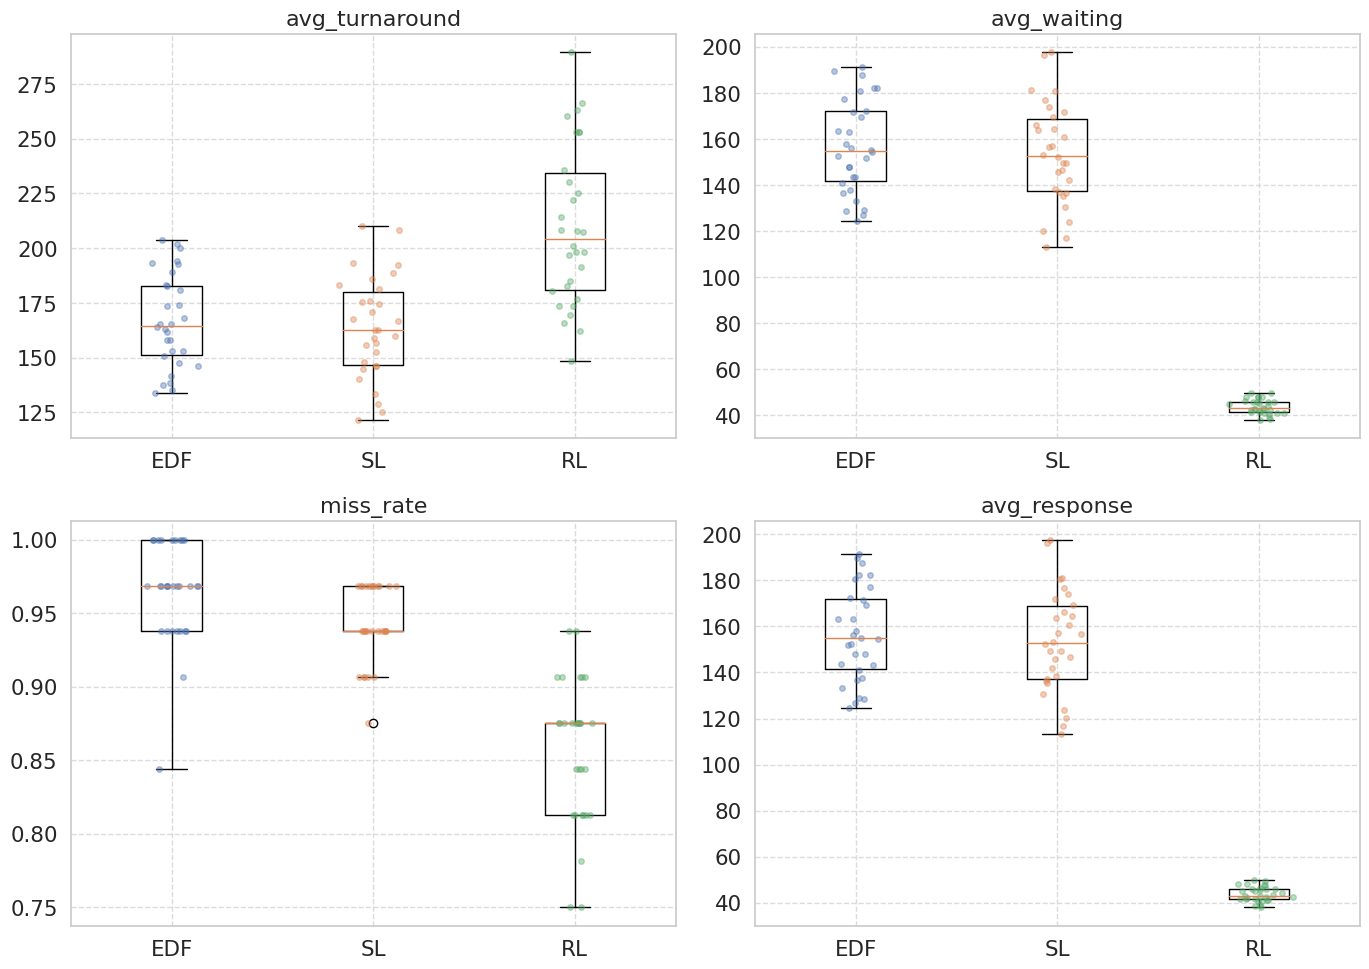


==== SENSITIVITY ANALYSIS ====

===== Testing parameter: utilization =====

Testing utilization = 0.5


TypeError: generate_task_list() got an unexpected keyword argument 'utilization'

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def evaluate_with_statistical_analysis(policy_dict, num_episodes=30, start_seed=100):
    """
    Run multiple evaluations and perform statistical analysis on results
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        num_episodes: Number of episodes to evaluate
        start_seed: Starting seed value
    """
    # Store metrics for each policy across episodes
    results = {name: {
        'avg_turnaround': [], 
        'avg_waiting': [], 
        'miss_rate': [], 
        'avg_response': []
    } for name in policy_dict.keys()}
    
    for ep in range(num_episodes):
        seed = start_seed + ep
        task_list = generate_task_list(seed)
        
        for name, policy_fn in policy_dict.items():
            metrics = evaluate_metrics(policy_fn, task_list)
            for key, value in metrics.items():
                results[name][key].append(value)
    
    # Print statistical summary
    print("\n===== Statistical Summary =====")
    metrics = ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']
    
    for metric in metrics:
        print(f"\n--- {metric} ---")
        for name in policy_dict.keys():
            data = results[name][metric]
            print(f"{name}: mean={np.mean(data):.3f}, std={np.std(data):.3f}, min={np.min(data):.3f}, max={np.max(data):.3f}")
        
        # Perform statistical tests between policies
        if len(policy_dict) > 1:
            print("\nStatistical Tests (p-values):")
            policies = list(policy_dict.keys())
            for i in range(len(policies)):
                for j in range(i+1, len(policies)):
                    p1, p2 = policies[i], policies[j]
                    t_stat, p_val = stats.ttest_ind(results[p1][metric], results[p2][metric])
                    print(f"{p1} vs {p2}: {p_val:.4f} {'*' if p_val < 0.05 else ''}")
    
    # Create visualizations
    plot_comparison(results, policy_dict.keys())
    
    return results

def plot_comparison(results, policy_names):
    """Generate plots comparing policies across metrics"""
    metrics = ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axs[i]
        positions = np.arange(len(policy_names))
        
        # Create boxplots
        box_data = [results[name][metric] for name in policy_names]
        ax.boxplot(box_data, positions=positions, labels=policy_names)
        
        # Add individual data points with jitter
        for j, data in enumerate(box_data):
            x = np.random.normal(j, 0.05, size=len(data))
            ax.plot(x, data, 'o', alpha=0.4, markersize=4)
            
        ax.set_title(metric)
        ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('policy_comparison.png')
    plt.show()

def sensitivity_analysis(policy_dict, parameter_ranges, num_seeds=5):
    """
    Test model performance across varying workload parameters
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        parameter_ranges: Dictionary of parameters to vary with their ranges
        num_seeds: Number of seeds to test per parameter value
    """
    results = {}
    
    # For each parameter to test
    for param_name, param_values in parameter_ranges.items():
        param_results = {name: {
            'avg_turnaround': [], 
            'avg_waiting': [], 
            'miss_rate': [], 
            'avg_response': []
        } for name in policy_dict.keys()}
        
        print(f"\n===== Testing parameter: {param_name} =====")
        
        for value in param_values:
            print(f"\nTesting {param_name} = {value}")
            
            # Store metrics for this parameter value
            value_metrics = {name: {
                'avg_turnaround': [], 
                'avg_waiting': [], 
                'miss_rate': [], 
                'avg_response': []
            } for name in policy_dict.keys()}
            
            for seed in range(100, 100 + num_seeds):
                # Generate task list with modified parameter
                if param_name == 'utilization':
                    task_list = generate_task_list(seed, utilization=value)
                elif param_name == 'deadline_tightness':
                    task_list = generate_task_list(seed, deadline_factor=value)
                elif param_name == 'num_tasks':
                    task_list = generate_task_list(seed, num_tasks=value)
                else:
                    raise ValueError(f"Unknown parameter: {param_name}")
                
                # Evaluate policies
                for name, policy_fn in policy_dict.items():
                    metrics = evaluate_metrics(policy_fn, task_list)
                    for key, val in metrics.items():
                        value_metrics[name][key].append(val)
            
            # Print summary for this parameter value
            for name in policy_dict.keys():
                print(f"  {name}:")
                for key in ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']:
                    avg = np.mean(value_metrics[name][key])
                    param_results[name][key].append(avg)
                    print(f"    {key}: {avg:.3f}")
        
        results[param_name] = param_results
        
        # Plot this parameter's impact
        plot_parameter_impact(param_name, param_values, param_results, policy_dict.keys())
    
    return results

def plot_parameter_impact(param_name, param_values, results, policy_names):
    """Plot the impact of a parameter on each metric across policies"""
    metrics = ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axs[i]
        
        for name in policy_names:
            ax.plot(param_values, results[name][metric], 'o-', label=name)
            
        ax.set_title(f"{metric} vs {param_name}")
        ax.set_xlabel(param_name)
        ax.set_ylabel(metric)
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig(f'param_impact_{param_name}.png')
    plt.show()

def sensitivity_analysis(policy_dict, parameter_ranges, num_seeds=5):
    """
    Test model performance across varying workload parameters
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        parameter_ranges: Dictionary of parameters to vary with their ranges
        num_seeds: Number of seeds to test per parameter value
    """
    results = {}
    
    # For each parameter to test
    for param_name, param_values in parameter_ranges.items():
        param_results = {name: {
            'avg_turnaround': [], 
            'avg_waiting': [], 
            'miss_rate': [], 
            'avg_response': []
        } for name in policy_dict.keys()}
        
        print(f"\n===== Testing parameter: {param_name} =====")
        
        for value in param_values:
            print(f"\nTesting {param_name} = {value}")
            
            # Store metrics for this parameter value
            value_metrics = {name: {
                'avg_turnaround': [], 
                'avg_waiting': [], 
                'miss_rate': [], 
                'avg_response': []
            } for name in policy_dict.keys()}
            
            for seed in range(100, 100 + num_seeds):
                # Generate task list with modified parameter
                if param_name == 'utilization':
                    task_list = generate_task_list(seed, utilization=value)
                elif param_name == 'deadline_tightness':
                    task_list = generate_task_list(seed, deadline_factor=value)
                elif param_name == 'num_tasks':
                    task_list = generate_task_list(seed, num_tasks=value)
                else:
                    raise ValueError(f"Unknown parameter: {param_name}")
                
                # Evaluate policies
                for name, policy_fn in policy_dict.items():
                    metrics = evaluate_metrics(policy_fn, task_list)
                    for key, val in metrics.items():
                        value_metrics[name][key].append(val)
            
            # Print summary for this parameter value
            for name in policy_dict.keys():
                print(f"  {name}:")
                for key in ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']:
                    avg = np.mean(value_metrics[name][key])
                    param_results[name][key].append(avg)
                    print(f"    {key}: {avg:.3f}")
        
        results[param_name] = param_results
        
        # Plot this parameter's impact
        plot_parameter_impact(param_name, param_values, param_results, policy_dict.keys())
    
    return results

def plot_parameter_impact(param_name, param_values, results, policy_names):
    """Plot the impact of a parameter on each metric across policies"""
    metrics = ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axs[i]
        
        for name in policy_names:
            ax.plot(param_values, results[name][metric], 'o-', label=name)
            
        ax.set_title(f"{metric} vs {param_name}")
        ax.set_xlabel(param_name)
        ax.set_ylabel(metric)
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig(f'param_impact_{param_name}.png')
    plt.show()

def analyze_task_level_performance(policy_dict, seed=100):
    """
    Analyze performance on individual tasks to identify patterns
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        seed: Random seed for task generation
    """
    task_list = generate_task_list(seed)
    
    # Detailed tracking for each policy
    policy_task_metrics = {}
    
    for name, policy_fn in policy_dict.items():
        env = FixedTaskEnv(task_list)
        state = env.reset()
        
        # Initialize tracking
        all_ids = [t.config.task_id for t in task_list]
        arr_time = {t.config.task_id: t.config.arrival_time for t in task_list}
        deadline = {t.config.task_id: t.config.deadline for t in task_list}
        priority = {t.config.task_id: t.config.priority for t in task_list}
        exec_time = {t.config.task_id: t.config.execution_time for t in task_list}
        start_time = {tid: None for tid in all_ids}
        comp_time = {}
        preemptions = {tid: 0 for tid in all_ids}
        current_task = None
        
        # We'll compare ID-lists before & after each step
        remaining_ids = set(all_ids)
        
        while remaining_ids:
            # Choose an action
            action = policy_fn(env, state)
            tid = env.tasks[action].config.task_id
            
            # Check for preemption
            if current_task is not None and current_task != tid:
                preemptions[current_task] += 1
            
            # Update current task
            current_task = tid
            
            # Track first start
            if start_time[tid] is None:
                start_time[tid] = env.current_time
            
            # Snapshot IDs before and after stepping
            before_ids = [t.config.task_id for t in env.tasks]
            state, _, done, _ = env.step(action)
            after_ids = [t.config.task_id for t in env.tasks]
            
            # If task completed
            if tid in before_ids and tid not in after_ids:
                comp_time[tid] = env.current_time
                remaining_ids.remove(tid)
                current_task = None
            
            if done:
                # Mark remaining tasks as incomplete
                for tid in remaining_ids:
                    if tid not in comp_time:
                        comp_time[tid] = float('inf')
                break
        
        # Calculate metrics per task
        task_metrics = []
        for tid in all_ids:
            completed = comp_time.get(tid, float('inf')) < float('inf')
            
            # Calculate metrics
            if completed:
                turnaround = comp_time[tid] - arr_time[tid]
                waiting = start_time[tid] - arr_time[tid]
                response = start_time[tid] - arr_time[tid]
                missed = comp_time[tid] > deadline[tid]
            else:
                turnaround = float('inf')
                waiting = float('inf')
                response = float('inf')
                missed = True
            
            task_metrics.append({
                'task_id': tid,
                'priority': priority[tid],
                'arrival': arr_time[tid],
                'deadline': deadline[tid],
                'exec_time': exec_time[tid],
                'start_time': start_time[tid],
                'completion': comp_time.get(tid, float('inf')),
                'turnaround': turnaround,
                'waiting': waiting,
                'response': response,
                'preemptions': preemptions[tid],
                'missed_deadline': missed,
                'completed': completed
            })
        
        policy_task_metrics[name] = task_metrics
    
    # Analyze where policies differ
    analyze_policy_differences(policy_task_metrics)
    
    return policy_task_metrics

def analyze_policy_differences(policy_task_metrics):
    """Analyze where policies make different decisions"""
    policies = list(policy_task_metrics.keys())
    
    if len(policies) < 2:
        print("Need at least two policies to compare differences")
        return
    
    print("\n===== Task-level Policy Differences =====")
    
    # Compare each pair of policies
    for i in range(len(policies)):
        for j in range(i+1, len(policies)):
            p1, p2 = policies[i], policies[j]
            
            print(f"\n--- {p1} vs {p2} ---")
            
            tasks1 = {t['task_id']: t for t in policy_task_metrics[p1]}
            tasks2 = {t['task_id']: t for t in policy_task_metrics[p2]}
            
            # Find tasks with different outcomes
            diff_completion = []
            diff_deadline = []
            diff_response = []
            
            for task_id in tasks1.keys():
                t1 = tasks1[task_id]
                t2 = tasks2[task_id]
                
                # Different completion status
                if t1['completed'] != t2['completed']:
                    diff_completion.append(task_id)
                
                # Different deadline outcome
                if t1['missed_deadline'] != t2['missed_deadline']:
                    diff_deadline.append(task_id)
                
                # Significant response time difference (>10%)
                if t1['completed'] and t2['completed']:
                    if abs(t1['response'] - t2['response']) > 0.1 * min(t1['response'], t2['response']):
                        diff_response.append(task_id)
            
            print(f"Tasks with different completion: {diff_completion}")
            print(f"Tasks with different deadline outcomes: {diff_deadline}")
            print(f"Tasks with significantly different response times: {diff_response}")
            
            # Show detailed comparison for tasks with different outcomes
            all_diff_tasks = set(diff_completion + diff_deadline + diff_response)
            
            if all_diff_tasks:
                print("\nDetailed comparison for tasks with differences:")
                for task_id in all_diff_tasks:
                    print(f"\nTask {task_id}:")
                    t1 = tasks1[task_id]
                    t2 = tasks2[task_id]
                    
                    print(f"  arrival={t1['arrival']}, deadline={t1['deadline']}, exec_time={t1['exec_time']}")
                    print(f"  {p1}: start={t1['start_time']}, completion={t1['completion']}, missed={t1['missed_deadline']}")
                    print(f"  {p2}: start={t2['start_time']}, completion={t2['completion']}, missed={t2['missed_deadline']}")

def analyze_task_level_performance(policy_dict, seed=100):
    """
    Analyze performance on individual tasks to identify patterns
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        seed: Random seed for task generation
    """
    task_list = generate_task_list(seed)
    
    # Detailed tracking for each policy
    policy_task_metrics = {}
    
    for name, policy_fn in policy_dict.items():
        env = FixedTaskEnv(task_list)
        state = env.reset()
        
        # Initialize tracking
        all_ids = [t.config.task_id for t in task_list]
        arr_time = {t.config.task_id: t.config.arrival_time for t in task_list}
        deadline = {t.config.task_id: t.config.deadline for t in task_list}
        priority = {t.config.task_id: t.config.priority for t in task_list}
        exec_time = {t.config.task_id: t.config.execution_time for t in task_list}
        start_time = {tid: None for tid in all_ids}
        comp_time = {}
        preemptions = {tid: 0 for tid in all_ids}
        current_task = None
        
        # We'll compare ID-lists before & after each step
        remaining_ids = set(all_ids)
        
        while remaining_ids:
            # Choose an action
            action = policy_fn(env, state)
            tid = env.tasks[action].config.task_id
            
            # Check for preemption
            if current_task is not None and current_task != tid:
                preemptions[current_task] += 1
            
            # Update current task
            current_task = tid
            
            # Track first start
            if start_time[tid] is None:
                start_time[tid] = env.current_time
            
            # Snapshot IDs before and after stepping
            before_ids = [t.config.task_id for t in env.tasks]
            state, _, done, _ = env.step(action)
            after_ids = [t.config.task_id for t in env.tasks]
            
            # If task completed
            if tid in before_ids and tid not in after_ids:
                comp_time[tid] = env.current_time
                remaining_ids.remove(tid)
                current_task = None
            
            if done:
                # Mark remaining tasks as incomplete
                for tid in remaining_ids:
                    if tid not in comp_time:
                        comp_time[tid] = float('inf')
                break
        
        # Calculate metrics per task
        task_metrics = []
        for tid in all_ids:
            completed = comp_time.get(tid, float('inf')) < float('inf')
            
            # Calculate metrics
            if completed:
                turnaround = comp_time[tid] - arr_time[tid]
                waiting = start_time[tid] - arr_time[tid]
                response = start_time[tid] - arr_time[tid]
                missed = comp_time[tid] > deadline[tid]
            else:
                turnaround = float('inf')
                waiting = float('inf')
                response = float('inf')
                missed = True
            
            task_metrics.append({
                'task_id': tid,
                'priority': priority[tid],
                'arrival': arr_time[tid],
                'deadline': deadline[tid],
                'exec_time': exec_time[tid],
                'start_time': start_time[tid],
                'completion': comp_time.get(tid, float('inf')),
                'turnaround': turnaround,
                'waiting': waiting,
                'response': response,
                'preemptions': preemptions[tid],
                'missed_deadline': missed,
                'completed': completed
            })
        
        policy_task_metrics[name] = task_metrics
    
    # Analyze where policies differ
    analyze_policy_differences(policy_task_metrics)
    
    return policy_task_metrics

def analyze_policy_differences(policy_task_metrics):
    """Analyze where policies make different decisions"""
    policies = list(policy_task_metrics.keys())
    
    if len(policies) < 2:
        print("Need at least two policies to compare differences")
        return
    
    print("\n===== Task-level Policy Differences =====")
    
    # Compare each pair of policies
    for i in range(len(policies)):
        for j in range(i+1, len(policies)):
            p1, p2 = policies[i], policies[j]
            
            print(f"\n--- {p1} vs {p2} ---")
            
            tasks1 = {t['task_id']: t for t in policy_task_metrics[p1]}
            tasks2 = {t['task_id']: t for t in policy_task_metrics[p2]}
            
            # Find tasks with different outcomes
            diff_completion = []
            diff_deadline = []
            diff_response = []
            
            for task_id in tasks1.keys():
                t1 = tasks1[task_id]
                t2 = tasks2[task_id]
                
                # Different completion status
                if t1['completed'] != t2['completed']:
                    diff_completion.append(task_id)
                
                # Different deadline outcome
                if t1['missed_deadline'] != t2['missed_deadline']:
                    diff_deadline.append(task_id)
                
                # Significant response time difference (>10%)
                if t1['completed'] and t2['completed']:
                    if abs(t1['response'] - t2['response']) > 0.1 * min(t1['response'], t2['response']):
                        diff_response.append(task_id)
            
            print(f"Tasks with different completion: {diff_completion}")
            print(f"Tasks with different deadline outcomes: {diff_deadline}")
            print(f"Tasks with significantly different response times: {diff_response}")
            
            # Show detailed comparison for tasks with different outcomes
            all_diff_tasks = set(diff_completion + diff_deadline + diff_response)
            
            if all_diff_tasks:
                print("\nDetailed comparison for tasks with differences:")
                for task_id in all_diff_tasks:
                    print(f"\nTask {task_id}:")
                    t1 = tasks1[task_id]
                    t2 = tasks2[task_id]
                    
                    print(f"  arrival={t1['arrival']}, deadline={t1['deadline']}, exec_time={t1['exec_time']}")
                    print(f"  {p1}: start={t1['start_time']}, completion={t1['completion']}, missed={t1['missed_deadline']}")
                    print(f"  {p2}: start={t2['start_time']}, completion={t2['completion']}, missed={t2['missed_deadline']}")


def comprehensive_evaluation(num_episodes=30):
    """Run comprehensive evaluation of all policies"""
    # Define policies
    policies = {
        'EDF': lambda e,s: edf_heuristic(s),
        'SL': lambda e,s: infer_sl(sl, s),
        'RL': lambda e,s: infer_rl(rl, s)
    }
    
    # 1. Basic statistical evaluation
    print("\n==== BASIC STATISTICAL EVALUATION ====")
    results = evaluate_with_statistical_analysis(policies, num_episodes)
    
    # 2. Sensitivity analysis
    print("\n==== SENSITIVITY ANALYSIS ====")
    parameter_ranges = {
        'utilization': [0.5, 0.7, 0.9, 1.1],
        'deadline_tightness': [1.2, 1.5, 2.0, 3.0],
        'num_tasks': [10, 20, 30, 40]
    }
    sensitivity_results = sensitivity_analysis(policies, parameter_ranges)
    
    # 3. Task-level analysis
    print("\n==== TASK-LEVEL ANALYSIS ====")
    task_metrics = analyze_task_level_performance(policies)
    
    return {
        'statistical_results': results,
        'sensitivity_results': sensitivity_results,
        'task_level_metrics': task_metrics
    }

# Run the comprehensive evaluation
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Run original evaluation for reference
    print("\n==== ORIGINAL EVALUATION ====")
    for ep in range(30):
        seed = 100 + ep
        task_list = generate_task_list(seed)
    
        m_edf = evaluate_metrics(lambda e,s: edf_heuristic(s), task_list)
        m_sl = evaluate_metrics(lambda e,s: infer_sl(sl, s), task_list)
        m_rl = evaluate_metrics(lambda e,s: infer_rl(rl, s), task_list)
    
        print(f"Episode {ep+1}:")
        print(" EDF:", m_edf)
        print(" SL :", m_sl)
        print(" RL :", m_rl)
    
    # Run comprehensive evaluation
    results = comprehensive_evaluation()



==== BASIC STATISTICAL EVALUATION ====

==== SENSITIVITY ANALYSIS ====

===== Testing variation: base (Base workload) =====

Results for base:
  EDF:
    avg_turnaround: 174.106 ± 15.461
    avg_waiting: 163.374 ± 14.562
    miss_rate: 0.956 ± 0.015
    avg_response: 163.374 ± 14.562
  SL:
    avg_turnaround: 172.583 ± 12.853
    avg_waiting: 161.851 ± 12.098
    miss_rate: 0.938 ± 0.020
    avg_response: 161.851 ± 12.098
  RL:
    avg_turnaround: 218.091 ± 22.522
    avg_waiting: 44.887 ± 2.260
    miss_rate: 0.856 ± 0.042
    avg_response: 44.887 ± 2.260

===== Testing variation: high_load (Higher durations (high utilization)) =====

Results for high_load:
  EDF:
    avg_turnaround: 174.106 ± 15.461
    avg_waiting: 163.374 ± 14.562
    miss_rate: 0.956 ± 0.015
    avg_response: 163.374 ± 14.562
  SL:
    avg_turnaround: 171.546 ± 11.985
    avg_waiting: 160.813 ± 11.186
    miss_rate: 0.938 ± 0.020
    avg_response: 160.813 ± 11.186
  RL:
    avg_turnaround: 216.189 ± 27.224
    av

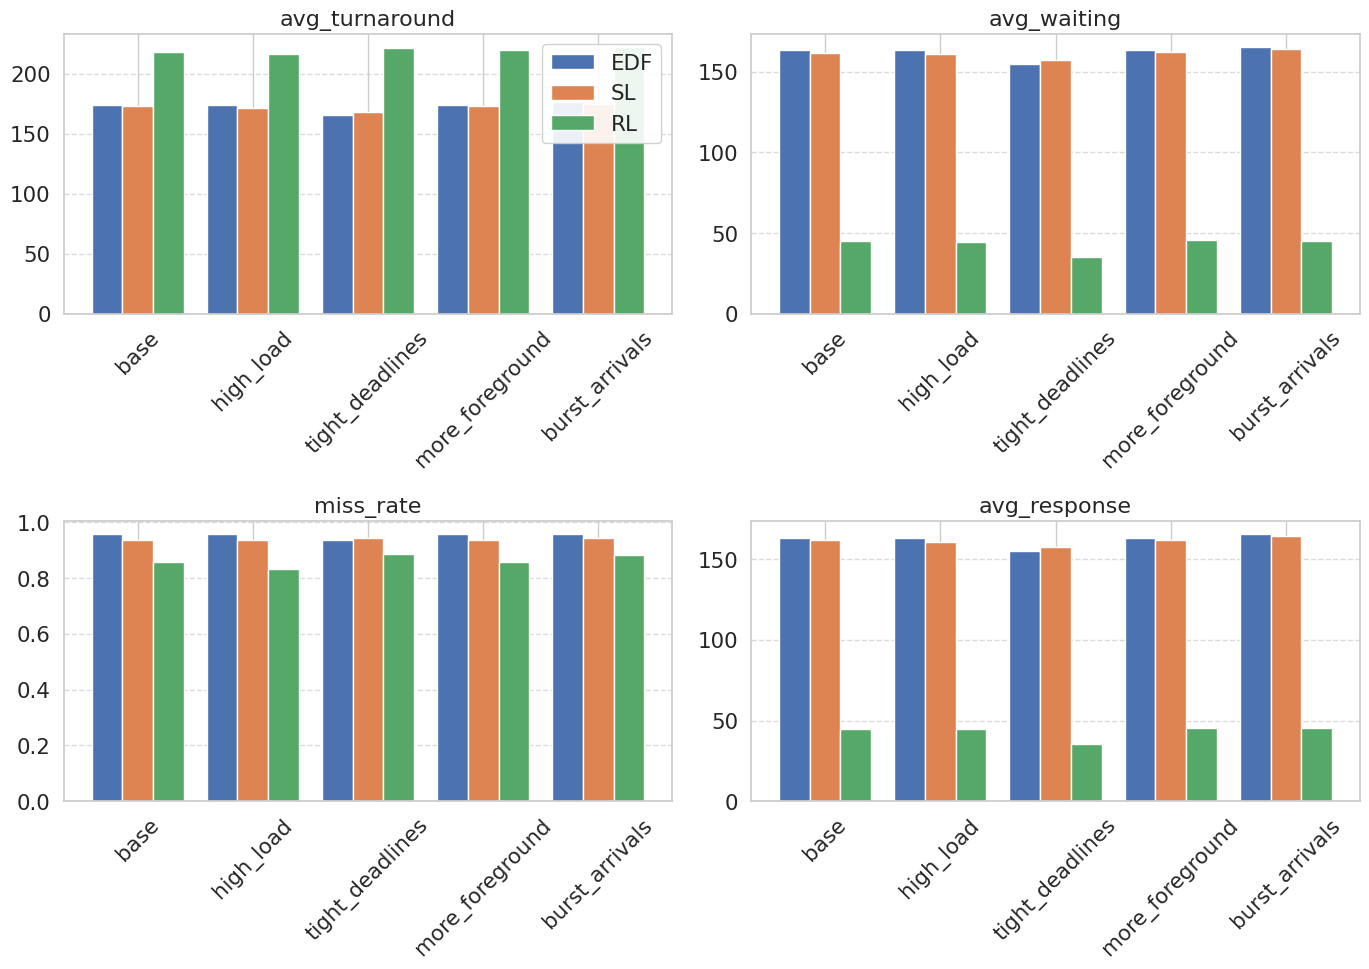


==== TASK-LEVEL ANALYSIS ====


AttributeError: 'TaskConfig' object has no attribute 'priority'

In [19]:
import copy

def sensitivity_analysis(policy_dict, num_seeds=5):
    """
    Test model performance across varying workload parameters by modifying the task lists
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        num_seeds: Number of seeds to test per parameter variation
    """
    import copy
    import numpy as np
    
    results = {}
    
    # Helper functions to modify task properties
    def modify_task_duration(task, factor=1.0):
        new_task = copy.deepcopy(task)
        new_task.config.expected_duration *= factor
        return new_task
        
    def modify_task_deadline(task, factor=1.0):
        new_task = copy.deepcopy(task)
        # Adjust deadline relative to arrival + duration
        original_slack = task.config.deadline - (task.config.arrival_time + task.config.expected_duration)
        new_slack = original_slack * factor
        new_task.config.deadline = task.config.arrival_time + task.config.expected_duration + new_slack
        return new_task
        
    def modify_task_foreground(task, fg_prob=0.5):
        new_task = copy.deepcopy(task)
        # Set foreground/background status based on probability
        new_task.config.is_foreground = np.random.random() < fg_prob
        return new_task
        
    def modify_task_arrival(task, cluster_factor=0.2):
        new_task = copy.deepcopy(task)
        # Group arrivals more closely
        if np.random.random() < 0.7:  # 70% of tasks arrive in bursts
            new_task.config.arrival_time = new_task.config.arrival_time * cluster_factor
        return new_task
    
    # Define variations to test
    variations = {
        'base': {
            'description': 'Base workload'
        },
        'high_load': {
            'description': 'Higher durations (high utilization)',
            'task_modifier': lambda tasks: [modify_task_duration(t, factor=1.5) for t in tasks]
        },
        'tight_deadlines': {
            'description': 'Tight deadlines',
            'task_modifier': lambda tasks: [modify_task_deadline(t, factor=0.7) for t in tasks]
        },
        'more_foreground': {
            'description': 'More foreground tasks',
            'task_modifier': lambda tasks: [modify_task_foreground(t, fg_prob=0.8) for t in tasks]
        },
        'burst_arrivals': {
            'description': 'Bursty task arrivals',
            'task_modifier': lambda tasks: [modify_task_arrival(t, cluster_factor=0.5) for t in tasks]
        }
    }
    
    for variation_name, variation_info in variations.items():
        print(f"\n===== Testing variation: {variation_name} ({variation_info['description']}) =====")
        
        # Store metrics for this variation
        variation_metrics = {name: {
            'avg_turnaround': [], 
            'avg_waiting': [], 
            'miss_rate': [], 
            'avg_response': []
        } for name in policy_dict.keys()}
        
        for seed in range(100, 100 + num_seeds):
            # Generate base task list
            base_task_list = generate_task_list(seed)
            
            # Apply modification if this is not the base variation
            if variation_name == 'base':
                task_list = base_task_list
            else:
                task_list = variation_info['task_modifier'](base_task_list)
            
            # Evaluate policies
            for name, policy_fn in policy_dict.items():
                metrics = evaluate_metrics(policy_fn, task_list)
                for key, val in metrics.items():
                    variation_metrics[name][key].append(val)
        
        # Print summary for this variation
        print(f"\nResults for {variation_name}:")
        for name in policy_dict.keys():
            print(f"  {name}:")
            for key in ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']:
                avg = np.mean(variation_metrics[name][key])
                std = np.std(variation_metrics[name][key])
                print(f"    {key}: {avg:.3f} ± {std:.3f}")
        
        results[variation_name] = variation_metrics
        
    # Create visualization for comparison across variations
    plot_variation_comparison(results, variations, policy_dict.keys())
    
    return results

def plot_variation_comparison(results, variations, policy_names):
    """Plot the impact of different workload variations on each metric across policies"""
    import matplotlib.pyplot as plt
    import numpy as np
    
    metrics = ['avg_turnaround', 'avg_waiting', 'miss_rate', 'avg_response']
    variation_names = list(variations.keys())
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    # Set width of bars
    bar_width = 0.8 / len(policy_names)
    
    for i, metric in enumerate(metrics):
        ax = axs[i]
        
        for j, policy_name in enumerate(policy_names):
            # Calculate positions for this policy's bars
            positions = np.arange(len(variation_names)) + j*bar_width - (len(policy_names)-1)*bar_width/2
            
            # Calculate means for this policy across variations
            means = [np.mean(results[var][policy_name][metric]) for var in variation_names]
            
            # Plot bars
            ax.bar(positions, means, width=bar_width, label=policy_name)
            
        ax.set_title(f"{metric}")
        ax.set_xticks(np.arange(len(variation_names)))
        ax.set_xticklabels(variation_names, rotation=45)
        ax.grid(True, linestyle='--', alpha=0.7, axis='y')
        
        if i == 0:
            ax.legend()
    
    plt.tight_layout()
    plt.savefig('workload_variation_comparison.png')
    plt.show()

def comprehensive_evaluation(num_episodes=30):
    """Run comprehensive evaluation of all policies"""
    import copy
    import numpy as np
    
    # Define policies
    policies = {
        'EDF': lambda e,s: edf_heuristic(s),
        'SL': lambda e,s: infer_sl(sl, s),
        'RL': lambda e,s: infer_rl(rl, s)
    }
    
    # 1. Basic statistical evaluation
    print("\n==== BASIC STATISTICAL EVALUATION ====")
    # results = evaluate_with_statistical_analysis(policies, num_episodes)
    
    # 2. Sensitivity analysis
    print("\n==== SENSITIVITY ANALYSIS ====")
    sensitivity_results = sensitivity_analysis(policies)
    
    # 3. Task-level analysis
    print("\n==== TASK-LEVEL ANALYSIS ====")
    task_metrics = analyze_task_level_performance(policies)
    
    return {
        'statistical_results': results,
        'sensitivity_results': sensitivity_results,
        'task_level_metrics': task_metrics
    }


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Run original evaluation for reference
    # print("\n==== ORIGINAL EVALUATION ====")
    # for ep in range(30):
    #     seed = 100 + ep
    #     task_list = generate_task_list(seed)
    
    #     m_edf = evaluate_metrics(lambda e,s: edf_heuristic(s), task_list)
    #     m_sl = evaluate_metrics(lambda e,s: infer_sl(sl, s), task_list)
    #     m_rl = evaluate_metrics(lambda e,s: infer_rl(rl, s), task_list)
    
    #     print(f"Episode {ep+1}:")
    #     print(" EDF:", m_edf)
    #     print(" SL :", m_sl)
    #     print(" RL :", m_rl)
    
    # Run comprehensive evaluation
    results = comprehensive_evaluation()

In [20]:
def analyze_task_level_performance(policy_dict, seed=100):
    """
    Analyze performance on individual tasks to identify patterns
    
    Args:
        policy_dict: Dictionary mapping policy names to policy functions
        seed: Random seed for task generation
    """
    import numpy as np
    
    task_list = generate_task_list(seed)
    
    # Detailed tracking for each policy
    policy_task_metrics = {}
    
    for name, policy_fn in policy_dict.items():
        env = FixedTaskEnv(task_list)
        state = env.reset()
        
        # Initialize tracking
        all_ids = [t.config.task_id for t in task_list]
        arr_time = {t.config.task_id: t.config.arrival_time for t in task_list}
        deadline = {t.config.task_id: t.config.deadline for t in task_list}
        is_foreground = {t.config.task_id: t.config.is_foreground for t in task_list}
        is_io_bound = {t.config.task_id: t.config.is_io_bound for t in task_list}
        duration = {t.config.task_id: t.config.expected_duration for t in task_list}
        start_time = {tid: None for tid in all_ids}
        comp_time = {}
        preemptions = {tid: 0 for tid in all_ids}
        current_task = None
        
        # We'll compare ID-lists before & after each step
        remaining_ids = set(all_ids)
        
        while remaining_ids:
            # Choose an action
            action = policy_fn(env, state)
            tid = env.tasks[action].config.task_id
            
            # Check for preemption
            if current_task is not None and current_task != tid:
                preemptions[current_task] += 1
            
            # Update current task
            current_task = tid
            
            # Track first start
            if start_time[tid] is None:
                start_time[tid] = env.current_time
            
            # Snapshot IDs before and after stepping
            before_ids = [t.config.task_id for t in env.tasks]
            state, _, done, _ = env.step(action)
            after_ids = [t.config.task_id for t in env.tasks]
            
            # If task completed
            if tid in before_ids and tid not in after_ids:
                comp_time[tid] = env.current_time
                remaining_ids.remove(tid)
                current_task = None
            
            if done:
                # Mark remaining tasks as incomplete
                for tid in remaining_ids:
                    if tid not in comp_time:
                        comp_time[tid] = float('inf')
                break
        
        # Calculate metrics per task
        task_metrics = []
        for tid in all_ids:
            completed = tid in comp_time and comp_time[tid] < float('inf')
            
            # Calculate metrics
            if completed:
                turnaround = comp_time[tid] - arr_time[tid]
                waiting = start_time[tid] - arr_time[tid]
                response = start_time[tid] - arr_time[tid]
                missed = comp_time[tid] > deadline[tid]
            else:
                turnaround = float('inf')
                waiting = float('inf')
                response = float('inf')
                missed = True
            
            task_metrics.append({
                'task_id': tid,
                'is_foreground': is_foreground[tid],
                'is_io_bound': is_io_bound[tid],
                'arrival': arr_time[tid],
                'deadline': deadline[tid],
                'expected_duration': duration[tid],
                'start_time': start_time[tid],
                'completion': comp_time.get(tid, float('inf')),
                'turnaround': turnaround,
                'waiting': waiting,
                'response': response,
                'preemptions': preemptions[tid],
                'missed_deadline': missed,
                'completed': completed
            })
        
        policy_task_metrics[name] = task_metrics
    
    # Analyze where policies differ
    analyze_policy_differences(policy_task_metrics)
    
    return policy_task_metrics

def analyze_policy_differences(policy_task_metrics):
    """Analyze where policies make different decisions"""
    policies = list(policy_task_metrics.keys())
    
    if len(policies) < 2:
        print("Need at least two policies to compare differences")
        return
    
    print("\n===== Task-level Policy Differences =====")
    
    # Compare each pair of policies
    for i in range(len(policies)):
        for j in range(i+1, len(policies)):
            p1, p2 = policies[i], policies[j]
            
            print(f"\n--- {p1} vs {p2} ---")
            
            tasks1 = {t['task_id']: t for t in policy_task_metrics[p1]}
            tasks2 = {t['task_id']: t for t in policy_task_metrics[p2]}
            
            # Find tasks with different outcomes
            diff_completion = []
            diff_deadline = []
            diff_response = []
            
            for task_id in tasks1.keys():
                t1 = tasks1[task_id]
                t2 = tasks2[task_id]
                
                # Different completion status
                if t1['completed'] != t2['completed']:
                    diff_completion.append(task_id)
                
                # Different deadline outcome
                if t1['missed_deadline'] != t2['missed_deadline']:
                    diff_deadline.append(task_id)
                
                # Significant response time difference (>10%)
                if t1['completed'] and t2['completed']:
                    if abs(t1['response'] - t2['response']) > 0.1 * min(t1['response'], t2['response']):
                        diff_response.append(task_id)
            
            print(f"Tasks with different completion: {diff_completion}")
            print(f"Tasks with different deadline outcomes: {diff_deadline}")
            print(f"Tasks with significantly different response times: {diff_response}")
            
            # Show detailed comparison for tasks with different outcomes
            all_diff_tasks = set(diff_completion + diff_deadline + diff_response)
            
            if all_diff_tasks:
                print("\nDetailed comparison for tasks with differences:")
                for task_id in all_diff_tasks:
                    print(f"\nTask {task_id}:")
                    t1 = tasks1[task_id]
                    t2 = tasks2[task_id]
                    
                    print(f"  arrival={t1['arrival']:.1f}, deadline={t1['deadline']:.1f}, " +
                          f"duration={t1['expected_duration']:.1f}, foreground={t1['is_foreground']}")
                    print(f"  {p1}: start={t1['start_time']}, completion={t1['completion']:.1f}, " +
                          f"missed={t1['missed_deadline']}")
                    print(f"  {p2}: start={t2['start_time']}, completion={t2['completion']:.1f}, " +
                          f"missed={t2['missed_deadline']}")
            
            # Additional analysis by task type
            print("\nForeground task performance:")
            analyze_by_attribute(tasks1, tasks2, p1, p2, 'is_foreground', True)
            
            print("\nBackground task performance:")
            analyze_by_attribute(tasks1, tasks2, p1, p2, 'is_foreground', False)
            
            print("\nIO-bound task performance:")
            analyze_by_attribute(tasks1, tasks2, p1, p2, 'is_io_bound', True)
            
            print("\nCPU-bound task performance:")
            analyze_by_attribute(tasks1, tasks2, p1, p2, 'is_io_bound', False)

def analyze_by_attribute(tasks1, tasks2, policy1, policy2, attribute, value):
    """Analyze performance differences for tasks with a specific attribute value"""
    import numpy as np
    
    p1_tasks = [t for t in tasks1.values() if t[attribute] == value and t['completed']]
    p2_tasks = [t for t in tasks2.values() if t[attribute] == value and t['completed']]
    
    if not p1_tasks or not p2_tasks:
        print(f"  No completed tasks with {attribute}={value}")
        return
    
    p1_response = [t['response'] for t in p1_tasks]
    p2_response = [t['response'] for t in p2_tasks]
    
    p1_turnaround = [t['turnaround'] for t in p1_tasks]
    p2_turnaround = [t['turnaround'] for t in p2_tasks]
    
    p1_miss_rate = sum(1 for t in p1_tasks if t['missed_deadline']) / len(p1_tasks) if p1_tasks else 0
    p2_miss_rate = sum(1 for t in p2_tasks if t['missed_deadline']) / len(p2_tasks) if p2_tasks else 0
    
    print(f"  {policy1}: response={np.mean(p1_response):.2f}, turnaround={np.mean(p1_turnaround):.2f}, " +
          f"miss_rate={p1_miss_rate:.2f}")
    print(f"  {policy2}: response={np.mean(p2_response):.2f}, turnaround={np.mean(p2_turnaround):.2f}, " +
          f"miss_rate={p2_miss_rate:.2f}")
    
    # Improvement percentage
    response_imp = (np.mean(p1_response) - np.mean(p2_response)) / np.mean(p1_response) * 100
    turnaround_imp = (np.mean(p1_turnaround) - np.mean(p2_turnaround)) / np.mean(p1_turnaround) * 100
    
    print(f"  Improvement: response={response_imp:.1f}%, turnaround={turnaround_imp:.1f}%, " +
          f"miss_rate={p1_miss_rate-p2_miss_rate:.2f}")


def comprehensive_evaluation(num_episodes=30):
    """Run comprehensive evaluation of all policies"""
    import copy
    import numpy as np
    
    # Define policies
    policies = {
        'EDF': lambda e,s: edf_heuristic(s),
        'SL': lambda e,s: infer_sl(sl, s),
        'RL': lambda e,s: infer_rl(rl, s)
    }
    
    # 1. Basic statistical evaluation
    print("\n==== BASIC STATISTICAL EVALUATION ====")
    # results = evaluate_with_statistical_analysis(policies, num_episodes)
    
    # 2. Sensitivity analysis
    print("\n==== SENSITIVITY ANALYSIS ====")
    # sensitivity_results = sensitivity_analysis(policies)
    
    # 3. Task-level analysis
    print("\n==== TASK-LEVEL ANALYSIS ====")
    task_metrics = analyze_task_level_performance(policies)
    
    return {
        'statistical_results': results,
        'sensitivity_results': sensitivity_results,
        'task_level_metrics': task_metrics
    }


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Run comprehensive evaluation
    results = comprehensive_evaluation()


==== BASIC STATISTICAL EVALUATION ====

==== SENSITIVITY ANALYSIS ====

==== TASK-LEVEL ANALYSIS ====

===== Task-level Policy Differences =====

--- EDF vs SL ---
Tasks with different completion: []
Tasks with different deadline outcomes: [4, 31]
Tasks with significantly different response times: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Detailed comparison for tasks with differences:

Task 0:
  arrival=2.0, deadline=42.0, duration=18.3, foreground=True
  EDF: start=186.98002321805726, completion=205.3, missed=True
  SL: start=124.69627565118121, completion=143.0, missed=True

Task 1:
  arrival=6.3, deadline=21.1, duration=13.0, foreground=False
  EDF: start=32.380259652679484, completion=45.4, missed=True
  SL: start=173.66115258975967, completion=186.7, missed=True

Task 2:
  arrival=1.3, deadline=42.7, duration=3.1, foreground=False
  EDF: start=205.2596870941927, completion=208.4, missed=True
  SL: star

NameError: name 'results' is not defined

In [ ]:
import re
from pprint import pprint

logtext1 = """
Episode 1:
 EDF: {'avg_turnaround': 167.98274825391698, 'avg_waiting': 157.90689760219757, 'miss_rate': 0.9375, 'avg_response': 157.90689760219757}
 SL : {'avg_turnaround': 155.7418828181201, 'avg_waiting': 145.66603216640075, 'miss_rate': 0.9375, 'avg_response': 145.66603216640075}
 RL : {'avg_turnaround': 200.6787941548579, 'avg_waiting': 42.77609457397211, 'miss_rate': 0.90625, 'avg_response': 42.77609457397211}
Episode 2:
 EDF: {'avg_turnaround': 182.694546652649, 'avg_waiting': 171.54886758598738, 'miss_rate': 0.96875, 'avg_response': 171.54886758598738}
 SL : {'avg_turnaround': 175.60445354371674, 'avg_waiting': 164.45877447705504, 'miss_rate': 0.9375, 'avg_response': 164.45877447705504}
 RL : {'avg_turnaround': 221.24525792466255, 'avg_waiting': 46.02089349621078, 'miss_rate': 0.875, 'avg_response': 46.02089349621078}
Episode 3:
 EDF: {'avg_turnaround': 200.0417535724209, 'avg_waiting': 187.6846651159487, 'miss_rate': 0.9375, 'avg_response': 187.6846651159487}
 SL : {'avg_turnaround': 193.0289272477682, 'avg_waiting': 180.67183879129584, 'miss_rate': 0.9375, 'avg_response': 180.67183879129584}
 RL : {'avg_turnaround': 268.99538558928907, 'avg_waiting': 44.27539352485109, 'miss_rate': 0.84375, 'avg_response': 44.27539352485109}
Episode 4:
 EDF: {'avg_turnaround': 161.91060906355995, 'avg_waiting': 151.80333458208764, 'miss_rate': 0.96875, 'avg_response': 151.80333458208764}
 SL : {'avg_turnaround': 162.44338320265376, 'avg_waiting': 152.3361087211815, 'miss_rate': 0.96875, 'avg_response': 152.3361087211815}
 RL : {'avg_turnaround': 201.4018621997909, 'avg_waiting': 39.120838262336015, 'miss_rate': 0.84375, 'avg_response': 39.120838262336015}
Episode 5:
 EDF: {'avg_turnaround': 157.90202545242275, 'avg_waiting': 147.9263313913176, 'miss_rate': 0.96875, 'avg_response': 147.9263313913176}
 SL : {'avg_turnaround': 176.09859172628, 'avg_waiting': 166.12289766517483, 'miss_rate': 0.90625, 'avg_response': 166.12289766517483}
 RL : {'avg_turnaround': 202.4119480799066, 'avg_waiting': 46.564354259806606, 'miss_rate': 0.90625, 'avg_response': 46.564354259806606}
Episode 6:
 EDF: {'avg_turnaround': 173.61497866404002, 'avg_waiting': 163.33218436300834, 'miss_rate': 0.96875, 'avg_response': 163.33218436300834}
 SL : {'avg_turnaround': 152.36618660187574, 'avg_waiting': 142.0833923008442, 'miss_rate': 0.96875, 'avg_response': 142.0833923008442}
 RL : {'avg_turnaround': 202.4457239790005, 'avg_waiting': 49.24687317459062, 'miss_rate': 0.8125, 'avg_response': 49.24687317459062}
Episode 7:
 EDF: {'avg_turnaround': 165.20472738478128, 'avg_waiting': 155.13507275078575, 'miss_rate': 0.96875, 'avg_response': 155.13507275078575}
 SL : {'avg_turnaround': 170.72358633118375, 'avg_waiting': 160.65393169718817, 'miss_rate': 0.90625, 'avg_response': 160.65393169718817}
 RL : {'avg_turnaround': 196.98994056426534, 'avg_waiting': 42.787318846111404, 'miss_rate': 0.8125, 'avg_response': 42.787318846111404}
Episode 8:
 EDF: {'avg_turnaround': 141.63838437263402, 'avg_waiting': 133.29013105408572, 'miss_rate': 1.0, 'avg_response': 133.29013105408572}
 SL : {'avg_turnaround': 121.50066473985402, 'avg_waiting': 113.15241142130573, 'miss_rate': 0.9375, 'avg_response': 113.15241142130573}
 RL : {'avg_turnaround': 164.87879137497973, 'avg_waiting': 38.35175414984263, 'miss_rate': 0.78125, 'avg_response': 38.35175414984263}
Episode 9:
 EDF: {'avg_turnaround': 163.97443361003528, 'avg_waiting': 154.49600420528637, 'miss_rate': 1.0, 'avg_response': 154.49600420528637}
 SL : {'avg_turnaround': 158.85416384363828, 'avg_waiting': 149.37573443888945, 'miss_rate': 0.96875, 'avg_response': 149.37573443888945}
 RL : {'avg_turnaround': 178.14084172253945, 'avg_waiting': 44.39586420041644, 'miss_rate': 0.75, 'avg_response': 44.39586420041644}
Episode 10:
 EDF: {'avg_turnaround': 189.01247487949436, 'avg_waiting': 177.21544409049937, 'miss_rate': 1.0, 'avg_response': 177.21544409049937}
 SL : {'avg_turnaround': 181.29491772797482, 'avg_waiting': 169.4978869389799, 'miss_rate': 0.96875, 'avg_response': 169.4978869389799}
 RL : {'avg_turnaround': 263.6902744356716, 'avg_waiting': 42.532041677672055, 'miss_rate': 0.875, 'avg_response': 42.532041677672055}
Episode 11:
 EDF: {'avg_turnaround': 150.6375656173866, 'avg_waiting': 141.02396730047104, 'miss_rate': 0.96875, 'avg_response': 141.02396730047104}
 SL : {'avg_turnaround': 140.0811762767596, 'avg_waiting': 130.46757795984402, 'miss_rate': 0.90625, 'avg_response': 130.46757795984402}
 RL : {'avg_turnaround': 188.9562709752547, 'avg_waiting': 50.6950224465361, 'miss_rate': 0.90625, 'avg_response': 50.6950224465361}
Episode 12:
 EDF: {'avg_turnaround': 180.88620567837236, 'avg_waiting': 169.4417262321452, 'miss_rate': 0.96875, 'avg_response': 169.4417262321452}
 SL : {'avg_turnaround': 183.22775571370912, 'avg_waiting': 171.7832762674819, 'miss_rate': 0.96875, 'avg_response': 171.7832762674819}
 RL : {'avg_turnaround': 264.5172717158907, 'avg_waiting': 49.92222921744462, 'miss_rate': 0.90625, 'avg_response': 49.92222921744462}
Episode 13:
 EDF: {'avg_turnaround': 135.2063336362809, 'avg_waiting': 126.88084123932774, 'miss_rate': 0.9375, 'avg_response': 126.88084123932774}
 SL : {'avg_turnaround': 125.17236449576318, 'avg_waiting': 116.84687209880998, 'miss_rate': 0.9375, 'avg_response': 116.84687209880998}
 RL : {'avg_turnaround': 148.11534262239553, 'avg_waiting': 39.178478354696324, 'miss_rate': 0.75, 'avg_response': 39.178478354696324}
Episode 14:
 EDF: {'avg_turnaround': 163.09303996953568, 'avg_waiting': 152.41179813142492, 'miss_rate': 0.96875, 'avg_response': 152.41179813142492}
 SL : {'avg_turnaround': 160.1114490387386, 'avg_waiting': 149.43020720062796, 'miss_rate': 0.9375, 'avg_response': 149.43020720062796}
 RL : {'avg_turnaround': 241.57719552615222, 'avg_waiting': 49.59418643948878, 'miss_rate': 0.875, 'avg_response': 49.59418643948878}
Episode 15:
 EDF: {'avg_turnaround': 201.77090683548784, 'avg_waiting': 189.69684008316992, 'miss_rate': 1.0, 'avg_response': 189.69684008316992}
 SL : {'avg_turnaround': 188.80373488026436, 'avg_waiting': 176.72966812794652, 'miss_rate': 0.96875, 'avg_response': 176.72966812794652}
 RL : {'avg_turnaround': 252.69493754528614, 'avg_waiting': 45.336045214648955, 'miss_rate': 0.84375, 'avg_response': 45.336045214648955}
Episode 16:
 EDF: {'avg_turnaround': 138.30954944419807, 'avg_waiting': 129.0595280877253, 'miss_rate': 0.9375, 'avg_response': 129.0595280877253}
 SL : {'avg_turnaround': 144.68094593767103, 'avg_waiting': 135.43092458119824, 'miss_rate': 0.9375, 'avg_response': 135.43092458119824}
 RL : {'avg_turnaround': 166.5654892779576, 'avg_waiting': 42.22493164760198, 'miss_rate': 0.78125, 'avg_response': 42.22493164760198}
Episode 17:
 EDF: {'avg_turnaround': 152.84056210804138, 'avg_waiting': 143.65465166087205, 'miss_rate': 0.9375, 'avg_response': 143.65465166087205}
 SL : {'avg_turnaround': 146.12915437212942, 'avg_waiting': 136.94324392496003, 'miss_rate': 0.96875, 'avg_response': 136.94324392496003}
 RL : {'avg_turnaround': 190.76941564795052, 'avg_waiting': 42.67700753480049, 'miss_rate': 0.90625, 'avg_response': 42.67700753480049}
Episode 18:
 EDF: {'avg_turnaround': 165.52188012600314, 'avg_waiting': 156.10217196013457, 'miss_rate': 1.0, 'avg_response': 156.10217196013457}
 SL : {'avg_turnaround': 166.57969705328748, 'avg_waiting': 157.15998888741893, 'miss_rate': 0.9375, 'avg_response': 157.15998888741893}
 RL : {'avg_turnaround': 178.43514253367826, 'avg_waiting': 45.051060282128624, 'miss_rate': 0.84375, 'avg_response': 45.051060282128624}
Episode 19:
 EDF: {'avg_turnaround': 192.72717498242926, 'avg_waiting': 180.62212311395183, 'miss_rate': 1.0, 'avg_response': 180.62212311395183}
 SL : {'avg_turnaround': 208.44804674117665, 'avg_waiting': 196.34299487269925, 'miss_rate': 0.96875, 'avg_response': 196.34299487269925}
 RL : {'avg_turnaround': 252.4865891547497, 'avg_waiting': 45.96696274136567, 'miss_rate': 0.875, 'avg_response': 45.96696274136567}
Episode 20:
 EDF: {'avg_turnaround': 145.9590478436283, 'avg_waiting': 136.56992310150972, 'miss_rate': 0.96875, 'avg_response': 136.56992310150972}
 SL : {'avg_turnaround': 162.54046104697002, 'avg_waiting': 153.1513363048514, 'miss_rate': 0.9375, 'avg_response': 153.1513363048514}
 RL : {'avg_turnaround': 175.7001423649998, 'avg_waiting': 42.375293814051076, 'miss_rate': 0.8125, 'avg_response': 42.375293814051076}
Episode 21:
 EDF: {'avg_turnaround': 193.40580119002027, 'avg_waiting': 182.1509642124993, 'miss_rate': 1.0, 'avg_response': 182.1509642124993}
 SL : {'avg_turnaround': 192.33667615197749, 'avg_waiting': 181.08183917445643, 'miss_rate': 0.96875, 'avg_response': 181.08183917445643}
 RL : {'avg_turnaround': 219.7242794129837, 'avg_waiting': 43.14650771896099, 'miss_rate': 0.8125, 'avg_response': 43.14650771896099}
Episode 22:
 EDF: {'avg_turnaround': 137.3340770871055, 'avg_waiting': 128.62393629395044, 'miss_rate': 0.9375, 'avg_response': 128.62393629395044}
 SL : {'avg_turnaround': 128.89052264657283, 'avg_waiting': 120.18038185341774, 'miss_rate': 0.9375, 'avg_response': 120.18038185341774}
 RL : {'avg_turnaround': 161.16239542534788, 'avg_waiting': 48.20998269035205, 'miss_rate': 0.875, 'avg_response': 48.20998269035205}
Episode 23:
 EDF: {'avg_turnaround': 147.50524079404644, 'avg_waiting': 137.71296144128303, 'miss_rate': 0.96875, 'avg_response': 137.71296144128303}
 SL : {'avg_turnaround': 148.05952513077406, 'avg_waiting': 138.26724577801065, 'miss_rate': 0.96875, 'avg_response': 138.26724577801065}
 RL : {'avg_turnaround': 199.76989489616724, 'avg_waiting': 49.73841995221161, 'miss_rate': 0.90625, 'avg_response': 49.73841995221161}
Episode 24:
 EDF: {'avg_turnaround': 158.05409284047187, 'avg_waiting': 148.0442170249441, 'miss_rate': 1.0, 'avg_response': 148.0442170249441}
 SL : {'avg_turnaround': 156.62544623379617, 'avg_waiting': 146.61557041826836, 'miss_rate': 0.9375, 'avg_response': 146.61557041826836}
 RL : {'avg_turnaround': 198.14082179395834, 'avg_waiting': 41.32905423969132, 'miss_rate': 0.84375, 'avg_response': 41.32905423969132}
Episode 25:
 EDF: {'avg_turnaround': 183.02365157700152, 'avg_waiting': 172.184819411208, 'miss_rate': 0.96875, 'avg_response': 172.184819411208}
 SL : {'avg_turnaround': 174.5401681216553, 'avg_waiting': 163.70133595586182, 'miss_rate': 0.96875, 'avg_response': 163.70133595586182}
 RL : {'avg_turnaround': 223.662549845306, 'avg_waiting': 39.382338540430005, 'miss_rate': 0.78125, 'avg_response': 39.382338540430005}
Episode 26:
 EDF: {'avg_turnaround': 174.0252260834471, 'avg_waiting': 163.16100337605758, 'miss_rate': 1.0, 'avg_response': 163.16100337605758}
 SL : {'avg_turnaround': 167.5354020015248, 'avg_waiting': 156.6711792941352, 'miss_rate': 0.90625, 'avg_response': 156.6711792941352}
 RL : {'avg_turnaround': 216.95263452800864, 'avg_waiting': 37.49707856214868, 'miss_rate': 0.8125, 'avg_response': 37.49707856214868}
Episode 27:
 EDF: {'avg_turnaround': 133.88234404613732, 'avg_waiting': 124.53644257317745, 'miss_rate': 0.90625, 'avg_response': 124.53644257317745}
 SL : {'avg_turnaround': 133.20166862649805, 'avg_waiting': 123.85576715353827, 'miss_rate': 0.90625, 'avg_response': 123.85576715353827}
 RL : {'avg_turnaround': 173.71953535108463, 'avg_waiting': 44.27868038413007, 'miss_rate': 0.84375, 'avg_response': 44.27868038413007}
Episode 28:
 EDF: {'avg_turnaround': 153.24629976611786, 'avg_waiting': 143.430199635591, 'miss_rate': 0.84375, 'avg_response': 143.430199635591}
 SL : {'avg_turnaround': 146.15213588459696, 'avg_waiting': 136.33603575407017, 'miss_rate': 0.875, 'avg_response': 136.33603575407017}
 RL : {'avg_turnaround': 201.88407231908545, 'avg_waiting': 46.2579242163917, 'miss_rate': 0.875, 'avg_response': 46.2579242163917}
Episode 29:
 EDF: {'avg_turnaround': 203.96012142551035, 'avg_waiting': 191.44592407699193, 'miss_rate': 0.96875, 'avg_response': 191.44592407699193}
 SL : {'avg_turnaround': 210.21952712296726, 'avg_waiting': 197.70532977444884, 'miss_rate': 0.96875, 'avg_response': 197.70532977444884}
 RL : {'avg_turnaround': 282.9267948169224, 'avg_waiting': 47.73558471869709, 'miss_rate': 0.90625, 'avg_response': 47.73558471869709}
Episode 30:
 EDF: {'avg_turnaround': 193.94792561226285, 'avg_waiting': 182.2044713003795, 'miss_rate': 0.9375, 'avg_response': 182.2044713003795}
 SL : {'avg_turnaround': 185.82030745609714, 'avg_waiting': 174.07685314421377, 'miss_rate': 0.9375, 'avg_response': 174.07685314421377}
 RL : {'avg_turnaround': 255.36039448551054, 'avg_waiting': 49.880354140898795, 'miss_rate': 0.9375, 'avg_response': 49.880354140898795}
Episode 31:
 EDF: {'avg_turnaround': 170.60719659457186, 'avg_waiting': 159.59245095391978, 'miss_rate': 0.9375, 'avg_response': 159.59245095391978}
 SL : {'avg_turnaround': 178.74043894191547, 'avg_waiting': 167.72569330126336, 'miss_rate': 0.96875, 'avg_response': 167.72569330126336}
 RL : {'avg_turnaround': 241.89839003818304, 'avg_waiting': 44.01083857080841, 'miss_rate': 0.875, 'avg_response': 44.01083857080841}
Episode 32:
 EDF: {'avg_turnaround': 129.62617348603362, 'avg_waiting': 121.2322824577074, 'miss_rate': 0.96875, 'avg_response': 121.2322824577074}
 SL : {'avg_turnaround': 128.56423862658028, 'avg_waiting': 120.17034759825411, 'miss_rate': 0.9375, 'avg_response': 120.17034759825411}
 RL : {'avg_turnaround': 161.55740137407466, 'avg_waiting': 38.52874584600482, 'miss_rate': 0.8125, 'avg_response': 38.52874584600482}
Episode 33:
 EDF: {'avg_turnaround': 157.47810617415766, 'avg_waiting': 147.3364227302967, 'miss_rate': 1.0, 'avg_response': 147.3364227302967}
 SL : {'avg_turnaround': 161.55748935720297, 'avg_waiting': 151.41580591334198, 'miss_rate': 1.0, 'avg_response': 151.41580591334198}
 RL : {'avg_turnaround': 218.15936633650574, 'avg_waiting': 48.97528723314296, 'miss_rate': 0.9375, 'avg_response': 48.97528723314296}
Episode 34:
 EDF: {'avg_turnaround': 177.3222645922842, 'avg_waiting': 166.34357658679446, 'miss_rate': 0.96875, 'avg_response': 166.34357658679446}
 SL : {'avg_turnaround': 178.43980163359652, 'avg_waiting': 167.4611136281068, 'miss_rate': 0.96875, 'avg_response': 167.4611136281068}
 RL : {'avg_turnaround': 237.3003300787032, 'avg_waiting': 43.12624701869696, 'miss_rate': 0.84375, 'avg_response': 43.12624701869696}
Episode 35:
 EDF: {'avg_turnaround': 162.75763744644536, 'avg_waiting': 152.97148884127805, 'miss_rate': 0.96875, 'avg_response': 152.97148884127805}
 SL : {'avg_turnaround': 151.88204523609892, 'avg_waiting': 142.0958966309316, 'miss_rate': 0.96875, 'avg_response': 142.0958966309316}
 RL : {'avg_turnaround': 198.9457896580131, 'avg_waiting': 46.87856371172387, 'miss_rate': 0.875, 'avg_response': 46.87856371172387}
Episode 36:
 EDF: {'avg_turnaround': 144.08186466740304, 'avg_waiting': 134.88355309976882, 'miss_rate': 0.90625, 'avg_response': 134.88355309976882}
 SL : {'avg_turnaround': 147.68473522499292, 'avg_waiting': 138.48642365735873, 'miss_rate': 0.9375, 'avg_response': 138.48642365735873}
 RL : {'avg_turnaround': 188.27772757110046, 'avg_waiting': 45.244485457697216, 'miss_rate': 0.90625, 'avg_response': 45.244485457697216}
Episode 37:
 EDF: {'avg_turnaround': 199.18753206985775, 'avg_waiting': 187.66990636340526, 'miss_rate': 0.96875, 'avg_response': 187.66990636340526}
 SL : {'avg_turnaround': 190.0496217028778, 'avg_waiting': 178.5319959964254, 'miss_rate': 0.96875, 'avg_response': 178.5319959964254}
 RL : {'avg_turnaround': 233.46917268575692, 'avg_waiting': 45.948297796057226, 'miss_rate': 0.875, 'avg_response': 45.948297796057226}
Episode 38:
 EDF: {'avg_turnaround': 161.2052848950752, 'avg_waiting': 150.49146159034882, 'miss_rate': 0.9375, 'avg_response': 150.49146159034882}
 SL : {'avg_turnaround': 159.0136168924653, 'avg_waiting': 148.29979358773892, 'miss_rate': 0.96875, 'avg_response': 148.29979358773892}
 RL : {'avg_turnaround': 217.47596291664544, 'avg_waiting': 41.66676547549901, 'miss_rate': 0.875, 'avg_response': 41.66676547549901}
Episode 39:
 EDF: {'avg_turnaround': 161.58169595861767, 'avg_waiting': 150.03831802382115, 'miss_rate': 0.9375, 'avg_response': 150.03831802382115}
 SL : {'avg_turnaround': 169.59499734666966, 'avg_waiting': 158.0516194118732, 'miss_rate': 0.96875, 'avg_response': 158.0516194118732}
 RL : {'avg_turnaround': 245.96884458839813, 'avg_waiting': 48.52160222641957, 'miss_rate': 0.90625, 'avg_response': 48.52160222641957}
Episode 40:
 EDF: {'avg_turnaround': 200.81861227151262, 'avg_waiting': 188.33514424541457, 'miss_rate': 1.0, 'avg_response': 188.33514424541457}
 SL : {'avg_turnaround': 189.83087356009224, 'avg_waiting': 177.34740553399422, 'miss_rate': 0.96875, 'avg_response': 177.34740553399422}
 RL : {'avg_turnaround': 282.1775357943149, 'avg_waiting': 47.935378570224906, 'miss_rate': 0.9375, 'avg_response': 47.935378570224906}
Episode 41:
 EDF: {'avg_turnaround': 193.9230679427584, 'avg_waiting': 181.94105453182476, 'miss_rate': 0.9375, 'avg_response': 181.94105453182476}
 SL : {'avg_turnaround': 193.05173679586167, 'avg_waiting': 181.06972338492798, 'miss_rate': 0.96875, 'avg_response': 181.06972338492798}
 RL : {'avg_turnaround': 251.5934680283275, 'avg_waiting': 45.48390322867942, 'miss_rate': 0.84375, 'avg_response': 45.48390322867942}
Episode 42:
 EDF: {'avg_turnaround': 161.8527215110097, 'avg_waiting': 151.05694071945422, 'miss_rate': 0.96875, 'avg_response': 151.05694071945422}
 SL : {'avg_turnaround': 178.25103523650543, 'avg_waiting': 167.45525444495004, 'miss_rate': 0.96875, 'avg_response': 167.45525444495004}
 RL : {'avg_turnaround': 216.7021015292605, 'avg_waiting': 46.484157871287145, 'miss_rate': 0.84375, 'avg_response': 46.484157871287145}
Episode 43:
 EDF: {'avg_turnaround': 156.06900672001566, 'avg_waiting': 146.72847174861104, 'miss_rate': 0.96875, 'avg_response': 146.72847174861104}
 SL : {'avg_turnaround': 161.8315553879342, 'avg_waiting': 152.4910204165296, 'miss_rate': 0.96875, 'avg_response': 152.4910204165296}
 RL : {'avg_turnaround': 178.54481605882654, 'avg_waiting': 37.10141935567466, 'miss_rate': 0.8125, 'avg_response': 37.10141935567466}
Episode 44:
 EDF: {'avg_turnaround': 203.56638478700665, 'avg_waiting': 190.72158656302898, 'miss_rate': 0.96875, 'avg_response': 190.72158656302898}
 SL : {'avg_turnaround': 216.24936407322275, 'avg_waiting': 203.40456584924513, 'miss_rate': 0.96875, 'avg_response': 203.40456584924513}
 RL : {'avg_turnaround': 284.93555700066736, 'avg_waiting': 47.357234126214635, 'miss_rate': 0.875, 'avg_response': 47.357234126214635}
Episode 45:
 EDF: {'avg_turnaround': 165.49601839270784, 'avg_waiting': 154.66580969149675, 'miss_rate': 0.96875, 'avg_response': 154.66580969149675}
 SL : {'avg_turnaround': 167.50013460261616, 'avg_waiting': 156.6699259014052, 'miss_rate': 0.90625, 'avg_response': 156.6699259014052}
 RL : {'avg_turnaround': 216.00691598759295, 'avg_waiting': 42.76444900202134, 'miss_rate': 0.875, 'avg_response': 42.76444900202134}
Episode 46:
 EDF: {'avg_turnaround': 143.35772417372687, 'avg_waiting': 134.09206775744897, 'miss_rate': 0.96875, 'avg_response': 134.09206775744897}
 SL : {'avg_turnaround': 141.02127335701806, 'avg_waiting': 131.75561694074025, 'miss_rate': 0.9375, 'avg_response': 131.75561694074025}
 RL : {'avg_turnaround': 173.05974841426232, 'avg_waiting': 41.38165846079091, 'miss_rate': 0.8125, 'avg_response': 41.38165846079091}
Episode 47:
 EDF: {'avg_turnaround': 168.58620786325457, 'avg_waiting': 158.6308041601896, 'miss_rate': 0.96875, 'avg_response': 158.6308041601896}
 SL : {'avg_turnaround': 165.33683979965357, 'avg_waiting': 155.38143609658874, 'miss_rate': 0.96875, 'avg_response': 155.38143609658874}
 RL : {'avg_turnaround': 201.47306100009547, 'avg_waiting': 45.48337229670793, 'miss_rate': 0.8125, 'avg_response': 45.48337229670793}
Episode 48:
 EDF: {'avg_turnaround': 169.88311472180658, 'avg_waiting': 159.3531456802407, 'miss_rate': 0.96875, 'avg_response': 159.3531456802407}
 SL : {'avg_turnaround': 169.77255614114858, 'avg_waiting': 159.24258709958266, 'miss_rate': 0.90625, 'avg_response': 159.24258709958266}
 RL : {'avg_turnaround': 214.63360557096928, 'avg_waiting': 48.52490934592938, 'miss_rate': 0.875, 'avg_response': 48.52490934592938}
Episode 49:
 EDF: {'avg_turnaround': 165.5863074098723, 'avg_waiting': 155.15502927632804, 'miss_rate': 0.96875, 'avg_response': 155.15502927632804}
 SL : {'avg_turnaround': 175.58616049081388, 'avg_waiting': 165.15488235726957, 'miss_rate': 0.96875, 'avg_response': 165.15488235726957}
 RL : {'avg_turnaround': 204.7739834419087, 'avg_waiting': 42.658448292666044, 'miss_rate': 0.84375, 'avg_response': 42.658448292666044}
Episode 50:
 EDF: {'avg_turnaround': 172.04971725230524, 'avg_waiting': 162.07589841619262, 'miss_rate': 0.9375, 'avg_response': 162.07589841619262}
 SL : {'avg_turnaround': 164.11043888212137, 'avg_waiting': 154.13662004600863, 'miss_rate': 0.96875, 'avg_response': 154.13662004600863}
 RL : {'avg_turnaround': 190.97741384111623, 'avg_waiting': 42.03242513125095, 'miss_rate': 0.78125, 'avg_response': 42.03242513125095}
Episode 51:
 EDF: {'avg_turnaround': 141.30317660115236, 'avg_waiting': 131.46928726593381, 'miss_rate': 1.0, 'avg_response': 131.46928726593381}
 SL : {'avg_turnaround': 152.91521161578552, 'avg_waiting': 143.08132228056698, 'miss_rate': 0.96875, 'avg_response': 143.08132228056698}
 RL : {'avg_turnaround': 203.48438896119387, 'avg_waiting': 46.49346617482766, 'miss_rate': 0.90625, 'avg_response': 46.49346617482766}
Episode 52:
 EDF: {'avg_turnaround': 162.5593179078349, 'avg_waiting': 152.7625849795256, 'miss_rate': 0.9375, 'avg_response': 152.7625849795256}
 SL : {'avg_turnaround': 162.24078129394033, 'avg_waiting': 152.44404836563106, 'miss_rate': 0.96875, 'avg_response': 152.44404836563106}
 RL : {'avg_turnaround': 206.15048031835545, 'avg_waiting': 40.047767215318245, 'miss_rate': 0.84375, 'avg_response': 40.047767215318245}
Episode 53:
 EDF: {'avg_turnaround': 182.13060572821155, 'avg_waiting': 170.46131020688904, 'miss_rate': 0.96875, 'avg_response': 170.46131020688904}
 SL : {'avg_turnaround': 188.1279892091263, 'avg_waiting': 176.45869368780384, 'miss_rate': 1.0, 'avg_response': 176.45869368780384}
 RL : {'avg_turnaround': 265.89276806061343, 'avg_waiting': 48.43918939004262, 'miss_rate': 0.9375, 'avg_response': 48.43918939004262}
Episode 54:
 EDF: {'avg_turnaround': 163.79031193101596, 'avg_waiting': 153.4535717099986, 'miss_rate': 0.875, 'avg_response': 153.4535717099986}
 SL : {'avg_turnaround': 155.5469434382007, 'avg_waiting': 145.21020321718333, 'miss_rate': 0.90625, 'avg_response': 145.21020321718333}
 RL : {'avg_turnaround': 198.36092051999685, 'avg_waiting': 45.60013337888115, 'miss_rate': 0.78125, 'avg_response': 45.60013337888115}
Episode 55:
 EDF: {'avg_turnaround': 132.12660355039782, 'avg_waiting': 123.01160484371661, 'miss_rate': 0.875, 'avg_response': 123.01160484371661}
 SL : {'avg_turnaround': 133.34173382491247, 'avg_waiting': 124.22673511823123, 'miss_rate': 0.96875, 'avg_response': 124.22673511823123}
 RL : {'avg_turnaround': 182.81381616015543, 'avg_waiting': 42.21090460362007, 'miss_rate': 0.90625, 'avg_response': 42.21090460362007}
Episode 56:
 EDF: {'avg_turnaround': 177.05417402054314, 'avg_waiting': 166.46600762710204, 'miss_rate': 0.9375, 'avg_response': 166.46600762710204}
 SL : {'avg_turnaround': 175.09491090732527, 'avg_waiting': 164.5067445138842, 'miss_rate': 0.96875, 'avg_response': 164.5067445138842}
 RL : {'avg_turnaround': 230.9893076249391, 'avg_waiting': 50.64120029809063, 'miss_rate': 0.90625, 'avg_response': 50.64120029809063}
Episode 57:
 EDF: {'avg_turnaround': 171.41340085394012, 'avg_waiting': 160.24163227324345, 'miss_rate': 0.9375, 'avg_response': 160.24163227324345}
 SL : {'avg_turnaround': 177.04959763854689, 'avg_waiting': 165.8778290578503, 'miss_rate': 0.96875, 'avg_response': 165.8778290578503}
 RL : {'avg_turnaround': 240.93369328540794, 'avg_waiting': 48.44790318395835, 'miss_rate': 0.875, 'avg_response': 48.44790318395835}
Episode 58:
 EDF: {'avg_turnaround': 197.0537122767701, 'avg_waiting': 184.97131019089613, 'miss_rate': 0.9375, 'avg_response': 184.97131019089613}
 SL : {'avg_turnaround': 194.65355767136032, 'avg_waiting': 182.57115558548634, 'miss_rate': 0.9375, 'avg_response': 182.57115558548634}
 RL : {'avg_turnaround': 263.0677232237221, 'avg_waiting': 44.230757499315736, 'miss_rate': 0.875, 'avg_response': 44.230757499315736}
Episode 59:
 EDF: {'avg_turnaround': 158.35879747232394, 'avg_waiting': 148.55510319050535, 'miss_rate': 0.96875, 'avg_response': 148.55510319050535}
 SL : {'avg_turnaround': 138.42256609508172, 'avg_waiting': 128.61887181326315, 'miss_rate': 0.96875, 'avg_response': 128.61887181326315}
 RL : {'avg_turnaround': 188.88916014746516, 'avg_waiting': 42.826514852815336, 'miss_rate': 0.8125, 'avg_response': 42.826514852815336}
Episode 60:
 EDF: {'avg_turnaround': 151.0116156987505, 'avg_waiting': 141.01985480085668, 'miss_rate': 0.90625, 'avg_response': 141.01985480085668}
 SL : {'avg_turnaround': 169.55017650485323, 'avg_waiting': 159.55841560695941, 'miss_rate': 0.96875, 'avg_response': 159.55841560695941}
 RL : {'avg_turnaround': 197.45842624510635, 'avg_waiting': 44.93872556488081, 'miss_rate': 0.90625, 'avg_response': 44.93872556488081}
Episode 61:
 EDF: {'avg_turnaround': 193.98369004082548, 'avg_waiting': 182.5193294838524, 'miss_rate': 1.0, 'avg_response': 182.5193294838524}
 SL : {'avg_turnaround': 173.54694714541492, 'avg_waiting': 162.0825865884418, 'miss_rate': 0.9375, 'avg_response': 162.0825865884418}
 RL : {'avg_turnaround': 240.8035873253991, 'avg_waiting': 45.12386637555206, 'miss_rate': 0.84375, 'avg_response': 45.12386637555206}
Episode 62:
 EDF: {'avg_turnaround': 157.8816714018749, 'avg_waiting': 148.13848523871906, 'miss_rate': 0.9375, 'avg_response': 148.13848523871906}
 SL : {'avg_turnaround': 134.21633165962982, 'avg_waiting': 124.47314549647402, 'miss_rate': 0.84375, 'avg_response': 124.47314549647402}
 RL : {'avg_turnaround': 194.01989044219965, 'avg_waiting': 46.90451592806164, 'miss_rate': 0.90625, 'avg_response': 46.90451592806164}
Episode 63:
 EDF: {'avg_turnaround': 189.34720821709513, 'avg_waiting': 177.65470727512601, 'miss_rate': 0.96875, 'avg_response': 177.65470727512601}
 SL : {'avg_turnaround': 186.8230992868296, 'avg_waiting': 175.13059834486037, 'miss_rate': 0.96875, 'avg_response': 175.13059834486037}
 RL : {'avg_turnaround': 259.7669734424777, 'avg_waiting': 42.48105138250878, 'miss_rate': 0.90625, 'avg_response': 42.48105138250878}
Episode 64:
 EDF: {'avg_turnaround': 136.53782087985806, 'avg_waiting': 127.36940045060301, 'miss_rate': 0.9375, 'avg_response': 127.36940045060301}
 SL : {'avg_turnaround': 137.32604173072613, 'avg_waiting': 128.15762130147107, 'miss_rate': 0.9375, 'avg_response': 128.15762130147107}
 RL : {'avg_turnaround': 178.82661414693106, 'avg_waiting': 45.890395753735106, 'miss_rate': 0.875, 'avg_response': 45.890395753735106}
Episode 65:
 EDF: {'avg_turnaround': 207.75864457586576, 'avg_waiting': 195.68436522169006, 'miss_rate': 1.0, 'avg_response': 195.68436522169006}
 SL : {'avg_turnaround': 197.0301674088918, 'avg_waiting': 184.95588805471598, 'miss_rate': 0.96875, 'avg_response': 184.95588805471598}
 RL : {'avg_turnaround': 248.46881705942405, 'avg_waiting': 42.67597227943107, 'miss_rate': 0.875, 'avg_response': 42.67597227943107}
Episode 66:
 EDF: {'avg_turnaround': 207.3619859745475, 'avg_waiting': 195.72498101293095, 'miss_rate': 1.0, 'avg_response': 195.72498101293095}
 SL : {'avg_turnaround': 199.59444674290228, 'avg_waiting': 187.9574417812856, 'miss_rate': 0.96875, 'avg_response': 187.9574417812856}
 RL : {'avg_turnaround': 248.31155988735802, 'avg_waiting': 41.78560772991715, 'miss_rate': 0.84375, 'avg_response': 41.78560772991715}
Episode 67:
 EDF: {'avg_turnaround': 188.93203663510403, 'avg_waiting': 177.5138220375534, 'miss_rate': 1.0, 'avg_response': 177.5138220375534}
 SL : {'avg_turnaround': 173.31591828606977, 'avg_waiting': 161.89770368851913, 'miss_rate': 0.96875, 'avg_response': 161.89770368851913}
 RL : {'avg_turnaround': 237.88156226842875, 'avg_waiting': 43.49192339587145, 'miss_rate': 0.90625, 'avg_response': 43.49192339587145}
Episode 68:
 EDF: {'avg_turnaround': 142.86513388339324, 'avg_waiting': 133.18728737266827, 'miss_rate': 0.96875, 'avg_response': 133.18728737266827}
 SL : {'avg_turnaround': 138.5461472301626, 'avg_waiting': 128.86830071943757, 'miss_rate': 0.9375, 'avg_response': 128.86830071943757}
 RL : {'avg_turnaround': 187.7373652251295, 'avg_waiting': 46.36574740545304, 'miss_rate': 0.84375, 'avg_response': 46.36574740545304}
Episode 69:
 EDF: {'avg_turnaround': 150.5641469205538, 'avg_waiting': 140.56478809901216, 'miss_rate': 0.90625, 'avg_response': 140.56478809901216}
 SL : {'avg_turnaround': 159.27356322302649, 'avg_waiting': 149.27420440148487, 'miss_rate': 0.90625, 'avg_response': 149.27420440148487}
 RL : {'avg_turnaround': 213.77350804714587, 'avg_waiting': 49.24998311167388, 'miss_rate': 0.90625, 'avg_response': 49.24998311167388}
Episode 70:
 EDF: {'avg_turnaround': 173.93700193122996, 'avg_waiting': 163.72315598696656, 'miss_rate': 0.9375, 'avg_response': 163.72315598696656}
 SL : {'avg_turnaround': 174.83459168838286, 'avg_waiting': 164.62074574411932, 'miss_rate': 0.9375, 'avg_response': 164.62074574411932}
 RL : {'avg_turnaround': 190.591428285164, 'avg_waiting': 43.50088664019427, 'miss_rate': 0.8125, 'avg_response': 43.50088664019427}
Episode 71:
 EDF: {'avg_turnaround': 169.2857455160459, 'avg_waiting': 159.49076679000805, 'miss_rate': 0.96875, 'avg_response': 159.49076679000805}
 SL : {'avg_turnaround': 181.29669122341008, 'avg_waiting': 171.50171249737227, 'miss_rate': 1.0, 'avg_response': 171.50171249737227}
 RL : {'avg_turnaround': 185.08903272916785, 'avg_waiting': 41.445528468090025, 'miss_rate': 0.84375, 'avg_response': 41.445528468090025}
Episode 72:
 EDF: {'avg_turnaround': 168.8722501225303, 'avg_waiting': 159.16537407193042, 'miss_rate': 0.96875, 'avg_response': 159.16537407193042}
 SL : {'avg_turnaround': 156.13169890332196, 'avg_waiting': 146.4248228527222, 'miss_rate': 0.96875, 'avg_response': 146.4248228527222}
 RL : {'avg_turnaround': 192.72556296076647, 'avg_waiting': 40.274484151010604, 'miss_rate': 0.90625, 'avg_response': 40.274484151010604}
Episode 73:
 EDF: {'avg_turnaround': 160.68649838955733, 'avg_waiting': 150.89184278292475, 'miss_rate': 0.9375, 'avg_response': 150.89184278292475}
 SL : {'avg_turnaround': 156.59005265396627, 'avg_waiting': 146.79539704733378, 'miss_rate': 0.96875, 'avg_response': 146.79539704733378}
 RL : {'avg_turnaround': 172.90522013061084, 'avg_waiting': 39.74191058649149, 'miss_rate': 0.71875, 'avg_response': 39.74191058649149}
Episode 74:
 EDF: {'avg_turnaround': 169.2389393836343, 'avg_waiting': 159.58440279999013, 'miss_rate': 0.96875, 'avg_response': 159.58440279999013}
 SL : {'avg_turnaround': 156.16022206674074, 'avg_waiting': 146.5056854830967, 'miss_rate': 0.96875, 'avg_response': 146.5056854830967}
 RL : {'avg_turnaround': 185.44980372313208, 'avg_waiting': 48.39407403683333, 'miss_rate': 0.84375, 'avg_response': 48.39407403683333}
Episode 75:
 EDF: {'avg_turnaround': 168.25957780975256, 'avg_waiting': 157.82182252328047, 'miss_rate': 1.0, 'avg_response': 157.82182252328047}
 SL : {'avg_turnaround': 163.12233281313365, 'avg_waiting': 152.68457752666166, 'miss_rate': 0.9375, 'avg_response': 152.68457752666166}
 RL : {'avg_turnaround': 211.0203306038521, 'avg_waiting': 46.52155413976851, 'miss_rate': 0.84375, 'avg_response': 46.52155413976851}
Episode 76:
 EDF: {'avg_turnaround': 161.80801893980103, 'avg_waiting': 150.54422771689204, 'miss_rate': 0.90625, 'avg_response': 150.54422771689204}
 SL : {'avg_turnaround': 173.4421929671267, 'avg_waiting': 162.1784017442177, 'miss_rate': 0.96875, 'avg_response': 162.1784017442177}
 RL : {'avg_turnaround': 244.4463328124988, 'avg_waiting': 47.19563307104029, 'miss_rate': 0.875, 'avg_response': 47.19563307104029}
Episode 77:
 EDF: {'avg_turnaround': 167.61875989128657, 'avg_waiting': 157.25662946643237, 'miss_rate': 0.96875, 'avg_response': 157.25662946643237}
 SL : {'avg_turnaround': 149.95409932945938, 'avg_waiting': 139.59196890460535, 'miss_rate': 0.96875, 'avg_response': 139.59196890460535}
 RL : {'avg_turnaround': 215.77252241755335, 'avg_waiting': 41.80680439362235, 'miss_rate': 0.875, 'avg_response': 41.80680439362235}
Episode 78:
 EDF: {'avg_turnaround': 168.4990406864375, 'avg_waiting': 157.39436361960986, 'miss_rate': 0.9375, 'avg_response': 157.39436361960986}
 SL : {'avg_turnaround': 173.12238428029144, 'avg_waiting': 162.0177072134638, 'miss_rate': 0.96875, 'avg_response': 162.0177072134638}
 RL : {'avg_turnaround': 234.37858719824837, 'avg_waiting': 45.14380586474864, 'miss_rate': 0.875, 'avg_response': 45.14380586474864}
Episode 79:
 EDF: {'avg_turnaround': 159.50133349047633, 'avg_waiting': 149.3355420185005, 'miss_rate': 0.96875, 'avg_response': 149.3355420185005}
 SL : {'avg_turnaround': 160.74126125772773, 'avg_waiting': 150.57546978575195, 'miss_rate': 0.96875, 'avg_response': 150.57546978575195}
 RL : {'avg_turnaround': 207.27142895635833, 'avg_waiting': 48.8269090441761, 'miss_rate': 0.90625, 'avg_response': 48.8269090441761}
Episode 80:
 EDF: {'avg_turnaround': 163.88054300728714, 'avg_waiting': 153.1199942557351, 'miss_rate': 0.90625, 'avg_response': 153.1199942557351}
 SL : {'avg_turnaround': 168.67426646656855, 'avg_waiting': 157.9137177150165, 'miss_rate': 0.96875, 'avg_response': 157.9137177150165}
 RL : {'avg_turnaround': 202.71719738989142, 'avg_waiting': 40.6054075599599, 'miss_rate': 0.78125, 'avg_response': 40.6054075599599}
Episode 81:
 EDF: {'avg_turnaround': 147.71373511830308, 'avg_waiting': 138.19995720992915, 'miss_rate': 0.90625, 'avg_response': 138.19995720992915}
 SL : {'avg_turnaround': 135.63645768369656, 'avg_waiting': 126.12267977532264, 'miss_rate': 0.875, 'avg_response': 126.12267977532264}
 RL : {'avg_turnaround': 190.8363009543467, 'avg_waiting': 41.21633825761771, 'miss_rate': 0.875, 'avg_response': 41.21633825761771}
Episode 82:
 EDF: {'avg_turnaround': 189.08639615839172, 'avg_waiting': 177.41352698169686, 'miss_rate': 1.0, 'avg_response': 177.41352698169686}
 SL : {'avg_turnaround': 186.15263422687147, 'avg_waiting': 174.47976505017664, 'miss_rate': 0.9375, 'avg_response': 174.47976505017664}
 RL : {'avg_turnaround': 248.28723906527603, 'avg_waiting': 46.90211934438055, 'miss_rate': 0.875, 'avg_response': 46.90211934438055}
Episode 83:
 EDF: {'avg_turnaround': 138.98422843716173, 'avg_waiting': 129.46461561378123, 'miss_rate': 0.9375, 'avg_response': 129.46461561378123}
 SL : {'avg_turnaround': 141.0803277134134, 'avg_waiting': 131.56071489003293, 'miss_rate': 0.96875, 'avg_response': 131.56071489003293}
 RL : {'avg_turnaround': 206.8330866727273, 'avg_waiting': 45.2722630062353, 'miss_rate': 0.875, 'avg_response': 45.2722630062353}
Episode 84:
 EDF: {'avg_turnaround': 192.89456723510787, 'avg_waiting': 182.08633309119747, 'miss_rate': 0.9375, 'avg_response': 182.08633309119747}
 SL : {'avg_turnaround': 174.84605727777162, 'avg_waiting': 164.03782313386125, 'miss_rate': 0.9375, 'avg_response': 164.03782313386125}
 RL : {'avg_turnaround': 211.92290068080035, 'avg_waiting': 43.53380611638915, 'miss_rate': 0.8125, 'avg_response': 43.53380611638915}
Episode 85:
 EDF: {'avg_turnaround': 149.86821759861232, 'avg_waiting': 140.40886230559929, 'miss_rate': 0.96875, 'avg_response': 140.40886230559929}
 SL : {'avg_turnaround': 148.48957508368864, 'avg_waiting': 139.0302197906756, 'miss_rate': 0.96875, 'avg_response': 139.0302197906756}
 RL : {'avg_turnaround': 179.37983268803487, 'avg_waiting': 43.32083036091528, 'miss_rate': 0.84375, 'avg_response': 43.32083036091528}
Episode 86:
 EDF: {'avg_turnaround': 163.16338245181493, 'avg_waiting': 153.08700741156275, 'miss_rate': 0.96875, 'avg_response': 153.08700741156275}
 SL : {'avg_turnaround': 171.72180219978554, 'avg_waiting': 161.64542715953343, 'miss_rate': 1.0, 'avg_response': 161.64542715953343}
 RL : {'avg_turnaround': 212.13656406455362, 'avg_waiting': 42.417551422995274, 'miss_rate': 0.84375, 'avg_response': 42.417551422995274}
Episode 87:
 EDF: {'avg_turnaround': 195.53715853245978, 'avg_waiting': 184.3177851633555, 'miss_rate': 1.0, 'avg_response': 184.3177851633555}
 SL : {'avg_turnaround': 185.30633387972736, 'avg_waiting': 174.0869605106231, 'miss_rate': 0.96875, 'avg_response': 174.0869605106231}
 RL : {'avg_turnaround': 239.08775315625454, 'avg_waiting': 44.28712543261197, 'miss_rate': 0.8125, 'avg_response': 44.28712543261197}
Episode 88:
 EDF: {'avg_turnaround': 125.18505806015627, 'avg_waiting': 116.60307683775673, 'miss_rate': 0.84375, 'avg_response': 116.60307683775673}
 SL : {'avg_turnaround': 130.87440720828658, 'avg_waiting': 122.29242598588709, 'miss_rate': 0.875, 'avg_response': 122.29242598588709}
 RL : {'avg_turnaround': 164.1228201436804, 'avg_waiting': 44.54491647147272, 'miss_rate': 0.84375, 'avg_response': 44.54491647147272}
Episode 89:
 EDF: {'avg_turnaround': 163.39246583606632, 'avg_waiting': 153.33100744422163, 'miss_rate': 0.96875, 'avg_response': 153.33100744422163}
 SL : {'avg_turnaround': 181.0466350993185, 'avg_waiting': 170.98517670747376, 'miss_rate': 0.96875, 'avg_response': 170.98517670747376}
 RL : {'avg_turnaround': 194.53244462275592, 'avg_waiting': 44.04421983006337, 'miss_rate': 0.875, 'avg_response': 44.04421983006337}
Episode 90:
 EDF: {'avg_turnaround': 171.1129280795036, 'avg_waiting': 161.05438920360757, 'miss_rate': 1.0, 'avg_response': 161.05438920360757}
 SL : {'avg_turnaround': 165.1110777743699, 'avg_waiting': 155.0525388984739, 'miss_rate': 1.0, 'avg_response': 155.0525388984739}
 RL : {'avg_turnaround': 200.737139972943, 'avg_waiting': 40.89298043284151, 'miss_rate': 0.84375, 'avg_response': 40.89298043284151}
Episode 91:
 EDF: {'avg_turnaround': 210.67719304686938, 'avg_waiting': 197.4690298505778, 'miss_rate': 0.96875, 'avg_response': 197.4690298505778}
 SL : {'avg_turnaround': 207.81368549291776, 'avg_waiting': 194.60552229662602, 'miss_rate': 0.96875, 'avg_response': 194.60552229662602}
 RL : {'avg_turnaround': 299.3176950794825, 'avg_waiting': 44.342075827379425, 'miss_rate': 0.90625, 'avg_response': 44.342075827379425}
Episode 92:
 EDF: {'avg_turnaround': 192.53875393640658, 'avg_waiting': 181.05547324621318, 'miss_rate': 1.0, 'avg_response': 181.05547324621318}
 SL : {'avg_turnaround': 195.9586057507597, 'avg_waiting': 184.4753250605663, 'miss_rate': 0.96875, 'avg_response': 184.4753250605663}
 RL : {'avg_turnaround': 232.58492675639758, 'avg_waiting': 47.13046614364231, 'miss_rate': 0.875, 'avg_response': 47.13046614364231}
Episode 93:
 EDF: {'avg_turnaround': 152.73965496971385, 'avg_waiting': 143.18857828561164, 'miss_rate': 0.9375, 'avg_response': 143.18857828561164}
 SL : {'avg_turnaround': 154.19429967589215, 'avg_waiting': 144.64322299178988, 'miss_rate': 0.96875, 'avg_response': 144.64322299178988}
 RL : {'avg_turnaround': 194.9651109757383, 'avg_waiting': 42.6866615750926, 'miss_rate': 0.8125, 'avg_response': 42.6866615750926}
Episode 94:
 EDF: {'avg_turnaround': 161.69508658237103, 'avg_waiting': 151.63362034396752, 'miss_rate': 0.9375, 'avg_response': 151.63362034396752}
 SL : {'avg_turnaround': 157.84808733791624, 'avg_waiting': 147.78662109951273, 'miss_rate': 0.96875, 'avg_response': 147.78662109951273}
 RL : {'avg_turnaround': 190.19341599978333, 'avg_waiting': 40.92953158023438, 'miss_rate': 0.875, 'avg_response': 40.92953158023438}
Episode 95:
 EDF: {'avg_turnaround': 139.23003169464462, 'avg_waiting': 130.765907305783, 'miss_rate': 0.875, 'avg_response': 130.765907305783}
 SL : {'avg_turnaround': 120.08744975038908, 'avg_waiting': 111.62332536152752, 'miss_rate': 0.875, 'avg_response': 111.62332536152752}
 RL : {'avg_turnaround': 146.0457887927221, 'avg_waiting': 40.405983516685325, 'miss_rate': 0.75, 'avg_response': 40.405983516685325}
Episode 96:
 EDF: {'avg_turnaround': 181.3942092330435, 'avg_waiting': 170.23311765647927, 'miss_rate': 0.96875, 'avg_response': 170.23311765647927}
 SL : {'avg_turnaround': 177.99528796718224, 'avg_waiting': 166.83419639061796, 'miss_rate': 0.9375, 'avg_response': 166.83419639061796}
 RL : {'avg_turnaround': 237.4770389424824, 'avg_waiting': 43.8569599807971, 'miss_rate': 0.84375, 'avg_response': 43.8569599807971}
Episode 97:
 EDF: {'avg_turnaround': 188.15570806662973, 'avg_waiting': 176.19191611034083, 'miss_rate': 0.96875, 'avg_response': 176.19191611034083}
 SL : {'avg_turnaround': 185.08377194410676, 'avg_waiting': 173.11997998781786, 'miss_rate': 0.96875, 'avg_response': 173.11997998781786}
 RL : {'avg_turnaround': 264.3944140267899, 'avg_waiting': 44.078933683098974, 'miss_rate': 0.875, 'avg_response': 44.078933683098974}
Episode 98:
 EDF: {'avg_turnaround': 164.61061709894065, 'avg_waiting': 154.44200821909428, 'miss_rate': 1.0, 'avg_response': 154.44200821909428}
 SL : {'avg_turnaround': 160.61257928550697, 'avg_waiting': 150.44397040566065, 'miss_rate': 0.9375, 'avg_response': 150.44397040566065}
 RL : {'avg_turnaround': 189.3066473509723, 'avg_waiting': 38.41687595554965, 'miss_rate': 0.8125, 'avg_response': 38.41687595554965}
Episode 99:
 EDF: {'avg_turnaround': 170.43099562573204, 'avg_waiting': 158.72378349406912, 'miss_rate': 0.96875, 'avg_response': 158.72378349406912}
 SL : {'avg_turnaround': 189.54708531683525, 'avg_waiting': 177.83987318517225, 'miss_rate': 0.9375, 'avg_response': 177.83987318517225}
 RL : {'avg_turnaround': 252.7623078740689, 'avg_waiting': 50.47684696591797, 'miss_rate': 0.875, 'avg_response': 50.47684696591797}
Episode 100:
 EDF: {'avg_turnaround': 183.56684056826583, 'avg_waiting': 172.41912412586973, 'miss_rate': 0.96875, 'avg_response': 172.41912412586973}
 SL : {'avg_turnaround': 186.19421203858482, 'avg_waiting': 175.04649559618872, 'miss_rate': 0.9375, 'avg_response': 175.04649559618872}
 RL : {'avg_turnaround': 235.31163178252046, 'avg_waiting': 45.1839989424919, 'miss_rate': 0.84375, 'avg_response': 45.1839989424919}
"""

# Parse the log text
edf_metrics = []
sl_metrics = []
rl_metrics = []

pattern = r"(EDF|SL|RL)\s*:\s*(\{[^}]+\})"
matches = re.findall(pattern, logtext1)

for role, data_str in matches:
    # Convert string to dict safely using eval
    metrics = eval(data_str)
    # Round values
    metrics_rounded = {
        k: round(v, 2) if isinstance(v, float) else v
        for k, v in metrics.items()
    }
    if role == 'EDF':
        edf_metrics.append(metrics_rounded)
    elif role == 'SL':
        sl_metrics.append(metrics_rounded)
    elif role == 'RL':
        rl_metrics.append(metrics_rounded)

# Pretty print in the desired format
print("edf_metrics = [")
pprint(edf_metrics, sort_dicts=False)
print("]\n")

print("sl_metrics = [")
pprint(sl_metrics, sort_dicts=False)
print("]\n")

print("rl_metrics = [")
pprint(rl_metrics, sort_dicts=False)
print("]")


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

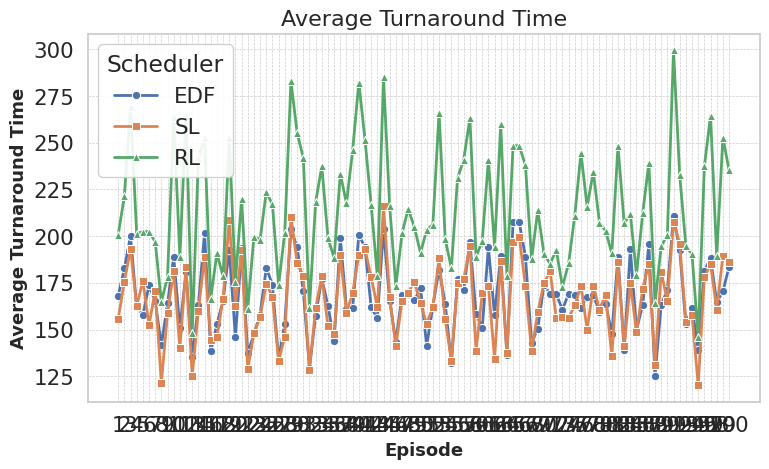

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

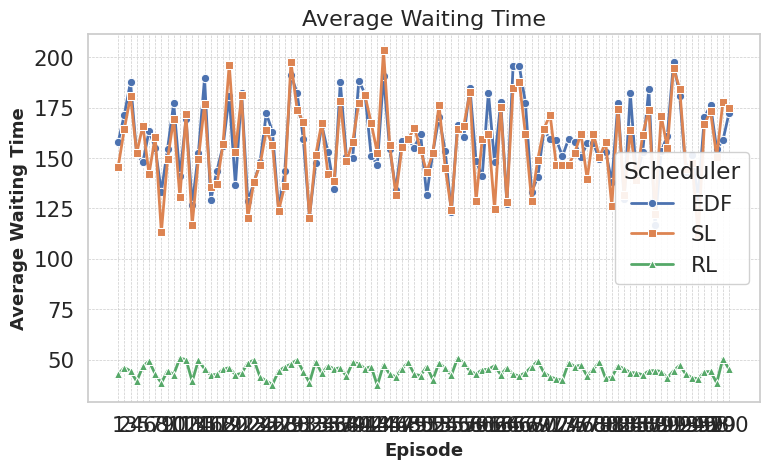

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

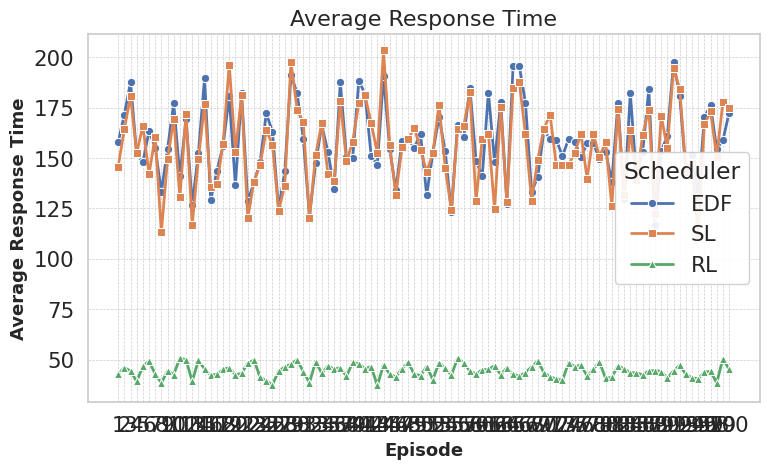

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

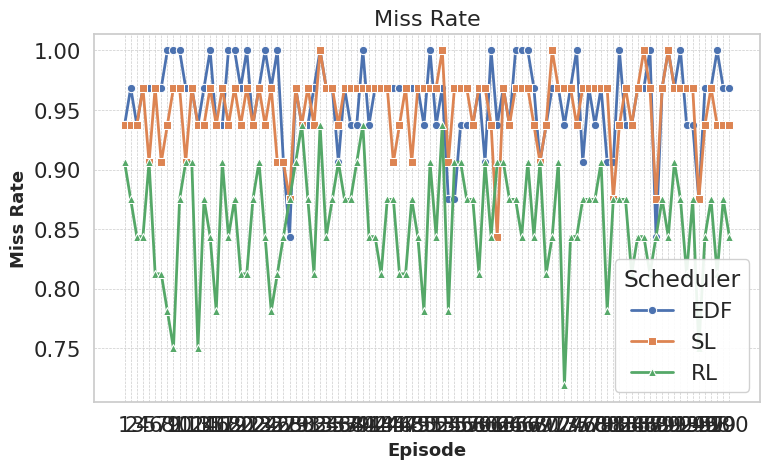

In [2]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Your raw log text
logtext1 = """
Episode 1:
 EDF: {'avg_turnaround': 167.98274825391698, 'avg_waiting': 157.90689760219757, 'miss_rate': 0.9375, 'avg_response': 157.90689760219757}
 SL : {'avg_turnaround': 155.7418828181201, 'avg_waiting': 145.66603216640075, 'miss_rate': 0.9375, 'avg_response': 145.66603216640075}
 RL : {'avg_turnaround': 200.6787941548579, 'avg_waiting': 42.77609457397211, 'miss_rate': 0.90625, 'avg_response': 42.77609457397211}
Episode 2:
 EDF: {'avg_turnaround': 182.694546652649, 'avg_waiting': 171.54886758598738, 'miss_rate': 0.96875, 'avg_response': 171.54886758598738}
 SL : {'avg_turnaround': 175.60445354371674, 'avg_waiting': 164.45877447705504, 'miss_rate': 0.9375, 'avg_response': 164.45877447705504}
 RL : {'avg_turnaround': 221.24525792466255, 'avg_waiting': 46.02089349621078, 'miss_rate': 0.875, 'avg_response': 46.02089349621078}
Episode 3:
 EDF: {'avg_turnaround': 200.0417535724209, 'avg_waiting': 187.6846651159487, 'miss_rate': 0.9375, 'avg_response': 187.6846651159487}
 SL : {'avg_turnaround': 193.0289272477682, 'avg_waiting': 180.67183879129584, 'miss_rate': 0.9375, 'avg_response': 180.67183879129584}
 RL : {'avg_turnaround': 268.99538558928907, 'avg_waiting': 44.27539352485109, 'miss_rate': 0.84375, 'avg_response': 44.27539352485109}
Episode 4:
 EDF: {'avg_turnaround': 161.91060906355995, 'avg_waiting': 151.80333458208764, 'miss_rate': 0.96875, 'avg_response': 151.80333458208764}
 SL : {'avg_turnaround': 162.44338320265376, 'avg_waiting': 152.3361087211815, 'miss_rate': 0.96875, 'avg_response': 152.3361087211815}
 RL : {'avg_turnaround': 201.4018621997909, 'avg_waiting': 39.120838262336015, 'miss_rate': 0.84375, 'avg_response': 39.120838262336015}
Episode 5:
 EDF: {'avg_turnaround': 157.90202545242275, 'avg_waiting': 147.9263313913176, 'miss_rate': 0.96875, 'avg_response': 147.9263313913176}
 SL : {'avg_turnaround': 176.09859172628, 'avg_waiting': 166.12289766517483, 'miss_rate': 0.90625, 'avg_response': 166.12289766517483}
 RL : {'avg_turnaround': 202.4119480799066, 'avg_waiting': 46.564354259806606, 'miss_rate': 0.90625, 'avg_response': 46.564354259806606}
Episode 6:
 EDF: {'avg_turnaround': 173.61497866404002, 'avg_waiting': 163.33218436300834, 'miss_rate': 0.96875, 'avg_response': 163.33218436300834}
 SL : {'avg_turnaround': 152.36618660187574, 'avg_waiting': 142.0833923008442, 'miss_rate': 0.96875, 'avg_response': 142.0833923008442}
 RL : {'avg_turnaround': 202.4457239790005, 'avg_waiting': 49.24687317459062, 'miss_rate': 0.8125, 'avg_response': 49.24687317459062}
Episode 7:
 EDF: {'avg_turnaround': 165.20472738478128, 'avg_waiting': 155.13507275078575, 'miss_rate': 0.96875, 'avg_response': 155.13507275078575}
 SL : {'avg_turnaround': 170.72358633118375, 'avg_waiting': 160.65393169718817, 'miss_rate': 0.90625, 'avg_response': 160.65393169718817}
 RL : {'avg_turnaround': 196.98994056426534, 'avg_waiting': 42.787318846111404, 'miss_rate': 0.8125, 'avg_response': 42.787318846111404}
Episode 8:
 EDF: {'avg_turnaround': 141.63838437263402, 'avg_waiting': 133.29013105408572, 'miss_rate': 1.0, 'avg_response': 133.29013105408572}
 SL : {'avg_turnaround': 121.50066473985402, 'avg_waiting': 113.15241142130573, 'miss_rate': 0.9375, 'avg_response': 113.15241142130573}
 RL : {'avg_turnaround': 164.87879137497973, 'avg_waiting': 38.35175414984263, 'miss_rate': 0.78125, 'avg_response': 38.35175414984263}
Episode 9:
 EDF: {'avg_turnaround': 163.97443361003528, 'avg_waiting': 154.49600420528637, 'miss_rate': 1.0, 'avg_response': 154.49600420528637}
 SL : {'avg_turnaround': 158.85416384363828, 'avg_waiting': 149.37573443888945, 'miss_rate': 0.96875, 'avg_response': 149.37573443888945}
 RL : {'avg_turnaround': 178.14084172253945, 'avg_waiting': 44.39586420041644, 'miss_rate': 0.75, 'avg_response': 44.39586420041644}
Episode 10:
 EDF: {'avg_turnaround': 189.01247487949436, 'avg_waiting': 177.21544409049937, 'miss_rate': 1.0, 'avg_response': 177.21544409049937}
 SL : {'avg_turnaround': 181.29491772797482, 'avg_waiting': 169.4978869389799, 'miss_rate': 0.96875, 'avg_response': 169.4978869389799}
 RL : {'avg_turnaround': 263.6902744356716, 'avg_waiting': 42.532041677672055, 'miss_rate': 0.875, 'avg_response': 42.532041677672055}
Episode 11:
 EDF: {'avg_turnaround': 150.6375656173866, 'avg_waiting': 141.02396730047104, 'miss_rate': 0.96875, 'avg_response': 141.02396730047104}
 SL : {'avg_turnaround': 140.0811762767596, 'avg_waiting': 130.46757795984402, 'miss_rate': 0.90625, 'avg_response': 130.46757795984402}
 RL : {'avg_turnaround': 188.9562709752547, 'avg_waiting': 50.6950224465361, 'miss_rate': 0.90625, 'avg_response': 50.6950224465361}
Episode 12:
 EDF: {'avg_turnaround': 180.88620567837236, 'avg_waiting': 169.4417262321452, 'miss_rate': 0.96875, 'avg_response': 169.4417262321452}
 SL : {'avg_turnaround': 183.22775571370912, 'avg_waiting': 171.7832762674819, 'miss_rate': 0.96875, 'avg_response': 171.7832762674819}
 RL : {'avg_turnaround': 264.5172717158907, 'avg_waiting': 49.92222921744462, 'miss_rate': 0.90625, 'avg_response': 49.92222921744462}
Episode 13:
 EDF: {'avg_turnaround': 135.2063336362809, 'avg_waiting': 126.88084123932774, 'miss_rate': 0.9375, 'avg_response': 126.88084123932774}
 SL : {'avg_turnaround': 125.17236449576318, 'avg_waiting': 116.84687209880998, 'miss_rate': 0.9375, 'avg_response': 116.84687209880998}
 RL : {'avg_turnaround': 148.11534262239553, 'avg_waiting': 39.178478354696324, 'miss_rate': 0.75, 'avg_response': 39.178478354696324}
Episode 14:
 EDF: {'avg_turnaround': 163.09303996953568, 'avg_waiting': 152.41179813142492, 'miss_rate': 0.96875, 'avg_response': 152.41179813142492}
 SL : {'avg_turnaround': 160.1114490387386, 'avg_waiting': 149.43020720062796, 'miss_rate': 0.9375, 'avg_response': 149.43020720062796}
 RL : {'avg_turnaround': 241.57719552615222, 'avg_waiting': 49.59418643948878, 'miss_rate': 0.875, 'avg_response': 49.59418643948878}
Episode 15:
 EDF: {'avg_turnaround': 201.77090683548784, 'avg_waiting': 189.69684008316992, 'miss_rate': 1.0, 'avg_response': 189.69684008316992}
 SL : {'avg_turnaround': 188.80373488026436, 'avg_waiting': 176.72966812794652, 'miss_rate': 0.96875, 'avg_response': 176.72966812794652}
 RL : {'avg_turnaround': 252.69493754528614, 'avg_waiting': 45.336045214648955, 'miss_rate': 0.84375, 'avg_response': 45.336045214648955}
Episode 16:
 EDF: {'avg_turnaround': 138.30954944419807, 'avg_waiting': 129.0595280877253, 'miss_rate': 0.9375, 'avg_response': 129.0595280877253}
 SL : {'avg_turnaround': 144.68094593767103, 'avg_waiting': 135.43092458119824, 'miss_rate': 0.9375, 'avg_response': 135.43092458119824}
 RL : {'avg_turnaround': 166.5654892779576, 'avg_waiting': 42.22493164760198, 'miss_rate': 0.78125, 'avg_response': 42.22493164760198}
Episode 17:
 EDF: {'avg_turnaround': 152.84056210804138, 'avg_waiting': 143.65465166087205, 'miss_rate': 0.9375, 'avg_response': 143.65465166087205}
 SL : {'avg_turnaround': 146.12915437212942, 'avg_waiting': 136.94324392496003, 'miss_rate': 0.96875, 'avg_response': 136.94324392496003}
 RL : {'avg_turnaround': 190.76941564795052, 'avg_waiting': 42.67700753480049, 'miss_rate': 0.90625, 'avg_response': 42.67700753480049}
Episode 18:
 EDF: {'avg_turnaround': 165.52188012600314, 'avg_waiting': 156.10217196013457, 'miss_rate': 1.0, 'avg_response': 156.10217196013457}
 SL : {'avg_turnaround': 166.57969705328748, 'avg_waiting': 157.15998888741893, 'miss_rate': 0.9375, 'avg_response': 157.15998888741893}
 RL : {'avg_turnaround': 178.43514253367826, 'avg_waiting': 45.051060282128624, 'miss_rate': 0.84375, 'avg_response': 45.051060282128624}
Episode 19:
 EDF: {'avg_turnaround': 192.72717498242926, 'avg_waiting': 180.62212311395183, 'miss_rate': 1.0, 'avg_response': 180.62212311395183}
 SL : {'avg_turnaround': 208.44804674117665, 'avg_waiting': 196.34299487269925, 'miss_rate': 0.96875, 'avg_response': 196.34299487269925}
 RL : {'avg_turnaround': 252.4865891547497, 'avg_waiting': 45.96696274136567, 'miss_rate': 0.875, 'avg_response': 45.96696274136567}
Episode 20:
 EDF: {'avg_turnaround': 145.9590478436283, 'avg_waiting': 136.56992310150972, 'miss_rate': 0.96875, 'avg_response': 136.56992310150972}
 SL : {'avg_turnaround': 162.54046104697002, 'avg_waiting': 153.1513363048514, 'miss_rate': 0.9375, 'avg_response': 153.1513363048514}
 RL : {'avg_turnaround': 175.7001423649998, 'avg_waiting': 42.375293814051076, 'miss_rate': 0.8125, 'avg_response': 42.375293814051076}
Episode 21:
 EDF: {'avg_turnaround': 193.40580119002027, 'avg_waiting': 182.1509642124993, 'miss_rate': 1.0, 'avg_response': 182.1509642124993}
 SL : {'avg_turnaround': 192.33667615197749, 'avg_waiting': 181.08183917445643, 'miss_rate': 0.96875, 'avg_response': 181.08183917445643}
 RL : {'avg_turnaround': 219.7242794129837, 'avg_waiting': 43.14650771896099, 'miss_rate': 0.8125, 'avg_response': 43.14650771896099}
Episode 22:
 EDF: {'avg_turnaround': 137.3340770871055, 'avg_waiting': 128.62393629395044, 'miss_rate': 0.9375, 'avg_response': 128.62393629395044}
 SL : {'avg_turnaround': 128.89052264657283, 'avg_waiting': 120.18038185341774, 'miss_rate': 0.9375, 'avg_response': 120.18038185341774}
 RL : {'avg_turnaround': 161.16239542534788, 'avg_waiting': 48.20998269035205, 'miss_rate': 0.875, 'avg_response': 48.20998269035205}
Episode 23:
 EDF: {'avg_turnaround': 147.50524079404644, 'avg_waiting': 137.71296144128303, 'miss_rate': 0.96875, 'avg_response': 137.71296144128303}
 SL : {'avg_turnaround': 148.05952513077406, 'avg_waiting': 138.26724577801065, 'miss_rate': 0.96875, 'avg_response': 138.26724577801065}
 RL : {'avg_turnaround': 199.76989489616724, 'avg_waiting': 49.73841995221161, 'miss_rate': 0.90625, 'avg_response': 49.73841995221161}
Episode 24:
 EDF: {'avg_turnaround': 158.05409284047187, 'avg_waiting': 148.0442170249441, 'miss_rate': 1.0, 'avg_response': 148.0442170249441}
 SL : {'avg_turnaround': 156.62544623379617, 'avg_waiting': 146.61557041826836, 'miss_rate': 0.9375, 'avg_response': 146.61557041826836}
 RL : {'avg_turnaround': 198.14082179395834, 'avg_waiting': 41.32905423969132, 'miss_rate': 0.84375, 'avg_response': 41.32905423969132}
Episode 25:
 EDF: {'avg_turnaround': 183.02365157700152, 'avg_waiting': 172.184819411208, 'miss_rate': 0.96875, 'avg_response': 172.184819411208}
 SL : {'avg_turnaround': 174.5401681216553, 'avg_waiting': 163.70133595586182, 'miss_rate': 0.96875, 'avg_response': 163.70133595586182}
 RL : {'avg_turnaround': 223.662549845306, 'avg_waiting': 39.382338540430005, 'miss_rate': 0.78125, 'avg_response': 39.382338540430005}
Episode 26:
 EDF: {'avg_turnaround': 174.0252260834471, 'avg_waiting': 163.16100337605758, 'miss_rate': 1.0, 'avg_response': 163.16100337605758}
 SL : {'avg_turnaround': 167.5354020015248, 'avg_waiting': 156.6711792941352, 'miss_rate': 0.90625, 'avg_response': 156.6711792941352}
 RL : {'avg_turnaround': 216.95263452800864, 'avg_waiting': 37.49707856214868, 'miss_rate': 0.8125, 'avg_response': 37.49707856214868}
Episode 27:
 EDF: {'avg_turnaround': 133.88234404613732, 'avg_waiting': 124.53644257317745, 'miss_rate': 0.90625, 'avg_response': 124.53644257317745}
 SL : {'avg_turnaround': 133.20166862649805, 'avg_waiting': 123.85576715353827, 'miss_rate': 0.90625, 'avg_response': 123.85576715353827}
 RL : {'avg_turnaround': 173.71953535108463, 'avg_waiting': 44.27868038413007, 'miss_rate': 0.84375, 'avg_response': 44.27868038413007}
Episode 28:
 EDF: {'avg_turnaround': 153.24629976611786, 'avg_waiting': 143.430199635591, 'miss_rate': 0.84375, 'avg_response': 143.430199635591}
 SL : {'avg_turnaround': 146.15213588459696, 'avg_waiting': 136.33603575407017, 'miss_rate': 0.875, 'avg_response': 136.33603575407017}
 RL : {'avg_turnaround': 201.88407231908545, 'avg_waiting': 46.2579242163917, 'miss_rate': 0.875, 'avg_response': 46.2579242163917}
Episode 29:
 EDF: {'avg_turnaround': 203.96012142551035, 'avg_waiting': 191.44592407699193, 'miss_rate': 0.96875, 'avg_response': 191.44592407699193}
 SL : {'avg_turnaround': 210.21952712296726, 'avg_waiting': 197.70532977444884, 'miss_rate': 0.96875, 'avg_response': 197.70532977444884}
 RL : {'avg_turnaround': 282.9267948169224, 'avg_waiting': 47.73558471869709, 'miss_rate': 0.90625, 'avg_response': 47.73558471869709}
Episode 30:
 EDF: {'avg_turnaround': 193.94792561226285, 'avg_waiting': 182.2044713003795, 'miss_rate': 0.9375, 'avg_response': 182.2044713003795}
 SL : {'avg_turnaround': 185.82030745609714, 'avg_waiting': 174.07685314421377, 'miss_rate': 0.9375, 'avg_response': 174.07685314421377}
 RL : {'avg_turnaround': 255.36039448551054, 'avg_waiting': 49.880354140898795, 'miss_rate': 0.9375, 'avg_response': 49.880354140898795}
Episode 31:
 EDF: {'avg_turnaround': 170.60719659457186, 'avg_waiting': 159.59245095391978, 'miss_rate': 0.9375, 'avg_response': 159.59245095391978}
 SL : {'avg_turnaround': 178.74043894191547, 'avg_waiting': 167.72569330126336, 'miss_rate': 0.96875, 'avg_response': 167.72569330126336}
 RL : {'avg_turnaround': 241.89839003818304, 'avg_waiting': 44.01083857080841, 'miss_rate': 0.875, 'avg_response': 44.01083857080841}
Episode 32:
 EDF: {'avg_turnaround': 129.62617348603362, 'avg_waiting': 121.2322824577074, 'miss_rate': 0.96875, 'avg_response': 121.2322824577074}
 SL : {'avg_turnaround': 128.56423862658028, 'avg_waiting': 120.17034759825411, 'miss_rate': 0.9375, 'avg_response': 120.17034759825411}
 RL : {'avg_turnaround': 161.55740137407466, 'avg_waiting': 38.52874584600482, 'miss_rate': 0.8125, 'avg_response': 38.52874584600482}
Episode 33:
 EDF: {'avg_turnaround': 157.47810617415766, 'avg_waiting': 147.3364227302967, 'miss_rate': 1.0, 'avg_response': 147.3364227302967}
 SL : {'avg_turnaround': 161.55748935720297, 'avg_waiting': 151.41580591334198, 'miss_rate': 1.0, 'avg_response': 151.41580591334198}
 RL : {'avg_turnaround': 218.15936633650574, 'avg_waiting': 48.97528723314296, 'miss_rate': 0.9375, 'avg_response': 48.97528723314296}
Episode 34:
 EDF: {'avg_turnaround': 177.3222645922842, 'avg_waiting': 166.34357658679446, 'miss_rate': 0.96875, 'avg_response': 166.34357658679446}
 SL : {'avg_turnaround': 178.43980163359652, 'avg_waiting': 167.4611136281068, 'miss_rate': 0.96875, 'avg_response': 167.4611136281068}
 RL : {'avg_turnaround': 237.3003300787032, 'avg_waiting': 43.12624701869696, 'miss_rate': 0.84375, 'avg_response': 43.12624701869696}
Episode 35:
 EDF: {'avg_turnaround': 162.75763744644536, 'avg_waiting': 152.97148884127805, 'miss_rate': 0.96875, 'avg_response': 152.97148884127805}
 SL : {'avg_turnaround': 151.88204523609892, 'avg_waiting': 142.0958966309316, 'miss_rate': 0.96875, 'avg_response': 142.0958966309316}
 RL : {'avg_turnaround': 198.9457896580131, 'avg_waiting': 46.87856371172387, 'miss_rate': 0.875, 'avg_response': 46.87856371172387}
Episode 36:
 EDF: {'avg_turnaround': 144.08186466740304, 'avg_waiting': 134.88355309976882, 'miss_rate': 0.90625, 'avg_response': 134.88355309976882}
 SL : {'avg_turnaround': 147.68473522499292, 'avg_waiting': 138.48642365735873, 'miss_rate': 0.9375, 'avg_response': 138.48642365735873}
 RL : {'avg_turnaround': 188.27772757110046, 'avg_waiting': 45.244485457697216, 'miss_rate': 0.90625, 'avg_response': 45.244485457697216}
Episode 37:
 EDF: {'avg_turnaround': 199.18753206985775, 'avg_waiting': 187.66990636340526, 'miss_rate': 0.96875, 'avg_response': 187.66990636340526}
 SL : {'avg_turnaround': 190.0496217028778, 'avg_waiting': 178.5319959964254, 'miss_rate': 0.96875, 'avg_response': 178.5319959964254}
 RL : {'avg_turnaround': 233.46917268575692, 'avg_waiting': 45.948297796057226, 'miss_rate': 0.875, 'avg_response': 45.948297796057226}
Episode 38:
 EDF: {'avg_turnaround': 161.2052848950752, 'avg_waiting': 150.49146159034882, 'miss_rate': 0.9375, 'avg_response': 150.49146159034882}
 SL : {'avg_turnaround': 159.0136168924653, 'avg_waiting': 148.29979358773892, 'miss_rate': 0.96875, 'avg_response': 148.29979358773892}
 RL : {'avg_turnaround': 217.47596291664544, 'avg_waiting': 41.66676547549901, 'miss_rate': 0.875, 'avg_response': 41.66676547549901}
Episode 39:
 EDF: {'avg_turnaround': 161.58169595861767, 'avg_waiting': 150.03831802382115, 'miss_rate': 0.9375, 'avg_response': 150.03831802382115}
 SL : {'avg_turnaround': 169.59499734666966, 'avg_waiting': 158.0516194118732, 'miss_rate': 0.96875, 'avg_response': 158.0516194118732}
 RL : {'avg_turnaround': 245.96884458839813, 'avg_waiting': 48.52160222641957, 'miss_rate': 0.90625, 'avg_response': 48.52160222641957}
Episode 40:
 EDF: {'avg_turnaround': 200.81861227151262, 'avg_waiting': 188.33514424541457, 'miss_rate': 1.0, 'avg_response': 188.33514424541457}
 SL : {'avg_turnaround': 189.83087356009224, 'avg_waiting': 177.34740553399422, 'miss_rate': 0.96875, 'avg_response': 177.34740553399422}
 RL : {'avg_turnaround': 282.1775357943149, 'avg_waiting': 47.935378570224906, 'miss_rate': 0.9375, 'avg_response': 47.935378570224906}
Episode 41:
 EDF: {'avg_turnaround': 193.9230679427584, 'avg_waiting': 181.94105453182476, 'miss_rate': 0.9375, 'avg_response': 181.94105453182476}
 SL : {'avg_turnaround': 193.05173679586167, 'avg_waiting': 181.06972338492798, 'miss_rate': 0.96875, 'avg_response': 181.06972338492798}
 RL : {'avg_turnaround': 251.5934680283275, 'avg_waiting': 45.48390322867942, 'miss_rate': 0.84375, 'avg_response': 45.48390322867942}
Episode 42:
 EDF: {'avg_turnaround': 161.8527215110097, 'avg_waiting': 151.05694071945422, 'miss_rate': 0.96875, 'avg_response': 151.05694071945422}
 SL : {'avg_turnaround': 178.25103523650543, 'avg_waiting': 167.45525444495004, 'miss_rate': 0.96875, 'avg_response': 167.45525444495004}
 RL : {'avg_turnaround': 216.7021015292605, 'avg_waiting': 46.484157871287145, 'miss_rate': 0.84375, 'avg_response': 46.484157871287145}
Episode 43:
 EDF: {'avg_turnaround': 156.06900672001566, 'avg_waiting': 146.72847174861104, 'miss_rate': 0.96875, 'avg_response': 146.72847174861104}
 SL : {'avg_turnaround': 161.8315553879342, 'avg_waiting': 152.4910204165296, 'miss_rate': 0.96875, 'avg_response': 152.4910204165296}
 RL : {'avg_turnaround': 178.54481605882654, 'avg_waiting': 37.10141935567466, 'miss_rate': 0.8125, 'avg_response': 37.10141935567466}
Episode 44:
 EDF: {'avg_turnaround': 203.56638478700665, 'avg_waiting': 190.72158656302898, 'miss_rate': 0.96875, 'avg_response': 190.72158656302898}
 SL : {'avg_turnaround': 216.24936407322275, 'avg_waiting': 203.40456584924513, 'miss_rate': 0.96875, 'avg_response': 203.40456584924513}
 RL : {'avg_turnaround': 284.93555700066736, 'avg_waiting': 47.357234126214635, 'miss_rate': 0.875, 'avg_response': 47.357234126214635}
Episode 45:
 EDF: {'avg_turnaround': 165.49601839270784, 'avg_waiting': 154.66580969149675, 'miss_rate': 0.96875, 'avg_response': 154.66580969149675}
 SL : {'avg_turnaround': 167.50013460261616, 'avg_waiting': 156.6699259014052, 'miss_rate': 0.90625, 'avg_response': 156.6699259014052}
 RL : {'avg_turnaround': 216.00691598759295, 'avg_waiting': 42.76444900202134, 'miss_rate': 0.875, 'avg_response': 42.76444900202134}
Episode 46:
 EDF: {'avg_turnaround': 143.35772417372687, 'avg_waiting': 134.09206775744897, 'miss_rate': 0.96875, 'avg_response': 134.09206775744897}
 SL : {'avg_turnaround': 141.02127335701806, 'avg_waiting': 131.75561694074025, 'miss_rate': 0.9375, 'avg_response': 131.75561694074025}
 RL : {'avg_turnaround': 173.05974841426232, 'avg_waiting': 41.38165846079091, 'miss_rate': 0.8125, 'avg_response': 41.38165846079091}
Episode 47:
 EDF: {'avg_turnaround': 168.58620786325457, 'avg_waiting': 158.6308041601896, 'miss_rate': 0.96875, 'avg_response': 158.6308041601896}
 SL : {'avg_turnaround': 165.33683979965357, 'avg_waiting': 155.38143609658874, 'miss_rate': 0.96875, 'avg_response': 155.38143609658874}
 RL : {'avg_turnaround': 201.47306100009547, 'avg_waiting': 45.48337229670793, 'miss_rate': 0.8125, 'avg_response': 45.48337229670793}
Episode 48:
 EDF: {'avg_turnaround': 169.88311472180658, 'avg_waiting': 159.3531456802407, 'miss_rate': 0.96875, 'avg_response': 159.3531456802407}
 SL : {'avg_turnaround': 169.77255614114858, 'avg_waiting': 159.24258709958266, 'miss_rate': 0.90625, 'avg_response': 159.24258709958266}
 RL : {'avg_turnaround': 214.63360557096928, 'avg_waiting': 48.52490934592938, 'miss_rate': 0.875, 'avg_response': 48.52490934592938}
Episode 49:
 EDF: {'avg_turnaround': 165.5863074098723, 'avg_waiting': 155.15502927632804, 'miss_rate': 0.96875, 'avg_response': 155.15502927632804}
 SL : {'avg_turnaround': 175.58616049081388, 'avg_waiting': 165.15488235726957, 'miss_rate': 0.96875, 'avg_response': 165.15488235726957}
 RL : {'avg_turnaround': 204.7739834419087, 'avg_waiting': 42.658448292666044, 'miss_rate': 0.84375, 'avg_response': 42.658448292666044}
Episode 50:
 EDF: {'avg_turnaround': 172.04971725230524, 'avg_waiting': 162.07589841619262, 'miss_rate': 0.9375, 'avg_response': 162.07589841619262}
 SL : {'avg_turnaround': 164.11043888212137, 'avg_waiting': 154.13662004600863, 'miss_rate': 0.96875, 'avg_response': 154.13662004600863}
 RL : {'avg_turnaround': 190.97741384111623, 'avg_waiting': 42.03242513125095, 'miss_rate': 0.78125, 'avg_response': 42.03242513125095}
Episode 51:
 EDF: {'avg_turnaround': 141.30317660115236, 'avg_waiting': 131.46928726593381, 'miss_rate': 1.0, 'avg_response': 131.46928726593381}
 SL : {'avg_turnaround': 152.91521161578552, 'avg_waiting': 143.08132228056698, 'miss_rate': 0.96875, 'avg_response': 143.08132228056698}
 RL : {'avg_turnaround': 203.48438896119387, 'avg_waiting': 46.49346617482766, 'miss_rate': 0.90625, 'avg_response': 46.49346617482766}
Episode 52:
 EDF: {'avg_turnaround': 162.5593179078349, 'avg_waiting': 152.7625849795256, 'miss_rate': 0.9375, 'avg_response': 152.7625849795256}
 SL : {'avg_turnaround': 162.24078129394033, 'avg_waiting': 152.44404836563106, 'miss_rate': 0.96875, 'avg_response': 152.44404836563106}
 RL : {'avg_turnaround': 206.15048031835545, 'avg_waiting': 40.047767215318245, 'miss_rate': 0.84375, 'avg_response': 40.047767215318245}
Episode 53:
 EDF: {'avg_turnaround': 182.13060572821155, 'avg_waiting': 170.46131020688904, 'miss_rate': 0.96875, 'avg_response': 170.46131020688904}
 SL : {'avg_turnaround': 188.1279892091263, 'avg_waiting': 176.45869368780384, 'miss_rate': 1.0, 'avg_response': 176.45869368780384}
 RL : {'avg_turnaround': 265.89276806061343, 'avg_waiting': 48.43918939004262, 'miss_rate': 0.9375, 'avg_response': 48.43918939004262}
Episode 54:
 EDF: {'avg_turnaround': 163.79031193101596, 'avg_waiting': 153.4535717099986, 'miss_rate': 0.875, 'avg_response': 153.4535717099986}
 SL : {'avg_turnaround': 155.5469434382007, 'avg_waiting': 145.21020321718333, 'miss_rate': 0.90625, 'avg_response': 145.21020321718333}
 RL : {'avg_turnaround': 198.36092051999685, 'avg_waiting': 45.60013337888115, 'miss_rate': 0.78125, 'avg_response': 45.60013337888115}
Episode 55:
 EDF: {'avg_turnaround': 132.12660355039782, 'avg_waiting': 123.01160484371661, 'miss_rate': 0.875, 'avg_response': 123.01160484371661}
 SL : {'avg_turnaround': 133.34173382491247, 'avg_waiting': 124.22673511823123, 'miss_rate': 0.96875, 'avg_response': 124.22673511823123}
 RL : {'avg_turnaround': 182.81381616015543, 'avg_waiting': 42.21090460362007, 'miss_rate': 0.90625, 'avg_response': 42.21090460362007}
Episode 56:
 EDF: {'avg_turnaround': 177.05417402054314, 'avg_waiting': 166.46600762710204, 'miss_rate': 0.9375, 'avg_response': 166.46600762710204}
 SL : {'avg_turnaround': 175.09491090732527, 'avg_waiting': 164.5067445138842, 'miss_rate': 0.96875, 'avg_response': 164.5067445138842}
 RL : {'avg_turnaround': 230.9893076249391, 'avg_waiting': 50.64120029809063, 'miss_rate': 0.90625, 'avg_response': 50.64120029809063}
Episode 57:
 EDF: {'avg_turnaround': 171.41340085394012, 'avg_waiting': 160.24163227324345, 'miss_rate': 0.9375, 'avg_response': 160.24163227324345}
 SL : {'avg_turnaround': 177.04959763854689, 'avg_waiting': 165.8778290578503, 'miss_rate': 0.96875, 'avg_response': 165.8778290578503}
 RL : {'avg_turnaround': 240.93369328540794, 'avg_waiting': 48.44790318395835, 'miss_rate': 0.875, 'avg_response': 48.44790318395835}
Episode 58:
 EDF: {'avg_turnaround': 197.0537122767701, 'avg_waiting': 184.97131019089613, 'miss_rate': 0.9375, 'avg_response': 184.97131019089613}
 SL : {'avg_turnaround': 194.65355767136032, 'avg_waiting': 182.57115558548634, 'miss_rate': 0.9375, 'avg_response': 182.57115558548634}
 RL : {'avg_turnaround': 263.0677232237221, 'avg_waiting': 44.230757499315736, 'miss_rate': 0.875, 'avg_response': 44.230757499315736}
Episode 59:
 EDF: {'avg_turnaround': 158.35879747232394, 'avg_waiting': 148.55510319050535, 'miss_rate': 0.96875, 'avg_response': 148.55510319050535}
 SL : {'avg_turnaround': 138.42256609508172, 'avg_waiting': 128.61887181326315, 'miss_rate': 0.96875, 'avg_response': 128.61887181326315}
 RL : {'avg_turnaround': 188.88916014746516, 'avg_waiting': 42.826514852815336, 'miss_rate': 0.8125, 'avg_response': 42.826514852815336}
Episode 60:
 EDF: {'avg_turnaround': 151.0116156987505, 'avg_waiting': 141.01985480085668, 'miss_rate': 0.90625, 'avg_response': 141.01985480085668}
 SL : {'avg_turnaround': 169.55017650485323, 'avg_waiting': 159.55841560695941, 'miss_rate': 0.96875, 'avg_response': 159.55841560695941}
 RL : {'avg_turnaround': 197.45842624510635, 'avg_waiting': 44.93872556488081, 'miss_rate': 0.90625, 'avg_response': 44.93872556488081}
Episode 61:
 EDF: {'avg_turnaround': 193.98369004082548, 'avg_waiting': 182.5193294838524, 'miss_rate': 1.0, 'avg_response': 182.5193294838524}
 SL : {'avg_turnaround': 173.54694714541492, 'avg_waiting': 162.0825865884418, 'miss_rate': 0.9375, 'avg_response': 162.0825865884418}
 RL : {'avg_turnaround': 240.8035873253991, 'avg_waiting': 45.12386637555206, 'miss_rate': 0.84375, 'avg_response': 45.12386637555206}
Episode 62:
 EDF: {'avg_turnaround': 157.8816714018749, 'avg_waiting': 148.13848523871906, 'miss_rate': 0.9375, 'avg_response': 148.13848523871906}
 SL : {'avg_turnaround': 134.21633165962982, 'avg_waiting': 124.47314549647402, 'miss_rate': 0.84375, 'avg_response': 124.47314549647402}
 RL : {'avg_turnaround': 194.01989044219965, 'avg_waiting': 46.90451592806164, 'miss_rate': 0.90625, 'avg_response': 46.90451592806164}
Episode 63:
 EDF: {'avg_turnaround': 189.34720821709513, 'avg_waiting': 177.65470727512601, 'miss_rate': 0.96875, 'avg_response': 177.65470727512601}
 SL : {'avg_turnaround': 186.8230992868296, 'avg_waiting': 175.13059834486037, 'miss_rate': 0.96875, 'avg_response': 175.13059834486037}
 RL : {'avg_turnaround': 259.7669734424777, 'avg_waiting': 42.48105138250878, 'miss_rate': 0.90625, 'avg_response': 42.48105138250878}
Episode 64:
 EDF: {'avg_turnaround': 136.53782087985806, 'avg_waiting': 127.36940045060301, 'miss_rate': 0.9375, 'avg_response': 127.36940045060301}
 SL : {'avg_turnaround': 137.32604173072613, 'avg_waiting': 128.15762130147107, 'miss_rate': 0.9375, 'avg_response': 128.15762130147107}
 RL : {'avg_turnaround': 178.82661414693106, 'avg_waiting': 45.890395753735106, 'miss_rate': 0.875, 'avg_response': 45.890395753735106}
Episode 65:
 EDF: {'avg_turnaround': 207.75864457586576, 'avg_waiting': 195.68436522169006, 'miss_rate': 1.0, 'avg_response': 195.68436522169006}
 SL : {'avg_turnaround': 197.0301674088918, 'avg_waiting': 184.95588805471598, 'miss_rate': 0.96875, 'avg_response': 184.95588805471598}
 RL : {'avg_turnaround': 248.46881705942405, 'avg_waiting': 42.67597227943107, 'miss_rate': 0.875, 'avg_response': 42.67597227943107}
Episode 66:
 EDF: {'avg_turnaround': 207.3619859745475, 'avg_waiting': 195.72498101293095, 'miss_rate': 1.0, 'avg_response': 195.72498101293095}
 SL : {'avg_turnaround': 199.59444674290228, 'avg_waiting': 187.9574417812856, 'miss_rate': 0.96875, 'avg_response': 187.9574417812856}
 RL : {'avg_turnaround': 248.31155988735802, 'avg_waiting': 41.78560772991715, 'miss_rate': 0.84375, 'avg_response': 41.78560772991715}
Episode 67:
 EDF: {'avg_turnaround': 188.93203663510403, 'avg_waiting': 177.5138220375534, 'miss_rate': 1.0, 'avg_response': 177.5138220375534}
 SL : {'avg_turnaround': 173.31591828606977, 'avg_waiting': 161.89770368851913, 'miss_rate': 0.96875, 'avg_response': 161.89770368851913}
 RL : {'avg_turnaround': 237.88156226842875, 'avg_waiting': 43.49192339587145, 'miss_rate': 0.90625, 'avg_response': 43.49192339587145}
Episode 68:
 EDF: {'avg_turnaround': 142.86513388339324, 'avg_waiting': 133.18728737266827, 'miss_rate': 0.96875, 'avg_response': 133.18728737266827}
 SL : {'avg_turnaround': 138.5461472301626, 'avg_waiting': 128.86830071943757, 'miss_rate': 0.9375, 'avg_response': 128.86830071943757}
 RL : {'avg_turnaround': 187.7373652251295, 'avg_waiting': 46.36574740545304, 'miss_rate': 0.84375, 'avg_response': 46.36574740545304}
Episode 69:
 EDF: {'avg_turnaround': 150.5641469205538, 'avg_waiting': 140.56478809901216, 'miss_rate': 0.90625, 'avg_response': 140.56478809901216}
 SL : {'avg_turnaround': 159.27356322302649, 'avg_waiting': 149.27420440148487, 'miss_rate': 0.90625, 'avg_response': 149.27420440148487}
 RL : {'avg_turnaround': 213.77350804714587, 'avg_waiting': 49.24998311167388, 'miss_rate': 0.90625, 'avg_response': 49.24998311167388}
Episode 70:
 EDF: {'avg_turnaround': 173.93700193122996, 'avg_waiting': 163.72315598696656, 'miss_rate': 0.9375, 'avg_response': 163.72315598696656}
 SL : {'avg_turnaround': 174.83459168838286, 'avg_waiting': 164.62074574411932, 'miss_rate': 0.9375, 'avg_response': 164.62074574411932}
 RL : {'avg_turnaround': 190.591428285164, 'avg_waiting': 43.50088664019427, 'miss_rate': 0.8125, 'avg_response': 43.50088664019427}
Episode 71:
 EDF: {'avg_turnaround': 169.2857455160459, 'avg_waiting': 159.49076679000805, 'miss_rate': 0.96875, 'avg_response': 159.49076679000805}
 SL : {'avg_turnaround': 181.29669122341008, 'avg_waiting': 171.50171249737227, 'miss_rate': 1.0, 'avg_response': 171.50171249737227}
 RL : {'avg_turnaround': 185.08903272916785, 'avg_waiting': 41.445528468090025, 'miss_rate': 0.84375, 'avg_response': 41.445528468090025}
Episode 72:
 EDF: {'avg_turnaround': 168.8722501225303, 'avg_waiting': 159.16537407193042, 'miss_rate': 0.96875, 'avg_response': 159.16537407193042}
 SL : {'avg_turnaround': 156.13169890332196, 'avg_waiting': 146.4248228527222, 'miss_rate': 0.96875, 'avg_response': 146.4248228527222}
 RL : {'avg_turnaround': 192.72556296076647, 'avg_waiting': 40.274484151010604, 'miss_rate': 0.90625, 'avg_response': 40.274484151010604}
Episode 73:
 EDF: {'avg_turnaround': 160.68649838955733, 'avg_waiting': 150.89184278292475, 'miss_rate': 0.9375, 'avg_response': 150.89184278292475}
 SL : {'avg_turnaround': 156.59005265396627, 'avg_waiting': 146.79539704733378, 'miss_rate': 0.96875, 'avg_response': 146.79539704733378}
 RL : {'avg_turnaround': 172.90522013061084, 'avg_waiting': 39.74191058649149, 'miss_rate': 0.71875, 'avg_response': 39.74191058649149}
Episode 74:
 EDF: {'avg_turnaround': 169.2389393836343, 'avg_waiting': 159.58440279999013, 'miss_rate': 0.96875, 'avg_response': 159.58440279999013}
 SL : {'avg_turnaround': 156.16022206674074, 'avg_waiting': 146.5056854830967, 'miss_rate': 0.96875, 'avg_response': 146.5056854830967}
 RL : {'avg_turnaround': 185.44980372313208, 'avg_waiting': 48.39407403683333, 'miss_rate': 0.84375, 'avg_response': 48.39407403683333}
Episode 75:
 EDF: {'avg_turnaround': 168.25957780975256, 'avg_waiting': 157.82182252328047, 'miss_rate': 1.0, 'avg_response': 157.82182252328047}
 SL : {'avg_turnaround': 163.12233281313365, 'avg_waiting': 152.68457752666166, 'miss_rate': 0.9375, 'avg_response': 152.68457752666166}
 RL : {'avg_turnaround': 211.0203306038521, 'avg_waiting': 46.52155413976851, 'miss_rate': 0.84375, 'avg_response': 46.52155413976851}
Episode 76:
 EDF: {'avg_turnaround': 161.80801893980103, 'avg_waiting': 150.54422771689204, 'miss_rate': 0.90625, 'avg_response': 150.54422771689204}
 SL : {'avg_turnaround': 173.4421929671267, 'avg_waiting': 162.1784017442177, 'miss_rate': 0.96875, 'avg_response': 162.1784017442177}
 RL : {'avg_turnaround': 244.4463328124988, 'avg_waiting': 47.19563307104029, 'miss_rate': 0.875, 'avg_response': 47.19563307104029}
Episode 77:
 EDF: {'avg_turnaround': 167.61875989128657, 'avg_waiting': 157.25662946643237, 'miss_rate': 0.96875, 'avg_response': 157.25662946643237}
 SL : {'avg_turnaround': 149.95409932945938, 'avg_waiting': 139.59196890460535, 'miss_rate': 0.96875, 'avg_response': 139.59196890460535}
 RL : {'avg_turnaround': 215.77252241755335, 'avg_waiting': 41.80680439362235, 'miss_rate': 0.875, 'avg_response': 41.80680439362235}
Episode 78:
 EDF: {'avg_turnaround': 168.4990406864375, 'avg_waiting': 157.39436361960986, 'miss_rate': 0.9375, 'avg_response': 157.39436361960986}
 SL : {'avg_turnaround': 173.12238428029144, 'avg_waiting': 162.0177072134638, 'miss_rate': 0.96875, 'avg_response': 162.0177072134638}
 RL : {'avg_turnaround': 234.37858719824837, 'avg_waiting': 45.14380586474864, 'miss_rate': 0.875, 'avg_response': 45.14380586474864}
Episode 79:
 EDF: {'avg_turnaround': 159.50133349047633, 'avg_waiting': 149.3355420185005, 'miss_rate': 0.96875, 'avg_response': 149.3355420185005}
 SL : {'avg_turnaround': 160.74126125772773, 'avg_waiting': 150.57546978575195, 'miss_rate': 0.96875, 'avg_response': 150.57546978575195}
 RL : {'avg_turnaround': 207.27142895635833, 'avg_waiting': 48.8269090441761, 'miss_rate': 0.90625, 'avg_response': 48.8269090441761}
Episode 80:
 EDF: {'avg_turnaround': 163.88054300728714, 'avg_waiting': 153.1199942557351, 'miss_rate': 0.90625, 'avg_response': 153.1199942557351}
 SL : {'avg_turnaround': 168.67426646656855, 'avg_waiting': 157.9137177150165, 'miss_rate': 0.96875, 'avg_response': 157.9137177150165}
 RL : {'avg_turnaround': 202.71719738989142, 'avg_waiting': 40.6054075599599, 'miss_rate': 0.78125, 'avg_response': 40.6054075599599}
Episode 81:
 EDF: {'avg_turnaround': 147.71373511830308, 'avg_waiting': 138.19995720992915, 'miss_rate': 0.90625, 'avg_response': 138.19995720992915}
 SL : {'avg_turnaround': 135.63645768369656, 'avg_waiting': 126.12267977532264, 'miss_rate': 0.875, 'avg_response': 126.12267977532264}
 RL : {'avg_turnaround': 190.8363009543467, 'avg_waiting': 41.21633825761771, 'miss_rate': 0.875, 'avg_response': 41.21633825761771}
Episode 82:
 EDF: {'avg_turnaround': 189.08639615839172, 'avg_waiting': 177.41352698169686, 'miss_rate': 1.0, 'avg_response': 177.41352698169686}
 SL : {'avg_turnaround': 186.15263422687147, 'avg_waiting': 174.47976505017664, 'miss_rate': 0.9375, 'avg_response': 174.47976505017664}
 RL : {'avg_turnaround': 248.28723906527603, 'avg_waiting': 46.90211934438055, 'miss_rate': 0.875, 'avg_response': 46.90211934438055}
Episode 83:
 EDF: {'avg_turnaround': 138.98422843716173, 'avg_waiting': 129.46461561378123, 'miss_rate': 0.9375, 'avg_response': 129.46461561378123}
 SL : {'avg_turnaround': 141.0803277134134, 'avg_waiting': 131.56071489003293, 'miss_rate': 0.96875, 'avg_response': 131.56071489003293}
 RL : {'avg_turnaround': 206.8330866727273, 'avg_waiting': 45.2722630062353, 'miss_rate': 0.875, 'avg_response': 45.2722630062353}
Episode 84:
 EDF: {'avg_turnaround': 192.89456723510787, 'avg_waiting': 182.08633309119747, 'miss_rate': 0.9375, 'avg_response': 182.08633309119747}
 SL : {'avg_turnaround': 174.84605727777162, 'avg_waiting': 164.03782313386125, 'miss_rate': 0.9375, 'avg_response': 164.03782313386125}
 RL : {'avg_turnaround': 211.92290068080035, 'avg_waiting': 43.53380611638915, 'miss_rate': 0.8125, 'avg_response': 43.53380611638915}
Episode 85:
 EDF: {'avg_turnaround': 149.86821759861232, 'avg_waiting': 140.40886230559929, 'miss_rate': 0.96875, 'avg_response': 140.40886230559929}
 SL : {'avg_turnaround': 148.48957508368864, 'avg_waiting': 139.0302197906756, 'miss_rate': 0.96875, 'avg_response': 139.0302197906756}
 RL : {'avg_turnaround': 179.37983268803487, 'avg_waiting': 43.32083036091528, 'miss_rate': 0.84375, 'avg_response': 43.32083036091528}
Episode 86:
 EDF: {'avg_turnaround': 163.16338245181493, 'avg_waiting': 153.08700741156275, 'miss_rate': 0.96875, 'avg_response': 153.08700741156275}
 SL : {'avg_turnaround': 171.72180219978554, 'avg_waiting': 161.64542715953343, 'miss_rate': 1.0, 'avg_response': 161.64542715953343}
 RL : {'avg_turnaround': 212.13656406455362, 'avg_waiting': 42.417551422995274, 'miss_rate': 0.84375, 'avg_response': 42.417551422995274}
Episode 87:
 EDF: {'avg_turnaround': 195.53715853245978, 'avg_waiting': 184.3177851633555, 'miss_rate': 1.0, 'avg_response': 184.3177851633555}
 SL : {'avg_turnaround': 185.30633387972736, 'avg_waiting': 174.0869605106231, 'miss_rate': 0.96875, 'avg_response': 174.0869605106231}
 RL : {'avg_turnaround': 239.08775315625454, 'avg_waiting': 44.28712543261197, 'miss_rate': 0.8125, 'avg_response': 44.28712543261197}
Episode 88:
 EDF: {'avg_turnaround': 125.18505806015627, 'avg_waiting': 116.60307683775673, 'miss_rate': 0.84375, 'avg_response': 116.60307683775673}
 SL : {'avg_turnaround': 130.87440720828658, 'avg_waiting': 122.29242598588709, 'miss_rate': 0.875, 'avg_response': 122.29242598588709}
 RL : {'avg_turnaround': 164.1228201436804, 'avg_waiting': 44.54491647147272, 'miss_rate': 0.84375, 'avg_response': 44.54491647147272}
Episode 89:
 EDF: {'avg_turnaround': 163.39246583606632, 'avg_waiting': 153.33100744422163, 'miss_rate': 0.96875, 'avg_response': 153.33100744422163}
 SL : {'avg_turnaround': 181.0466350993185, 'avg_waiting': 170.98517670747376, 'miss_rate': 0.96875, 'avg_response': 170.98517670747376}
 RL : {'avg_turnaround': 194.53244462275592, 'avg_waiting': 44.04421983006337, 'miss_rate': 0.875, 'avg_response': 44.04421983006337}
Episode 90:
 EDF: {'avg_turnaround': 171.1129280795036, 'avg_waiting': 161.05438920360757, 'miss_rate': 1.0, 'avg_response': 161.05438920360757}
 SL : {'avg_turnaround': 165.1110777743699, 'avg_waiting': 155.0525388984739, 'miss_rate': 1.0, 'avg_response': 155.0525388984739}
 RL : {'avg_turnaround': 200.737139972943, 'avg_waiting': 40.89298043284151, 'miss_rate': 0.84375, 'avg_response': 40.89298043284151}
Episode 91:
 EDF: {'avg_turnaround': 210.67719304686938, 'avg_waiting': 197.4690298505778, 'miss_rate': 0.96875, 'avg_response': 197.4690298505778}
 SL : {'avg_turnaround': 207.81368549291776, 'avg_waiting': 194.60552229662602, 'miss_rate': 0.96875, 'avg_response': 194.60552229662602}
 RL : {'avg_turnaround': 299.3176950794825, 'avg_waiting': 44.342075827379425, 'miss_rate': 0.90625, 'avg_response': 44.342075827379425}
Episode 92:
 EDF: {'avg_turnaround': 192.53875393640658, 'avg_waiting': 181.05547324621318, 'miss_rate': 1.0, 'avg_response': 181.05547324621318}
 SL : {'avg_turnaround': 195.9586057507597, 'avg_waiting': 184.4753250605663, 'miss_rate': 0.96875, 'avg_response': 184.4753250605663}
 RL : {'avg_turnaround': 232.58492675639758, 'avg_waiting': 47.13046614364231, 'miss_rate': 0.875, 'avg_response': 47.13046614364231}
Episode 93:
 EDF: {'avg_turnaround': 152.73965496971385, 'avg_waiting': 143.18857828561164, 'miss_rate': 0.9375, 'avg_response': 143.18857828561164}
 SL : {'avg_turnaround': 154.19429967589215, 'avg_waiting': 144.64322299178988, 'miss_rate': 0.96875, 'avg_response': 144.64322299178988}
 RL : {'avg_turnaround': 194.9651109757383, 'avg_waiting': 42.6866615750926, 'miss_rate': 0.8125, 'avg_response': 42.6866615750926}
Episode 94:
 EDF: {'avg_turnaround': 161.69508658237103, 'avg_waiting': 151.63362034396752, 'miss_rate': 0.9375, 'avg_response': 151.63362034396752}
 SL : {'avg_turnaround': 157.84808733791624, 'avg_waiting': 147.78662109951273, 'miss_rate': 0.96875, 'avg_response': 147.78662109951273}
 RL : {'avg_turnaround': 190.19341599978333, 'avg_waiting': 40.92953158023438, 'miss_rate': 0.875, 'avg_response': 40.92953158023438}
Episode 95:
 EDF: {'avg_turnaround': 139.23003169464462, 'avg_waiting': 130.765907305783, 'miss_rate': 0.875, 'avg_response': 130.765907305783}
 SL : {'avg_turnaround': 120.08744975038908, 'avg_waiting': 111.62332536152752, 'miss_rate': 0.875, 'avg_response': 111.62332536152752}
 RL : {'avg_turnaround': 146.0457887927221, 'avg_waiting': 40.405983516685325, 'miss_rate': 0.75, 'avg_response': 40.405983516685325}
Episode 96:
 EDF: {'avg_turnaround': 181.3942092330435, 'avg_waiting': 170.23311765647927, 'miss_rate': 0.96875, 'avg_response': 170.23311765647927}
 SL : {'avg_turnaround': 177.99528796718224, 'avg_waiting': 166.83419639061796, 'miss_rate': 0.9375, 'avg_response': 166.83419639061796}
 RL : {'avg_turnaround': 237.4770389424824, 'avg_waiting': 43.8569599807971, 'miss_rate': 0.84375, 'avg_response': 43.8569599807971}
Episode 97:
 EDF: {'avg_turnaround': 188.15570806662973, 'avg_waiting': 176.19191611034083, 'miss_rate': 0.96875, 'avg_response': 176.19191611034083}
 SL : {'avg_turnaround': 185.08377194410676, 'avg_waiting': 173.11997998781786, 'miss_rate': 0.96875, 'avg_response': 173.11997998781786}
 RL : {'avg_turnaround': 264.3944140267899, 'avg_waiting': 44.078933683098974, 'miss_rate': 0.875, 'avg_response': 44.078933683098974}
Episode 98:
 EDF: {'avg_turnaround': 164.61061709894065, 'avg_waiting': 154.44200821909428, 'miss_rate': 1.0, 'avg_response': 154.44200821909428}
 SL : {'avg_turnaround': 160.61257928550697, 'avg_waiting': 150.44397040566065, 'miss_rate': 0.9375, 'avg_response': 150.44397040566065}
 RL : {'avg_turnaround': 189.3066473509723, 'avg_waiting': 38.41687595554965, 'miss_rate': 0.8125, 'avg_response': 38.41687595554965}
Episode 99:
 EDF: {'avg_turnaround': 170.43099562573204, 'avg_waiting': 158.72378349406912, 'miss_rate': 0.96875, 'avg_response': 158.72378349406912}
 SL : {'avg_turnaround': 189.54708531683525, 'avg_waiting': 177.83987318517225, 'miss_rate': 0.9375, 'avg_response': 177.83987318517225}
 RL : {'avg_turnaround': 252.7623078740689, 'avg_waiting': 50.47684696591797, 'miss_rate': 0.875, 'avg_response': 50.47684696591797}
Episode 100:
 EDF: {'avg_turnaround': 183.56684056826583, 'avg_waiting': 172.41912412586973, 'miss_rate': 0.96875, 'avg_response': 172.41912412586973}
 SL : {'avg_turnaround': 186.19421203858482, 'avg_waiting': 175.04649559618872, 'miss_rate': 0.9375, 'avg_response': 175.04649559618872}
 RL : {'avg_turnaround': 235.31163178252046, 'avg_waiting': 45.1839989424919, 'miss_rate': 0.84375, 'avg_response': 45.1839989424919}
"""

# Preprocess and extract episode data
edf_metrics, sl_metrics, rl_metrics = [], [], []
episodes = []
current_episode = 1

lines = logtext1.strip().splitlines()
for line in lines:
    line = line.strip()
    if line.startswith("Episode"):
        current_episode = int(re.search(r"Episode (\d+):", line).group(1))
    elif line.startswith("EDF"):
        data = eval(line.split(":", 1)[1].strip())
        edf_metrics.append(data)
        episodes.append(current_episode)
    elif line.startswith("SL"):
        data = eval(line.split(":", 1)[1].strip())
        sl_metrics.append(data)
    elif line.startswith("RL"):
        data = eval(line.split(":", 1)[1].strip())
        rl_metrics.append(data)

# Set scientific plot style
sns.set(style="whitegrid", context="notebook", font_scale=1.4)
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.framealpha"] = 0.9

# Metric names for plotting
metric_names = {
    'avg_turnaround': "Average Turnaround Time",
    'avg_waiting': "Average Waiting Time",
    'avg_response': "Average Response Time",
    'miss_rate': "Miss Rate",
}

# Helper function to extract metric values
def extract_metric(metrics, key):
    return [m[key] for m in metrics]

# Plotting loop
def plot_metrics():
    for key, title in metric_names.items():
        plt.figure(figsize=(8, 5))

        sns.lineplot(x=episodes, y=extract_metric(edf_metrics, key), label='EDF', marker='o', linewidth=2)
        sns.lineplot(x=episodes, y=extract_metric(sl_metrics, key), label='SL', marker='s', linewidth=2)
        sns.lineplot(x=episodes, y=extract_metric(rl_metrics, key), label='RL', marker='^', linewidth=2)

        plt.title(title)
        plt.xlabel("Episode", fontsize=13)
        plt.ylabel(title, fontsize=13)
        plt.xticks(episodes)
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.legend(title="Scheduler", loc='best')
        plt.tight_layout()
        plt.show()

# Run plotting
plot_metrics()


Generating individual metric plots...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

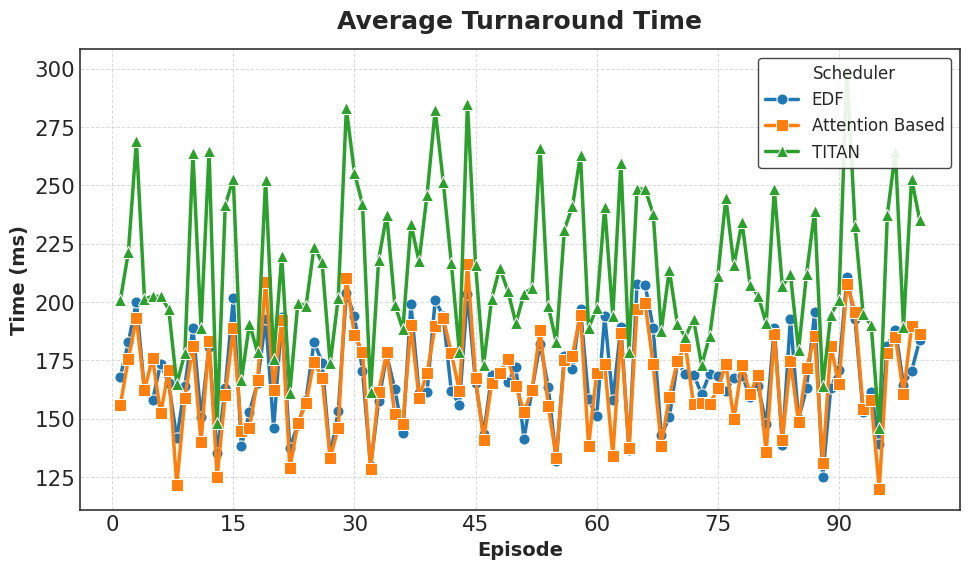

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

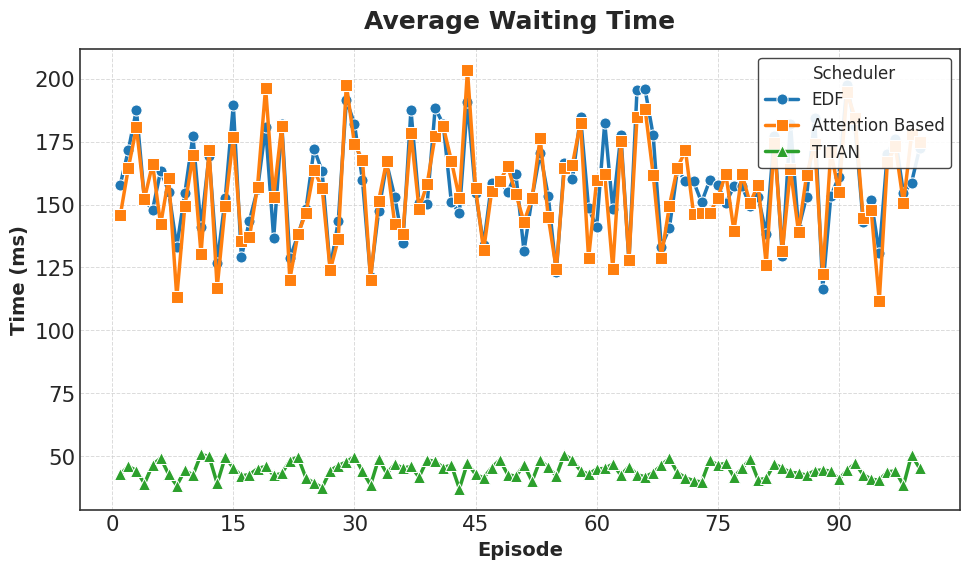

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

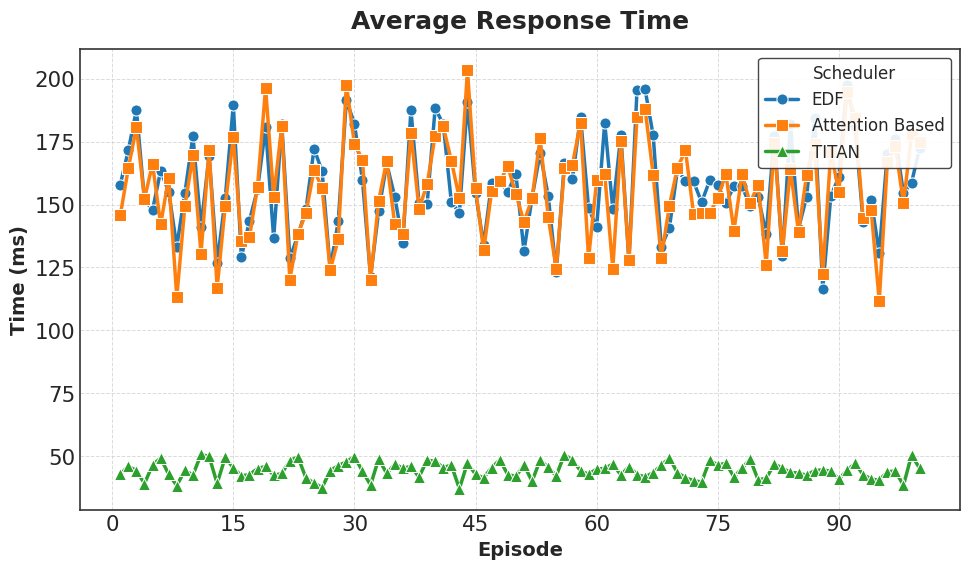

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

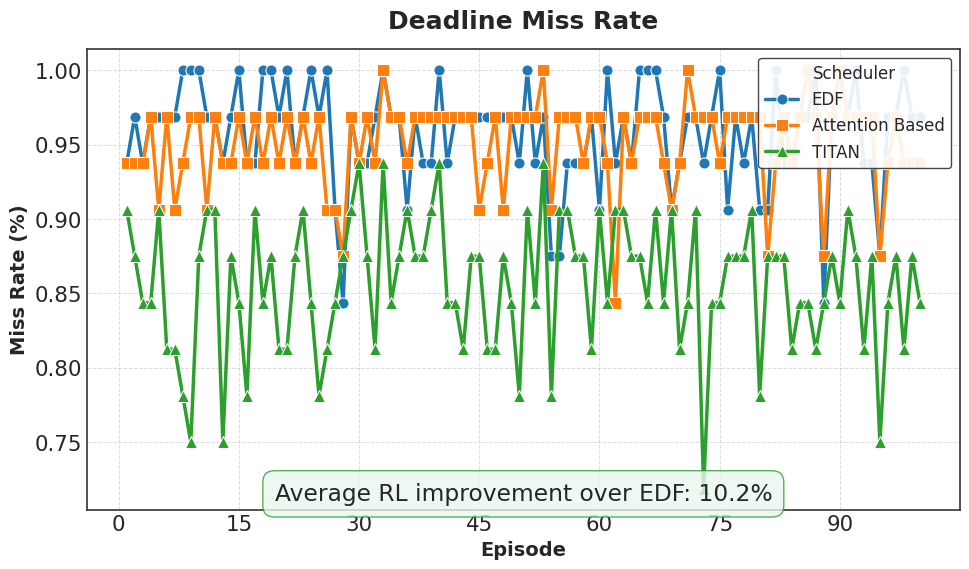

Generating dashboard view...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

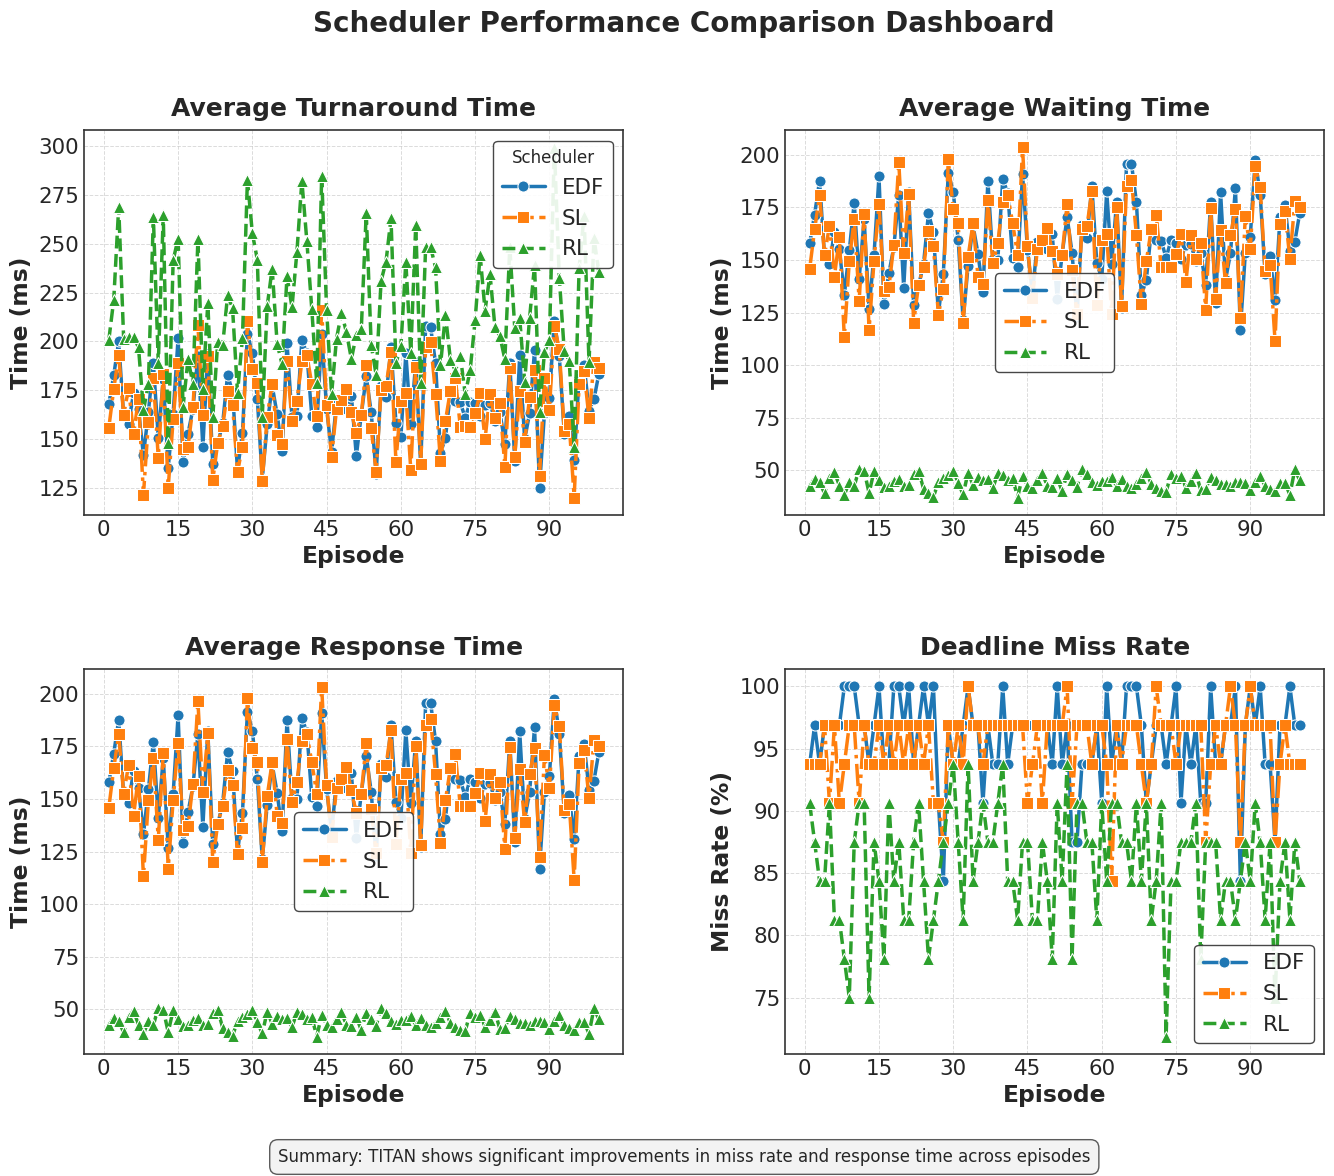

Generating performance heatmap...


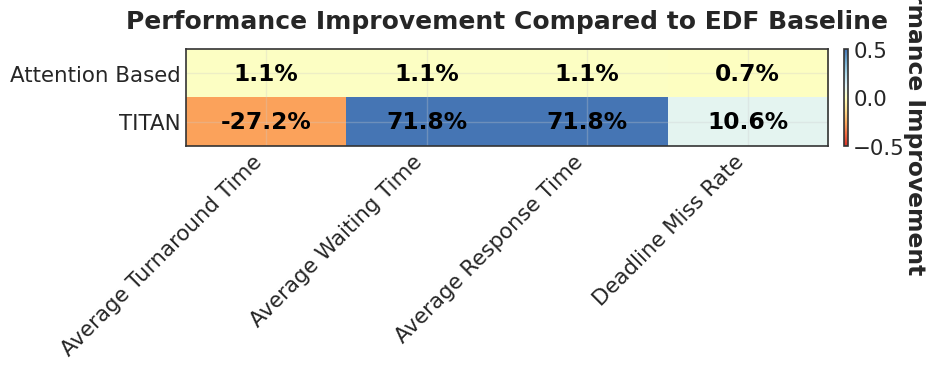

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Preprocess and extract episode data
def extract_data(logtext):
    edf_metrics, sl_metrics, rl_metrics = [], [], []
    episodes = []
    current_episode = 1
    lines = logtext.strip().splitlines()
    for line in lines:
        line = line.strip()
        if line.startswith("Episode"):
            current_episode = int(re.search(r"Episode (\d+):", line).group(1))
        elif line.startswith("EDF"):
            data = eval(line.split(":", 1)[1].strip())
            edf_metrics.append(data)
            episodes.append(current_episode)
        elif line.startswith("SL"):
            data = eval(line.split(":", 1)[1].strip())
            sl_metrics.append(data)
        elif line.startswith("RL"):
            data = eval(line.split(":", 1)[1].strip())
            rl_metrics.append(data)
    return episodes, edf_metrics, sl_metrics, rl_metrics

# Extract data
episodes, edf_metrics, sl_metrics, rl_metrics = extract_data(logtext1)

# Custom color palette
colors = {
    'EDF': '#1f77b4',  # Blue
    'SL': '#ff7f0e',   # Orange
    'RL': '#2ca02c'    # Green
}

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.edgecolor'] = '#333333'
plt.rcParams['xtick.major.width'] = 1.1
plt.rcParams['ytick.major.width'] = 1.1

# Metric names and units for plotting
metric_config = {
    'avg_turnaround': {
        'title': "Average Turnaround Time",
        'ylabel': "Time (ms)",
        'format': '%.1f'
    },
    'avg_waiting': {
        'title': "Average Waiting Time",
        'ylabel': "Time (ms)",
        'format': '%.1f'
    },
    'avg_response': {
        'title': "Average Response Time",
        'ylabel': "Time (ms)",
        'format': '%.1f'
    },
    'miss_rate': {
        'title': "Deadline Miss Rate",
        'ylabel': "Miss Rate (%)",
        'format': '%.1f%%'
    },
}

# Helper function to extract metric values
def extract_metric(metrics, key):
    return [m[key] for m in metrics]

# Helper function to calculate improvement percentage
def calculate_improvement(baseline_metrics, comparison_metrics, key):
    baseline_values = extract_metric(baseline_metrics, key)
    comparison_values = extract_metric(comparison_metrics, key)
    
    # Calculate percentage improvements for each episode
    improvements = []
    for b, c in zip(baseline_values, comparison_values):
        if b == 0:  # Avoid division by zero
            improvements.append(0)
        else:
            # For miss_rate, lower is better, for time metrics, higher is better
            if key == 'miss_rate':
                improvements.append(100 * (b - c) / b if b > 0 else 0)
            else:
                improvements.append(100 * (c - b) / b if b > 0 else 0)
    
    return improvements

# Individual metric plots
def plot_metrics_individually():
    for key, config in metric_config.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot with enhanced styling
        sns.lineplot(x=episodes, y=extract_metric(edf_metrics, key), 
                     label='EDF', marker='o', linewidth=2.5, markersize=8,
                     color=colors['EDF'], ax=ax)
        sns.lineplot(x=episodes, y=extract_metric(sl_metrics, key), 
                     label='Attention Based', marker='s', linewidth=2.5, markersize=8,
                     color=colors['SL'], ax=ax)
        sns.lineplot(x=episodes, y=extract_metric(rl_metrics, key), 
                     label='TITAN', marker='^', linewidth=2.5, markersize=8,
                     color=colors['RL'], ax=ax)
        
        # # Add data points with values
        # for scheduler, metrics, marker in [('EDF', edf_metrics, 'o'), 
        #                                    ('SL', sl_metrics, 's'), 
        #                                    ('RL', rl_metrics, '^')]:
        #     values = extract_metric(metrics, key)
        #     for i, (x, y) in enumerate(zip(episodes, values)):
        #         format_str = config['format']
        #         if key == 'miss_rate':
        #             # Convert to percentage for display
        #             display_val = y * 100
        #         else:
        #             display_val = y
                    
        #         ax.annotate(format_str % display_val, 
        #                     (x, y),
        #                     xytext=(0, 8),
        #                     textcoords='offset points',
        #                     ha='center',
        #                     fontsize=9,
        #                     bbox=dict(boxstyle='round,pad=0.3', 
        #                               fc='white', 
        #                               alpha=0.7,
        #                               ec=colors[scheduler],
        #                               linewidth=1))
        
        # Enhanced title and labels
        ax.set_title(config['title'], fontweight='bold', pad=15)
        ax.set_xlabel("Episode", fontweight='bold', fontsize=14)
        ax.set_ylabel(config['ylabel'], fontweight='bold', fontsize=14)
        
        # Better tick formatting
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
        
        # Enhance legend
        legend = ax.legend(title="Scheduler", title_fontsize=12, 
                  loc='upper right', frameon=True, 
                  edgecolor='#333333', fontsize=12)
        
        # Add performance difference annotation
        if key == 'miss_rate':
            edf_values = extract_metric(edf_metrics, key)
            rl_values = extract_metric(rl_metrics, key)
            avg_improvement = np.mean([(edf - rl) * 100 for edf, rl in zip(edf_values, rl_values)])
            
            improvement_text = f"Average RL improvement over EDF: {avg_improvement:.1f}%"
            ax.text(0.5, 0.02, improvement_text, 
                    transform=ax.transAxes, ha='center', 
                    bbox=dict(boxstyle='round,pad=0.5', 
                             fc='#e9f7ef', ec='#2ca02c', alpha=0.8))

        
        plt.tight_layout()
        plt.show()

# Dashboard-style summary plot of all metrics
def plot_dashboard():
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.4)
    
    metrics = list(metric_config.keys())
    
    for i, key in enumerate(metrics):
        config = metric_config[key]
        ax = fig.add_subplot(gs[i // 2, i % 2])
        
        # Plot with enhanced styling
        for scheduler, metrics_data, marker, linestyle in [
            ('EDF', edf_metrics, 'o', '-'), 
            ('SL', sl_metrics, 's', '-.'), 
            ('RL', rl_metrics, '^', '--')
        ]:
            values = extract_metric(metrics_data, key)
            if key == 'miss_rate':
                # Convert to percentage for display
                values = [v * 100 for v in values]
                
            sns.lineplot(x=episodes, y=values, 
                        label=scheduler, marker=marker, 
                        linewidth=2.5, markersize=8,
                        color=colors[scheduler], 
                        linestyle=linestyle,
                        ax=ax)
        
        # Enhanced title and labels
        ax.set_title(config['title'], fontweight='bold', pad=10)
        ax.set_xlabel("Episode", fontweight='bold')
        ax.set_ylabel(config['ylabel'], fontweight='bold')
        
        # Better tick formatting
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
        
        # Enhance legend
        if i == 0:
            legend = ax.legend(title="Scheduler", title_fontsize=12, 
                      loc='best', frameon=True, 
                      edgecolor='#333333')
    
    # Main title
    plt.suptitle("Scheduler Performance Comparison Dashboard", 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # Add summary statistics footer
    summary_text = "Summary: TITAN shows significant improvements in miss rate and response time across episodes"
    fig.text(0.5, 0.02, summary_text, ha='center', fontsize=12, 
             bbox=dict(boxstyle='round,pad=0.5', fc='#f0f0f0', 
                      ec='#333333', alpha=0.8))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Heatmap comparing scheduler performance
def plot_performance_heatmap():
    # Calculate relative performance (using EDF as baseline)
    metrics = list(metric_config.keys())
    
    # Create data for heatmap
    rel_perf_sl = []
    rel_perf_rl = []
    
    for key in metrics:
        edf_values = np.mean(extract_metric(edf_metrics, key))
        sl_values = np.mean(extract_metric(sl_metrics, key))
        rl_values = np.mean(extract_metric(rl_metrics, key))
        
        # For miss_rate, lower is better
        if key == 'miss_rate':
            rel_sl = (edf_values - sl_values) / edf_values if edf_values > 0 else 0
            rel_rl = (edf_values - rl_values) / edf_values if edf_values > 0 else 0
        else:
            # For time metrics, lower is better too
            rel_sl = (edf_values - sl_values) / edf_values if edf_values > 0 else 0
            rel_rl = (edf_values - rl_values) / edf_values if edf_values > 0 else 0
            
        rel_perf_sl.append(rel_sl)
        rel_perf_rl.append(rel_rl)
    
    # Create dataframe for heatmap
    data = [rel_perf_sl, rel_perf_rl]
    
    # Custom colormap for improvement visualization
    colors_improvement = ['#d73027', '#f46d43', '#fdae61', '#fee090', '#ffffbf', 
                          '#e0f3f8', '#abd9e9', '#74add1', '#4575b4']
    cmap_improvement = LinearSegmentedColormap.from_list('improvement', colors_improvement)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot heatmap
    im = ax.imshow(data, cmap=cmap_improvement, aspect='auto', vmin=-0.5, vmax=0.5)
    
    # Set axis labels
    ax.set_yticks(np.arange(len(['Attention Based', 'TITAN'])))
    ax.set_yticklabels(['Attention Based', 'TITAN'])
    
    ax.set_xticks(np.arange(len(metrics)))
    
    # Format metric names for display
    display_metrics = [metric_config[m]['title'] for m in metrics]
    ax.set_xticklabels(display_metrics, rotation=45, ha='right')
    
    # Add values to cells
    for i in range(len(['SL', 'RL'])):
        for j in range(len(metrics)):
            text = ax.text(j, i, f"{data[i][j]*100:.1f}%",
                          ha="center", va="center", color="black",
                          fontweight='bold')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('Performance Improvement', rotation=270, labelpad=15)
    
    # Add title
    ax.set_title('Performance Improvement Compared to EDF Baseline', fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.show()

# Function to run all plotting functions
def run_enhanced_plots():
    print("Generating individual metric plots...")
    plot_metrics_individually()
    
    print("Generating dashboard view...")
    plot_dashboard()
    
    print("Generating performance heatmap...")
    plot_performance_heatmap()

# Run all plots
run_enhanced_plots()